# Measuring Distances to Galaxies with the Tip of the Red Giant Branch

**2026 CosmoVerse Data Challenge Notebook — TRGB Distance Ladder**

---

| Role | Name |
|------|------|
| **Data Challenge Organizers** | Siyang Li · Jackson Said · Eleonora Di Valentino |
| **TRGB Team Coordinator** | Siyang Li |
| **Algorithm Contributors** | Chandra Shekhar Saraf · Swayamtrupta Panda · Mahdi Najafi · Rahul Shah · Luis Escamilla · Payam Ghafari · Masoume Reyhani |


## How to Use This Notebook

This notebook walks you through measuring a distance to a galaxy using the Tip of the Red Giant Branch (TRGB) method. Here is the full logic in order:

1. **Understand the physics** (Overview section below) — read once; this is why the method works.
2. **Select a target galaxy** (Sections 1–2) — choose which SN Ia host galaxy to measure.
3. **Define TRGB measurement algorithms** (Section 3) — run as-is; these cells define the TRGB measurement pipeline. No edits needed.
4. **Set measurement parameters** (Section 4) — define the selection region and smoothing, informed by the CMDs you will inspect in Section 5.
5. **Inspect the CMDs** (Section 5) — plot the data, verify your parameter choices visually, then go back to Section 4 and refine.
6. **Detect the TRGB in the anchor galaxy NGC 4258** (Section 6) — measures the apparent TRGB magnitude and calibrates the absolute brightness.
7. **Detect the TRGB in your target galaxy** (Section 7) — same pipeline, possibly different parameter choices.
8. **Compute the distance** (Section 8) — combines anchor and target results with the known maser distance.
9. **Export results** (Section 9) — Your results can then be input into the SN Ia to H0 notebook provided alongside this one.
10. **Optional batch run** (Section 10) — Runs through all the default galaxy selections with the same measurement parameters applied.
11. **Assess systematics** (Section 11) — check robustness; report additional uncertainty sources.

**Some examples of active decisions you must make** (everything else runs automatically):
- Which target galaxy to measure (Section 2)
- Where to place the RGB selection band in the CMD (Section 4 / Section 5)
- What smoothing bandwidth `tau` to use (Section 4)
- How much spatial clipping of stars to apply (Section 4)

> 📂 **Data files:** Place the CSV photometry catalogs (one per galaxy, with the galaxy name in the filename) in the directory set by `DATA_DIR` in Section 2 before running. Key columns: `Inst_vega_mag1` (F606W), `Inst_vega_mag2` (F814W), `RA`, `DEC`.

## Overview

This notebook measures **distances to galaxies** using a standardizable candle called the **Tip of the Red Giant Branch (TRGB)**. These distances are used to calibrate Type Ia supernovae, which extend the distance scale to cosmological distances and enable a measurement of the Hubble constant $H_0$. The TRGB method has a long history and is now one of the leading independent routes to $H_0$ (e.g. Yuan et al. 2019, Freedman et al. 2019, 2021; Blakeslee et al. 2021, Anand et al. 2022; Scolnic et al. 2023, Dhawan et al. 2022, 2023, Freedman et al. 2025, Hoyt et al. 2025, Jensen et al. 2025, Newman et al. 2024, Li et al. 2026, and references therein).

**The core idea:**

1. Red giant stars exhibit a **well-defined upper limit in luminosity** — the TRGB — set by the onset of helium ignition in their degenerate cores. In real data, this appears as a buildup of stars just below the tip (in the fainter direction) and a rapid drop above it (in the brighter direction) in the luminosity function. The TRGB luminosity is similar across galaxies but depends on stellar population properties (primarily metallicity) and the photometric band, making it a **standardizable candle**.

2. We **calibrate** the absolute magnitude of the TRGB using a galaxy with a precise geometric distance (e.g., NGC 4258, measured via water megamasers), thereby fixing $M_{\mathrm{TRGB}}$ in the chosen band.

3. We then **apply** this calibration to other galaxies: measuring the apparent magnitude $m_{\mathrm{TRGB}}$ and comparing it to the calibrated absolute magnitude yields the distance via the **distance modulus**:
$$
\mu = m_{\mathrm{TRGB}} - M_{\mathrm{TRGB}}.
$$

The rest of this section unpacks each piece of this logic, including how the TRGB is detected in practice and how statistical and systematic uncertainties enter the measurement. For comprehensive reviews of the TRGB as a distance indicator and its role in the distance ladder, see Beaton et al. 2018, Li et al. (2023a) and the CosmoVerse white paper on cosmological tensions (Di Valentino et al. 2025).

### What is the TRGB?

When a low-mass star ($\lesssim 2\,M_\odot$) exhausts hydrogen in its core, it develops an inert helium core surrounded by a hydrogen-burning shell. The core is **electron-degenerate**, meaning its pressure is set primarily by density and only weakly depends on temperature. As the shell deposits helium ash onto the core, the core mass grows and the star becomes more luminous. It ascends the **Red Giant Branch (RGB)**, a well-defined sequence on the color–magnitude diagram (CMD; magnitude vs. color) running from faint/bluer to bright/redder stars.

This ascent terminates abruptly. When the degenerate core reaches a critical mass (about $0.50\,M_\odot$), helium ignites in a thermonuclear runaway known as the **helium flash**. Because this ignition occurs at nearly a fixed core mass, the luminosity of the star just before the flash is also tightly constrained. As a result, low-mass stars reach a similar luminosity at the tip of the RGB.

In the $I$-band (≈8000 Å), this corresponds to an empirically calibrated absolute magnitude of approximately $M_I \approx -4$ mag (with calibration- and color-dependent variations). This was first established as a distance indicator primarily by Lee, Freedman & Madore (1993) and remains one of the most precise Population II standard candles.

> 📌 **Notation:** $M_I$ is the **absolute magnitude** in the $I$-band — the brightness a star would have at a standard distance of 10 pc.

This is what makes the TRGB a **standardizable candle**: its luminosity is not perfectly universal but can be calibrated and, if needed, corrected for stellar population effects (primarily metallicity). In practice, TRGB measurements are made in **old, relatively metal-poor stellar populations** (e.g., galaxy halos), where the behavior is well-characterized over a limited metallicity range.

The residual metallicity dependence in F814W is modest — scatter $\lesssim 0.05$ mag over the relevant population range — which is one of the main reasons this band is preferred (Rizzi et al. 2007; Jang & Lee 2017). In this notebook, we do not apply an explicit color-dependent correction; given the band choice and population selection, any resulting bias beyond the metallicity-insensitive range (see Jang & Lee 2017), if you choose to extend to that regime, is expected to be small (a few hundredths of a magnitude) relative to other uncertainties and after color corrections. See Section 9b for the correction formula.


### How does the TRGB appear in data?

We observe a galaxy with a telescope (e.g., HST), resolve it into individual stars, and measure each star's brightness (apparent magnitude) through two filters. The result is a **photometry catalog**: a table where each row corresponds to one detected star, with columns for its measured brightness in each filter.

Plotting apparent magnitude versus **color** (the difference in magnitude between two filters) produces a **color–magnitude diagram (CMD)**—the observational analogue of the Hertzsprung–Russell diagram. Color correlates with stellar temperature, with additional dependence on metallicity and extinction. In the CMD, the Red Giant Branch (RGB) appears as a sequence of stars becoming progressively brighter and redder toward its tip.

At the TRGB, this sequence terminates. Stars accumulate just below the tip because stellar evolution slows along the upper RGB as the core mass approaches the helium ignition threshold, while very few stars are observed above it because, after the helium flash, they evolve rapidly away from the RGB. This produces a distinct edge-like feature in the stellar distribution.

A histogram of magnitudes for stars selected along the RGB—the **luminosity function**—reveals this feature as a buildup of stars toward fainter magnitudes followed by a sharp drop near the TRGB. The exact shape depends on the RGB selection and, for binned methods, the choice of binning. In practice, photometric uncertainties and finite sampling smooth this feature, so it is not perfectly sharp.

> 🎯 **Our task:** Estimate the location of this edge in the luminosity function.

### How do we detect the edge?

The TRGB appears as an edge-like feature in the luminosity function of RGB stars. In an idealized case, a sharp step would produce a spike in its derivative. In real data, however, this feature is broadened by photometric uncertainties, finite sampling, and population effects, so the derivative produces a **finite-width peak** rather than an ideal spike.

The basic (edge-detection) algorithm is:

1. Build the luminosity function (e.g., a histogram of $I$-band apparent magnitudes for stars selected along the RGB). The result depends on the quality of the RGB selection and, for binned methods, the choice of binning.

2. **Smooth** the luminosity function to suppress shot noise. A noisy distribution produces many spurious peaks in its derivative. The smoothing bandwidth $\tau$ controls a bias–variance tradeoff: larger $\tau$ reduces noise fluctuations but can broaden and shift the true edge, while smaller $\tau$ preserves sharp features but increases sensitivity to noise. This is typically one of the most influential parameters in the measurement.

3. Apply a **Sobel filter**, a discrete approximation to the first derivative with mild smoothing. The TRGB is identified with a prominent peak in the filter response. In practice, multiple peaks can arise, so the result must be interpreted in the context of the CMD and the expected location of the RGB tip.

---

This edge-detection approach was introduced by Lee, Freedman & Madore (1993) and remains widely used, along with many variants that differ in smoothing, binning, and statistical treatment.

#### Model-based (statistical) methods

An alternative approach is to model the luminosity function and infer the TRGB location as a parameter of that model. In these methods, the luminosity function is typically represented as a truncated or broken distribution (e.g., a power law for RGB stars with a cutoff at the tip), convolved with photometric uncertainties and completeness functions.

The TRGB magnitude is then estimated using statistical methods such as:

- **Maximum likelihood**, which fits the unbinned stellar magnitudes directly and incorporates measurement uncertainties and incompleteness in a forward model.
- **Least-squares fitting**, typically applied to binned luminosity functions.

These approaches avoid explicit differentiation and can make more efficient use of the data (e.g., by avoiding binning). They also provide a flexible framework for incorporating additional effects such as contamination or population gradients, though at the cost of introducing model assumptions. Variants of this framework have been developed in the literature (e.g., Méndez et al. 2002; Makarov et al. 2006; Wu et al. 2014; Anand et al. 2021; Li et al. 2022, 2023a), differing primarily in the adopted functional form and treatment of observational effects. The choice of detection method is itself a source of systematic uncertainty that has been discussed extensively in the context of the Hubble tension (e.g. Wu et al. 2014, Soltis et al. 2021; Anand et al. 2022; Li et al. 2023a; Scolnic et al. 2023).

### The calibration chain: from anchor to distance

To convert a TRGB detection into a distance, we need to know the TRGB's **intrinsic (absolute) brightness**. We obtain this from a **calibrator galaxy** whose distance is known from geometric measurements.

**NGC 4258** hosts water vapor (H$_2$O) masers in a thin, nearly Keplerian disk orbiting its central supermassive black hole. By measuring the orbital velocities (via Doppler shifts of the 22 GHz maser emission) and the angular structure of the disk (via VLBI imaging), one can determine its distance from geometric modeling of the system, largely independent of stellar astrophysics. This yields a distance modulus
$$
\mu_{\text{anchor}} = 29.397 \pm 0.032 \ \text{mag}
$$
(Reid et al. 2019), where the **distance modulus** is
$$
\mu = m - M = 5\log_{10}(d / 10\;\text{pc}).
$$

Here, $m$ is the observed (apparent) magnitude and $M$ is the intrinsic (absolute) magnitude. Given $\mu$ and a measured $m$, we can infer $M = m - \mu$.

Applying this to the TRGB, we obtain the absolute magnitude:

$$
\boxed{M_{\text{TRGB}} = m_{\text{TRGB, anchor}} - \mu_{\text{anchor}}}
$$

This calibrated $M_{\text{TRGB}}$ can then be applied to a target galaxy:

$$
\boxed{\mu_{\text{target}} = m_{\text{TRGB, target}} - M_{\text{TRGB}}}
$$

Combining these two expressions eliminates the need to determine $M_{\text{TRGB}}$ independently, giving the **working formula** used in Section 8:

$$
\mu_{\text{target}} = m_{\text{TRGB, target}} - m_{\text{TRGB, anchor}} + \mu_{\text{anchor}}.
$$

This calibration requires that TRGB magnitudes be measured consistently (e.g., in the same photometric band and with similar population selection), and that magnitudes are corrected for extinction before applying the relation. The uncertainties in each term propagate into the final distance estimate (see Section 8).

Conceptually, we work with **two galaxies**: the anchor (e.g., NGC 4258), which sets the absolute scale, and the target galaxy, whose distance we wish to measure. In practice, additional anchors or cross-checks may also be used to validate the calibration.

### Connection to $H_0$

The Hubble constant relates recession velocity to distance. In the nearby universe (where the expansion is approximately linear), this is written as
$$
H_0 \approx \frac{v}{d}.
$$
Velocities are inferred from redshifts (via spectral line shifts), while distances require standard candles such as the TRGB.

The full **distance ladder** has three rungs:

| Rung | Method | What it calibrates |
|------|--------|-------------------|
| 1 | Geometric (water masers in NGC 4258; Reid et al. 2019) | Absolute TRGB brightness $M_{\text{TRGB}}$ |
| 2 | TRGB distances to SN Ia host galaxies (**this notebook**) | Absolute SN Ia brightness |
| 3 | SN Ia in the Hubble flow (**accompanied notebook**) | $H_0$ |

In practice, peculiar velocities do not vanish but become subdominant at sufficiently large distances, allowing the expansion rate to be measured reliably from SN Ia in the Hubble flow. Uncertainties propagate up the ladder, so the calibration of each rung directly impacts the final value of $H_0$.

#### Recent TRGB-based $H_0$ measurements

Different teams have applied this methodology with different calibration and analysis choices, obtaining a range of results. See the CosmoVerse white paper (Di Valentino et al. 2025) and distance network consensus report (Casertano et al. 2026) for compilations.

The spread across analyses reflects genuine methodological differences — particularly in the TRGB detection algorithm, sample selection, photometric pipeline (DOLPHOT vs. DAOPHOT/ALLFRAME), and calibration anchor — as well as SN Ia selection effects (see Li et al. 2026), rather than statistical uncertainty alone. This notebook implements the Sobel edge-detection approach (Lee, Freedman & Madore 1993; Hatt et al. 2017, Wu et al. 2023, Li et al. 2023, Scolnic et al. 2023) with NGC 4258 as anchor.

### Pipeline summary

For each galaxy, the steps are:

1. **Load photometry** — each row corresponds to a star; columns give its brightness in two HST filters (assumed to be photometrically calibrated).

2. **Build a CMD** — plot apparent magnitude vs. color to visualize the stellar populations.

3. **Correct for extinction** — subtract foreground dust extinction (see below).

4. **Select RGB stars** — isolate halo stars and define a band in the CMD that selects the red giant branch while minimizing contamination from other populations and restricting the TRGB to the metal-poor and blue regime.
 
5. **Build and smooth the luminosity function** — construct the luminosity function (e.g., a histogram of the selected stars' $I$-band magnitudes) and smooth it with bandwidth $\tau$ to suppress shot noise prior to edge detection.

6. **Apply Sobel edge detection** — apply a Sobel filter (a discrete derivative operator) to identify a prominent peak corresponding to the apparent TRGB magnitude $m_{\text{TRGB}}$. If multiple peaks are present, the result must be validated against the CMD and expected RGB location.

7. **Bootstrap for statistical uncertainty** — resample the CMD with replacement, re-run steps 3–5 for each realization, and take the standard deviation of the resulting $m_{\text{TRGB}}$ distribution. This captures statistical uncertainty from finite sampling but does not include systematic effects.

8. **Compute distance** — apply the calibration chain described above. The same analysis pipeline should be applied consistently to both the anchor and target galaxies.

---

### What can you adjust?

Most tunable parameters live in **Section 4**. The key choices are:

| Parameter group | What it controls | Most important knob |
|-----------------|-----------------|---------------------|
| `SELECTION` | Which stars are classified as RGB (vertical color window) | `color_lo`, `color_hi` |
| `SMOOTHING` | How much the luminosity function is smoothed before edge detection | `tau` — the smoothing bandwidth, in magnitudes |
| `EDGE` | Details of the derivative operator (Sobel kernel weighting) | kernel choice |
| `BOOTSTRAP` | Resampling settings for uncertainty estimation | `n_boot` |
| `SPATIAL` | Elliptical halo selection (spatial clipping aggressiveness) | `scale_factor` |

Not all parameters have equal impact. In practice, **RGB selection** and **smoothing** dominate the measurement: the selection region determines which stars enter the analysis, and the smoothing bandwidth `tau` controls a bias–variance tradeoff in locating the edge. Larger `tau` suppresses noise but can bias the TRGB estimate by broadening the edge, while smaller `tau` preserves sharp features but increases sensitivity to fluctuations. These choices are also coupled—changing the selection can shift the optimal `tau`.

You should inspect the CMD (Section 5) before adjusting `SELECTION`, and vary $\tau$ to assess how stable the detected TRGB is. A robust measurement should not change dramatically over a reasonable range of $\tau$ and plausible selection choices.

The `EDGE` settings typically have a smaller effect, while `BOOTSTRAP` parameters affect the estimated statistical uncertainty but not the central value of $m_{\text{TRGB}}$.

Consistency is important: the same parameter choices and methodology should be applied to both the anchor and target galaxies to ensure a consistent calibration.

> ⚠️ **Analysis bias warning:** Tuning parameters on the same data used for detection can introduce bias (e.g., selecting parameters that maximize a particular peak). Stability across reasonable choices is therefore an important diagnostic of robustness.


### Error budget

The final distance modulus to the target is:

$$
\mu_{\text{target}} = m_{\text{TRGB, target}} - m_{\text{TRGB, anchor}} + \mu_{\text{anchor}}.
$$

Each quantity has an associated uncertainty. As a first approximation, treating these terms as independent, we obtain the total propagated uncertainty:

$$
\sigma_\mu = \sqrt{
\sigma_{\text{boot,anchor}}^2 +
\sigma_{\text{ext,anchor}}^2 +
\sigma_{\text{maser}}^2 +
\sigma_{\text{boot,target}}^2 +
\sigma_{\text{ext,target}}^2
}.
$$

| Term | Source | Typical size | How estimated |
|------|--------|-------------|---------------|
| $\sigma_{\text{boot,anchor}}$ | Statistical scatter in TRGB detection for NGC 4258 | 0.02–0.10 mag (data-dependent) | Bootstrap resampling of the NGC 4258 CMD |
| $\sigma_{\text{ext,anchor}}$ | Uncertainty in foreground extinction toward NGC 4258 | ≈0.01 mag | Estimated as 20% of $A_{\text{F814W}}$ plus a 0.005 mag floor |
| $\sigma_{\text{maser}}$ | Uncertainty in the geometric distance to NGC 4258 | 0.032 mag | Reid et al. (2019); fixed external input setting the zero-point |
| $\sigma_{\text{boot,target}}$ | Statistical scatter in TRGB detection for the target | 0.02–0.15 mag (data-dependent) | Bootstrap resampling of the target CMD |
| $\sigma_{\text{ext,target}}$ | Uncertainty in foreground extinction toward the target | 0.01–0.03 mag (data-dependent) | Same 20% + floor estimate |

The bootstrap resamples at the CMD level (not just the selected magnitudes), so variability in the RGB selection step is partially propagated into the uncertainty. However, this reflects statistical variation under the adopted selection procedure, not the full systematic uncertainty associated with that choice.

Some sources of uncertainty are partially correlated between the anchor and target (e.g., photometric zero-points or assumptions in extinction modeling), and the expression above does not account for these covariances. Conversely, the differential form of the measurement means that some shared systematics may partially cancel.

> ⚠️ **Important:** The bootstrap captures *statistical* uncertainty only. The expression above does not include several sources of systematic error, including photometric zero-point calibration, crowding and blending biases, internal extinction within the target galaxy, and population-dependent effects (e.g., residual metallicity dependence if no color correction is applied). These effects are discussed in Section 9.

## Glossary of Observational Terms

> 📖 Refer back to this section as needed. Terms are grouped by topic. Definitions here are intentionally concise; the Overview and algorithm sections provide fuller context.


### Brightness and distance

**Magnitude system.** Astronomical brightness is measured on a logarithmic, inverted scale:
$$
m = -2.5 \log_{10}(F/F_0),
$$
where $F$ is the observed flux (in a given bandpass) and $F_0$ is a reference flux that sets the zero point. Brighter objects have smaller (more negative) magnitudes. A difference of 5 mag corresponds to a factor of 100 in flux. **Apparent magnitude** ($m$) is what you observe; **absolute magnitude** ($M$) is the magnitude an object would have at a standard distance of 10 pc.

**Vega magnitude system.** The reference flux $F_0$ is often defined relative to the star Vega, which sets the zero point of the magnitude scale in many optical bands. This is a conventional choice (distinct from the AB system used in other contexts). As long as a consistent magnitude system is used throughout, derived quantities such as colors and distance moduli are unaffected.

**Distance modulus.**
$$
\mu = m - M = 5\log_{10}(d/10\;\text{pc}),
$$
which relates observed brightness, intrinsic brightness, and distance.

---

**Standard candle.** An object whose absolute magnitude can be calibrated and remains roughly constant (with corrections and standardizations) galaxy to galaxy. Comparing intrinsic and apparent brightness then yields the distance. In this notebook, the TRGB provides this calibrated absolute magnitude.

### Color and temperature

**Photometric filters.** Brightness is measured through bandpass filters. This notebook uses two HST ACS/WFC filters: **F606W** (a broad visual band, roughly centered near 6000 Å) and **F814W** (a red/near-infrared band, roughly centered near 8000 Å and similar, but not identical, to the standard $I$-band). Some datasets use **F555W** instead of F606W; in such cases, the exact definition of color changes and must be interpreted consistently with the filter set used.

**Color.** Defined as
$$
m_{\text{F606W}} - m_{\text{F814W}}.
$$
Because magnitudes are logarithmic, a magnitude difference corresponds to a ratio of fluxes in the two bands. Color correlates with stellar surface temperature, but also depends on stellar composition (metallicity) and dust extinction. Hotter stars appear bluer (smaller color index), while cooler stars appear redder (larger color index). RGB stars typically occupy colors of order 1–3 mag in these filters, depending on population and extinction.

> 💡 **Why F814W for the TRGB?** The TRGB magnitude is measured in a specific bandpass, and its dependence on stellar population properties varies with wavelength. In redder bands such as $I$ (e.g., F814W), the sensitivity to metallicity is reduced, making the TRGB a more stable standardizable candle. In addition, redder bands are less affected by dust extinction, which helps reduce systematic uncertainties in the distance measurement.

### Diagrams and functions

**CMD (Color–Magnitude Diagram).** A scatter plot of apparent magnitude (y-axis, **inverted** so brighter is *up*) versus color (x-axis). This is the observational analogue of the Hertzsprung–Russell diagram. Different stellar populations occupy distinct regions: the Red Giant Branch (RGB) appears as a diagonal sequence of stars becoming brighter and redder toward its tip.

> 📌 **Why is the magnitude axis inverted?** The magnitude scale is defined so that brighter objects have *smaller* (more negative) values. In a CMD, the y-axis is plotted with magnitude increasing downward (fainter stars at the bottom), so the diagram visually resembles a luminosity axis: more luminous stars appear at the top, as in a Hertzsprung–Russell diagram. Every CMD in this notebook follows this convention. When we refer to the TRGB as being at the “bright end of the RGB,” we mean the *top* of the RGB sequence in the CMD.

**Luminosity function (LF).** A histogram of stellar apparent magnitudes, typically constructed for stars selected along the RGB. The resulting LF depends on the quality of this selection. For RGB stars, the LF shows a buildup toward fainter magnitudes and a drop near the TRGB. In real data, photometric uncertainties and finite sampling broaden this feature, so the edge is not perfectly sharp. This is the feature we aim to detect.

### Dust and extinction

**Extinction.** Interstellar dust between us and the target absorbs and scatters starlight, making stars appear fainter (larger magnitude) and redder. The total dimming in a given filter is $A_\lambda$ (always positive, in magnitudes). We correct observed magnitudes as
$$
m_{\text{corrected}} = m_{\text{observed}} - A_\lambda.
$$
This treatment assumes extinction can be approximated as a uniform foreground screen, shifting all magnitudes by the same amount. This is typically a good approximation for Milky Way foreground extinction on the angular scales (distant galaxies) considered here.

**$E(B-V)$ (color excess).** A commonly used summary of the dust column along the line of sight is
$$
E(B-V) = A_B - A_V,
$$
the differential extinction between the $B$ and $V$ bands. Given $E(B-V)$, the extinction in any filter can be written as
$$
A_\lambda = R_\lambda \, E(B-V),
$$
where $R_\lambda$ depends on the assumed extinction law and the filter transmission curve. In this notebook, we adopt fixed coefficients for the HST filters:
$$
R_{\text{F555W}} = 3.100, \quad R_{\text{F606W}} = 2.471, \quad R_{\text{F814W}} = 1.526.
$$

Extinction also shifts stellar colors, moving stars diagonally in the CMD (toward fainter magnitudes and redder colors).

**Foreground vs. internal extinction.** The $E(B-V)$ values used here account for **Milky Way foreground** extinction only. Dust within the target galaxy ("internal extinction") is not explicitly corrected. This is mitigated in part by focusing on halo-like stellar populations, but residual internal extinction remains a potential systematic — see **Section 9b** for a detailed treatment.

### Observational context

**Resolved stellar population.** A galaxy close enough that HST can distinguish individual stars (typically within $\sim$20–30 Mpc, depending on data quality and crowding). Each row in the photometry file corresponds to one detected star.

**Halo field.** We observe the outer regions (halo) of each galaxy rather than the crowded central regions. Lower stellar density reduces **crowding** (overlapping stellar images that can bias measured magnitudes and increase scatter) and leads to a cleaner TRGB detection.

**Photometric depth.** How faint the telescope can reliably detect stars. Near the detection limit, photometric uncertainties increase and completeness decreases, which broadens the CMD and smooths features in the luminosity function. This directly affects the detectability and precision of the TRGB. The `mag_faint` parameter controls how far below the TRGB the data are included in the analysis.

**Anchor galaxy.** NGC 4258: its distance is determined from water masers in a thin, rotating disk around its central supermassive black hole. By combining orbital velocities (from Doppler shifts of the 22 GHz maser emission) with the angular structure of the disk (from VLBI imaging), the distance is inferred from geometric modeling of the system. This method is largely independent of stellar astrophysics and is conceptually similar to geometric distance measurements such as parallax. NGC 4258 therefore serves as a robust anchor, setting the TRGB zero-point for all target galaxies in this notebook.

**Host galaxy (SN Ia host).** A galaxy that hosted a Type Ia supernova. Measuring its distance (via the TRGB) allows the intrinsic brightness of the SN Ia to be determined.

**Photometry catalog.** The data files used in this notebook. Each row corresponds to one detected point source (usually a star). The key columns are `Inst_vega_mag1` (F555W or F606W magnitude) and `Inst_vega_mag2` (F814W magnitude), both in the Vega system. (Some file versions use lower-case `inst_vega_mag1`; the notebook resolves column names case-insensitively via `get_mag_cols()`.)

**Quality columns** (CATS files):

- `sharp_mag2`: PSF shape parameter; values far from 0 indicate non-stellar sources
- `crowd_mag2`: crowding parameter; large values flag sources affected by nearby stars
- `flag_mag2`: pipeline quality flag (0 = clean detection)

The `Inst` prefix indicates magnitudes derived from the instrument calibration pipeline and ready for analysis. Applying quality cuts on these parameters helps control contamination and photometric biases, which directly impact the robustness of the TRGB measurement. The public photometry used in this data challenge already has quality cuts applied. However, these cuts may differ slightly from source to source (e.g. EDD and CATs), so it is important to remain consistent and use photometry from the same source for a given $H_0$ measurement.

---

## 0. Setup

## Environment and Requirements

This notebook requires **Python 3.9 or later**. Install dependencies with:

```
pip install numpy pandas matplotlib scipy astropy joblib
```

Recommended pinned versions (tested):

| Package | Minimum version |
|---------|----------------|
| `numpy` | 1.24 |
| `pandas` | 1.5 |
| `matplotlib` | 3.7 |
| `scipy` | 1.10 |
| `astropy` | 5.3 |
| `joblib` | 1.3 |


In [37]:
# ============================================================
# SETUP — all imports required for this notebook
# ============================================================

import glob
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
from matplotlib.ticker import AutoMinorLocator

from scipy import linalg

from astropy.io import fits as afits

from joblib import Parallel, delayed

# Suppress minor warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.linewidth':    1.2,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.top':         True,
    'ytick.right':       True,
    'font.family':       'sans-serif',
})

print('All libraries imported successfully.')


# ── Filter identification ────────────────────────────────────────────────────
# The flat-TRGB color limit depends on which blue filter is used:
#   F606W − F814W  →  limit at  1.5 mag  (Jang & Lee 2017, Table 6)
#   F555W − F814W  →  limit at  2.1 mag  (Jang & Lee 2017, Table 6)
# We detect the filter from the column name so the correct limit is applied.
FILTER_COLOR_LIMITS = {
    'f606w': 1.5,   # (F606W − F814W)_0 flat-TRGB limit
    'f555w': 2.1,   # (F555W − F814W)_0 flat-TRGB limit
}

def _detect_blue_filter(col_name):
    """Infer the blue filter from the magnitude column name.

    Returns the lower-case filter identifier ('f606w' or 'f555w'),
    or None if it cannot be determined.
    """
    col_lower = col_name.lower()
    for filt in ('f606w', 'f555w', 'f475w', 'f814w', 'f450w'):
        if filt in col_lower:
            return filt
    return None


def get_mag_cols(df):
    """Robustly identify the blue (mag1) and F814W (mag2) columns.

    Handles common photometry outputs where multiple *_mag1 / *_mag2
    columns exist (e.g., snr_mag1, sharp_mag1). Selects the physically
    meaningful magnitude columns by prioritizing names containing 'vega'
    while excluding known non-magnitude fields (snr, sharp, crowd, flag, err).

    Also detects the blue filter (F606W or F555W) from the column name
    and sets COLOR_HI_MAX to the appropriate flat-TRGB limit
    (Jang & Lee 2017):
        F606W − F814W  →  COLOR_HI_MAX = 1.5 mag
        F555W − F814W  →  COLOR_HI_MAX = 2.1 mag

    Returns
    -------
    col1 : str   — column name for the blue filter magnitude
    col2 : str   — column name for the F814W magnitude
    """
    global COLOR_HI_MAX

    # Helper to filter valid magnitude columns
    def is_good_mag(col):
        bad_keys = ['snr', 'sharp', 'crowd', 'flag', 'err']
        return not any(k in col for k in bad_keys)

    # Identify candidates
    mag1_candidates = [c for c in df.columns
                       if c.lower().endswith('mag1') and is_good_mag(c.lower())]
    mag2_candidates = [c for c in df.columns
                       if c.lower().endswith('mag2') and is_good_mag(c.lower())]

    # Prefer Vega mags if available
    def prefer_vega(candidates):
        vega = [c for c in candidates if 'vega' in c.lower()]
        return vega[0] if len(vega) == 1 else (candidates[0] if len(candidates) == 1 else None)

    col1 = prefer_vega(mag1_candidates)
    col2 = prefer_vega(mag2_candidates)

    # Final fallback
    if col1 is None or col2 is None:
        raise KeyError(
            f'Could not uniquely identify magnitude columns.\n'
            f'Filtered mag1 candidates: {mag1_candidates}\n'
            f'Filtered mag2 candidates: {mag2_candidates}\n'
            'Check column names — expected a single photometric magnitude column.'
        )

    # --- Detect blue filter and set appropriate color limit ---
    blue_filter = _detect_blue_filter(col1)
    if blue_filter in FILTER_COLOR_LIMITS:
        COLOR_HI_MAX = FILTER_COLOR_LIMITS[blue_filter]
        filter_label = blue_filter.upper()
        print(f'  Filter detected: {filter_label} − F814W  '              f'→  flat-TRGB color limit = {COLOR_HI_MAX} mag '              f'(Jang & Lee 2017)')
    else:
        # Unrecognised filter — keep existing COLOR_HI_MAX but warn
        filter_label = col1
        print(f'  WARNING: Blue filter not recognised from column name '              f'"{col1}". COLOR_HI_MAX stays at {COLOR_HI_MAX} mag. '              f'Verify this limit is appropriate for your filter combination.')

    return col1, col2

All libraries imported successfully.


## 1. Galaxy Database & Target Selection

### What this section does

We load a database of galaxies: one geometric anchor (NGC 4258) and a set of SN Ia host galaxies compiled in the CosmoVerse GitHub repository (see repository documentation for data sources and references). We utilize public photometry. For each galaxy we store:

- **$E(B-V)$**: Milky Way foreground dust reddening from the Schlafly & Finkbeiner (2011) maps (accessed via NED as a lookup service). This is used to compute the extinction corrections $A_{\text{F606W}}$ and $A_{\text{F814W}}$.

- **Galaxy shape parameters** ($R_{25}$, $b/a$, PA): these describe the galaxy’s projected shape on the sky (semi-major axis of the 25 mag arcsec$^{-2}$ isophote, axis ratio, and position angle). They are used later for **spatial selection** — to exclude stars projected onto the galaxy’s bright disk and restrict the analysis to halo regions where crowding is lower. If spatial cuts are not applied, these parameters are not used, though doing so may increase contamination and systematic uncertainty.

You then select which target galaxy to measure.

### Choosing a target

The table below shows all available galaxies. When choosing a target, consider:

- **Foreground extinction:** Galaxies with high $E(B-V)$ (e.g., NGC 2442, NGC 5643, NGC 7250) require larger extinction corrections, which increases systematic uncertainty.

- **Data quality:** The precision of the TRGB measurement depends strongly on photometric depth, crowding, and the clarity of the RGB in the CMD.

- **Supernova hosts:** All target galaxies host Type Ia supernovae (listed in the final column), which are used in the next rung of the distance ladder.

NGC 4258 is always used as the anchor; it is the only galaxy in this dataset with a geometric distance and sets the zero-point of the TRGB calibration.

In [38]:
# ============================================================
# GALAXY DATABASE
#
# Extinction: E(B-V) from Schlafly & Finkbeiner (2011) via NED
# Shape:      Isophotal parameters from RC3 / HyperLEDA
#
# Extinction coefficients for HST ACS/WFC filters:
#   A_lambda = R_lambda * E(B-V)
# (values consistent with a standard R_V ~ 3.1 extinction law)
# ============================================================

R_F606W = 2.471   # HST F606W
R_F555W = 3.100   # HST F555W  (Schlafly & Finkbeiner 2011)
R_F814W = 1.526   # HST F814W


# --- Galaxy database (dict-of-dicts) ---
GALAXY_DB = {
    'NGC4258': {'E_BV': 0.014, 'SN': 'Maser anchor', 'role': 'anchor',
                'ra': 184.7397, 'dec': 47.3039, 'R25': 558.0, 'ba': 0.387, 'PA': 150.0},

    'NGC1309': {'E_BV': 0.035, 'SN': 'SN 2002fk', 'role': 'host',
                'ra': 50.5275, 'dec': -15.4000, 'R25': 66.0, 'ba': 0.955, 'PA': 218.0},

    'NGC1365': {'E_BV': 0.018, 'SN': 'SN 2012fr', 'role': 'host',
                'ra': 53.4015, 'dec': -36.1403, 'R25': 336.0, 'ba': 0.554, 'PA': 32.0},

    'NGC1448': {'E_BV': 0.013, 'SN': 'SN 2001el, SN 2021pit', 'role': 'host',
                'ra': 56.1330, 'dec': -44.6447, 'R25': 228.0, 'ba': 0.224, 'PA': 42.0},



    'NGC3021': {'E_BV': 0.014, 'SN': 'SN 1995al', 'role': 'host',
                'ra': 147.7375, 'dec': 33.5536, 'R25': 39.0, 'ba': 0.538, 'PA': 135.0},

    'NGC3370': {'E_BV': 0.031, 'SN': 'SN 1994ae', 'role': 'host',
                'ra': 161.7667, 'dec': 17.2736, 'R25': 93.0, 'ba': 0.548, 'PA': 148.0},


    'NGC4038': {'E_BV': 0.042, 'SN': 'SN 2007sr', 'role': 'host',
                'ra': 180.4708, 'dec': -18.8694, 'R25': 156.0, 'ba': 0.596, 'PA': 80.0},

    'NGC4424': {'E_BV': 0.020, 'SN': 'SN 2012cg', 'role': 'host',
                'ra': 186.7983, 'dec': 9.4206, 'R25': 108.0, 'ba': 0.500, 'PA': 95.0},

    'NGC4536': {'E_BV': 0.018, 'SN': 'SN 1981B', 'role': 'host',
                'ra': 188.6129, 'dec': 2.1881, 'R25': 228.0, 'ba': 0.421, 'PA': 130.0},


    'NGC5584': {'E_BV': 0.035, 'SN': 'SN 2007af', 'role': 'host',
                'ra': 215.5992, 'dec': -0.3878, 'R25': 102.0, 'ba': 0.735, 'PA': 140.0},

    'NGC5643': {'E_BV': 0.166, 'SN': 'SN 2013aa, SN 2017cbv', 'role': 'host',
                'ra': 218.1696, 'dec': -44.1744, 'R25': 138.0, 'ba': 0.761, 'PA': 165.0},


    'M101':    {'E_BV': 0.007, 'SN': 'SN 2011fe',                          'role': 'host',
                'ra': 210.8023, 'dec':  54.3490, 'R25': 840.0, 'ba': 1.000, 'PA':   0.0},

    'M66':     {'E_BV': 0.029, 'SN': 'SN 1989B',                           'role': 'host',
                'ra': 170.0625, 'dec':  12.9916, 'R25': 270.0, 'ba': 0.470, 'PA': 173.0},

    'M96':     {'E_BV': 0.022, 'SN': 'SN 1998bu',                          'role': 'host',
                'ra': 161.6903, 'dec':  11.8200, 'R25': 225.0, 'ba': 0.670, 'PA':   5.0},

    'NGC1316': {'E_BV': 0.018, 'SN': 'SN 1980N, SN 1981D, SN 2006dd, SN 2006mr', 'role': 'host',
                'ra':  50.6737, 'dec': -37.2079, 'R25': 362.0, 'ba': 0.708, 'PA':  50.0},

    'NGC1404': {'E_BV': 0.010, 'SN': 'SN 2007on, SN 2011iv',               'role': 'host',
                'ra':  54.7164, 'dec': -35.5941, 'R25':  96.0, 'ba': 0.940, 'PA': 163.0},


    'NGC4526': {'E_BV': 0.019, 'SN': 'SN 1994D',                           'role': 'host',
                'ra': 188.5126, 'dec':   7.6991, 'R25': 210.0, 'ba': 0.390, 'PA': 113.0},

    'NGC7814': {'E_BV': 0.039, 'SN': 'SN 2021rhu',                         'role': 'host',
                'ra':   0.8121, 'dec':  16.1453, 'R25': 195.0, 'ba': 0.410, 'PA': 135.0}
}


def normalize_name(name):
    """Normalize galaxy name for matching."""
    return name.replace(' ', '').replace('-', '').upper()


def get_galaxy_info(galaxy_name):
    """Return galaxy information with extinction precomputed."""
    key = normalize_name(galaxy_name)

    if key not in GALAXY_DB:
        raise KeyError(f'{galaxy_name} not found. Available: {list(GALAXY_DB.keys())}')

    g = GALAXY_DB[key]

    # Validation
    if g['E_BV'] < 0:
        raise ValueError(f'Invalid E(B-V) for {key}')
    if not (0 < g['ba'] <= 1):
        raise ValueError(f'Invalid axis ratio for {key}')

    return {
        'name': key,
        'E(B-V)': g['E_BV'],
        'SN': g['SN'],
        'role': g['role'],
        'A_F606W': round(R_F606W * g['E_BV'], 4),
        'A_F555W': round(R_F555W * g['E_BV'], 4),
        'A_F814W': round(R_F814W * g['E_BV'], 4),
        'ra_deg': g['ra'],
        'dec_deg': g['dec'],
        'R25_arcsec': g['R25'],
        'ba': g['ba'],
        'PA_deg': g['PA'],
    }


def find_photometry_file(galaxy_name, data_dir='.'):
    """Search for CSV photometry files matching the galaxy name."""
    key = normalize_name(galaxy_name)

    patterns = [f'{key}*.csv', f'{key.lower()}*.csv']
    matches = []

    for pat in patterns:
        matches.extend(glob.glob(os.path.join(data_dir, pat)))

    matches = sorted(set(matches))

    if len(matches) > 1:
        print(f'Warning: multiple photometry files found for {key}:')
        for m in matches:
            print(f'  {m}')

    return matches


def find_fits_file(galaxy_name, fits_dir='.'):
    """Search for FITS reference images matching the galaxy name."""
    key = normalize_name(galaxy_name)

    patterns = [f'{key}*.fits', f'{key}*.fits.gz', f'{key}*.fit']
    matches = []

    for pat in patterns:
        matches.extend(glob.glob(os.path.join(fits_dir, pat)))

    matches = sorted(set(matches))

    if len(matches) > 1:
        print(f'Warning: multiple FITS files found for {key}:')
        for m in matches:
            print(f'  {m}')

    return matches




# EDD files that use F555W as the blue filter (all others use F606W).
# Source: CosmoVerse EDD metadata table.
EDD_F555W_FILES = {
    'M66_10433', 'M101_9492', 'NGC1309_10497',
    'NGC3021_10497', 'NGC3370_9351', 'NGC4258_9477', 'NGC5584_11570',
}

# NGC 4258 CATS field names that use F555W as the blue filter (fields 1-4).
# Fields 5-7 use F606W. Source: Hoyt et al. (2023), Table 1.
CATS_NGC4258_F555W_FIELDS = {
    'NGC4258-1', 'NGC4258-2', 'NGC4258-3', 'NGC4258-4_G1', 'NGC4258-4_G2',
}

def _edd_blue_filter(filepath):
    """Return the blue filter identifier for an EDD photometry file."""
    stem = os.path.splitext(os.path.basename(filepath))[0].upper()
    for key in EDD_F555W_FILES:
        if key.upper() in stem:
            return 'f555w'
    return 'f606w'


def _embed_filter_in_col(df, blue_filt):
    """Rename the generic mag1 column to include the filter name.

    This lets get_mag_cols() detect the filter via _detect_blue_filter()
    even when the original column name carries no filter information
    (e.g. EDD 'inst_vega_mag1').
    """
    bad = {'snr', 'sharp', 'crowd', 'flag', 'err'}
    for col in list(df.columns):
        cl = col.lower()
        if cl.endswith('mag1') and not any(k in cl for k in bad):
            if blue_filt not in cl:   # don't rename if filter already present
                df = df.rename(columns={col: f'{blue_filt}_{col}'})
            break
    return df

def load_photometry_df(galaxy_name, data_dir, phot_source, override_file=None, cats_filter=None, edd_filter=None):
    """Load photometry for a galaxy.

    For CATS, matching field files are concatenated. When cats_filter is
    'F555W' or 'F606W', only that filter group's fields are loaded (used by
    the anchor loop in Section 6 to handle NGC 4258's mixed-filter fields).
    For EDD, when multiple files share the same filter they are concatenated.
    When edd_filter is 'F555W' or 'F606W', only that filter group's files are
    loaded (used by the anchor/target loops for mixed-filter EDD galaxies).
    Single-file EDD galaxies and the override_file path are unchanged.
    """
    if override_file:
        path = os.path.join(data_dir, override_file)
        if not os.path.exists(path):
            avail = find_photometry_file(galaxy_name, data_dir)
            raise FileNotFoundError(
                f'Override file not found: {path}\n'
                f'Available: {[os.path.basename(f) for f in avail]}')
        print(f'  Loading (override): {override_file}')
        df = pd.read_csv(path)
        print(f'  {len(df):,} sources loaded.')
        blue_filt = _edd_blue_filter(path) if phot_source == 'EDD' else 'f606w'
        print(f'  Blue filter: {blue_filt.upper()} − F814W  '
              f'(color limit: {FILTER_COLOR_LIMITS.get(blue_filt, 1.5):.1f} mag)')
        return _embed_filter_in_col(df, blue_filt)

    files = find_photometry_file(galaxy_name, data_dir)
    if not files:
        raise FileNotFoundError(
            f'No photometry file found for {galaxy_name} in '
            f'{os.path.abspath(data_dir)}')

    if phot_source == 'CATS' and len(files) > 1:
        if cats_filter is not None:
            f555w = [f for f in files
                     if any(k in os.path.basename(f) for k in CATS_NGC4258_F555W_FIELDS)]
            f606w = [f for f in files if f not in f555w]
            chosen = {'F555W': f555w, 'F606W': f606w}.get(cats_filter, files)
            if not chosen:
                chosen = files
            blue_filt = cats_filter.lower()
            print(f'  CATS [{cats_filter}]: {len(chosen)} field(s):')
        else:
            chosen = files
            blue_filt = 'f606w'
            print(f'  CATS: concatenating {len(chosen)} fields:')
        for f in chosen:
            print(f'    {os.path.basename(f)}')
        df = pd.concat([pd.read_csv(f) for f in chosen], ignore_index=True)
        print(f'  Blue filter: {blue_filt.upper()} − F814W  '
              f'(color limit: {FILTER_COLOR_LIMITS.get(blue_filt, 1.5):.1f} mag)')
        df = _embed_filter_in_col(df, blue_filt)
    elif phot_source == 'EDD' and len(files) > 1:
        f555w_files = [f for f in files if _edd_blue_filter(f) == 'f555w']
        f606w_files = [f for f in files if _edd_blue_filter(f) == 'f606w']
        mixed = bool(f555w_files) and bool(f606w_files)
        if edd_filter is not None:
            chosen = f555w_files if edd_filter == 'F555W' else f606w_files
            if not chosen:
                chosen = files
            blue_filt = edd_filter.lower()
            print(f'  EDD [{edd_filter}]: {len(chosen)} file(s):')
        elif mixed:
            # mixed F555W+F606W files — caller splits via edd_filter; default to F606W
            chosen = f606w_files
            blue_filt = 'f606w'
            print('  EDD: mixed F555W/F606W files — defaulting to F606W group.')
            print('       (Anchor/target loops pass edd_filter to select each group.)')
        else:
            chosen = files
            blue_filt = _edd_blue_filter(files[0])
            print(f'  EDD: concatenating {len(chosen)} files ({blue_filt.upper()}):')
        for f in chosen:
            print(f'    {os.path.basename(f)}')
        df = pd.concat([pd.read_csv(f) for f in chosen], ignore_index=True)
        print(f'  Blue filter: {blue_filt.upper()} − F814W  '
              f'(color limit: {FILTER_COLOR_LIMITS.get(blue_filt, 1.5):.1f} mag)')
        df = _embed_filter_in_col(df, blue_filt)
    else:
        print(f'  Loading: {os.path.basename(files[0])}')
        df = pd.read_csv(files[0])
        blue_filt = _edd_blue_filter(files[0]) if phot_source == 'EDD' else 'f606w'
        print(f'  Blue filter: {blue_filt.upper()} − F814W  '
              f'(color limit: {FILTER_COLOR_LIMITS.get(blue_filt, 1.5):.1f} mag)')
        df = _embed_filter_in_col(df, blue_filt)

    print(f'  {len(df):,} sources loaded.')
    return df

# --- Print the galaxy database ---
print(f'{"Galaxy":12s} {"E(B-V)":>7s} {"A_F814W":>8s} {"R25(arcsec)":>8s} '
      f'{"b/a":>5s} {"PA°":>5s}  {"SN(e)"}')
print('-' * 78)

for name, g in GALAXY_DB.items():
    tag = ' *' if g['role'] == 'anchor' else ''
    print(f'{name:12s} {g["E_BV"]:7.3f} {R_F814W*g["E_BV"]:8.3f} {g["R25"]:8.1f} '
          f'{g["ba"]:5.2f} {g["PA"]:5.0f}  {g["SN"]}{tag}')

Galaxy        E(B-V)  A_F814W R25(arcsec)   b/a   PA°  SN(e)
------------------------------------------------------------------------------
NGC4258        0.014    0.021    558.0  0.39   150  Maser anchor *
NGC1309        0.035    0.053     66.0  0.95   218  SN 2002fk
NGC1365        0.018    0.027    336.0  0.55    32  SN 2012fr
NGC1448        0.013    0.020    228.0  0.22    42  SN 2001el, SN 2021pit
NGC3021        0.014    0.021     39.0  0.54   135  SN 1995al
NGC3370        0.031    0.047     93.0  0.55   148  SN 1994ae
NGC4038        0.042    0.064    156.0  0.60    80  SN 2007sr
NGC4424        0.020    0.031    108.0  0.50    95  SN 2012cg
NGC4536        0.018    0.027    228.0  0.42   130  SN 1981B
NGC5584        0.035    0.053    102.0  0.73   140  SN 2007af
NGC5643        0.166    0.253    138.0  0.76   165  SN 2013aa, SN 2017cbv
M101           0.007    0.011    840.0  1.00     0  SN 2011fe
M66            0.029    0.044    270.0  0.47   173  SN 1989B
M96            0.022    0.0

## 2. Select Your Target Galaxy

In this section, you choose the **target galaxy** whose distance you will measure.

The analysis always uses **two galaxies**:
- **Anchor:** NGC 4258 (fixed; provides the absolute calibration)
- **Target:** the galaxy you select below

> 🚫 NGC 4258 should **not** be selected as the target — it is always included automatically as the anchor.

---

### Choosing a target

Edit `TARGET_GALAXY` below to select a Type Ia supernova host galaxy.

**Guidance:**
- For a first pass, choose a **low-extinction galaxy** (e.g., NGC 1448 or NGC 3972, both with $E(B-V) \approx 0.013$).
  - These require smaller extinction corrections and typically yield more stable TRGB measurements.
- Higher-extinction galaxies (e.g., NGC 5643 with $E(B-V) = 0.166$) are scientifically useful but introduce larger systematic uncertainties through the extinction correction.

---

### Photometry source

Set `PHOT_SOURCE` to one of two options:

| Value | Pipeline | Files |
|-------|----------|-------|
| `'EDD'` | DOLPHOT (Extragalactic Distance Database) | `photometry/EDD/` |
| `'CATS'` | DOLPHOT (Comparative Analysis of TRGBs) | `photometry/CATS/cut_files/` |

`DATA_DIR` is set automatically from your choice — do not edit it manually.

**CATS multi-field galaxies:** Some galaxies (e.g., NGC 4258) have multiple CATS field files. These are automatically concatenated into a single catalog for analysis.

**EDD multi-program galaxies:** Some galaxies have files from multiple HST programs (e.g., `M66_10433.csv`, `M66_13691.csv`). The first alphabetically is used by default; set `TARGET_PHOT_FILE` to choose a specific one.

---

### ⚠️ Photometry consistency for H0

For a valid $H_0$ measurement, use the **same photometry source for all galaxies** — both the anchor (NGC 4258) and every target you measure. Mixing EDD and CATS photometry introduces pipeline-dependent systematics (different PSF models, quality cuts, and calibration choices) that are not captured in the error budget and will bias your final $H_0$.

> **Use all EDD or all CATS — never a mix.**

---

### Multiple photometry files (EDD override)

If you want to use a specific EDD file rather than the default, set the override in the next cell:

```python
TARGET_PHOT_FILE = 'M66_15654.csv'   # filename only, not the full path
ANCHOR_PHOT_FILE = 'NGC4258_9477.csv'
```

Leave as `None` to use the default. CATS overrides are not supported — all field files are always concatenated.

---

### If you don't have the data

Download the photometry catalogs from the provided repository and place them in the `photometry/` directory alongside this notebook.

The next cell will check whether the required files are present and report any missing datasets.


In [39]:
# ============================================================
# CHOOSE YOUR TARGET — edit this cell
# ============================================================
TARGET_GALAXY = 'NGC1316'   # Change to any host galaxy in GALAXY_DB, e.g. 'NGC1448' (in that format!)
PHOT_SOURCE   = 'EDD'   # Photometry source: 'EDD' or 'CATS'

ANCHOR_PHOT_FILE = None # EDD only: filename to override auto-selection
TARGET_PHOT_FILE = None  # EDD only: filename to override auto-selection
                         # (CATS always concatenates all matching field files)

# --- Set data directory from photometry source ---
if PHOT_SOURCE == 'EDD':
    DATA_DIR = '../photometry/EDD'
elif PHOT_SOURCE == 'CATS':
    DATA_DIR = '../photometry/CATS/'
else:
    raise ValueError(f"PHOT_SOURCE must be 'EDD' or 'CATS', got '{PHOT_SOURCE}'")

# --- Photometry consistency warning ---
print('=' * 65)
print(f'  Photometry source: {PHOT_SOURCE}')
print()
print('  ⚠  For a valid H0 measurement, use the same photometry')
print('     source (EDD or CATS) for ALL galaxies — anchor and')
print('     target. Mixing sources introduces pipeline-dependent')
print('     systematics not captured in the error budget.')
print('=' * 65)
print()

# --- Validate selection ---
if TARGET_GALAXY.replace(' ', '').upper() == 'NGC4258':
    raise ValueError(
        'NGC4258 is the anchor and cannot be selected as TARGET_GALAXY.\n'
        'Please choose a host galaxy instead.'
    )

# --- Auto-lookup extinction and metadata ---
try:
    anchor_info = get_galaxy_info('NGC4258')
    target_info = get_galaxy_info(TARGET_GALAXY)
except KeyError as e:
    raise KeyError(
        f'{e}\nCheck spelling. Available galaxies: {list(GALAXY_DB.keys())}'
    )

# --- Summary ---
print('=== Selected galaxies ===\n')

print(f'Anchor:  {anchor_info["name"]}   '
      f'E(B-V) = {anchor_info["E(B-V)"]:.3f}   '
      f'A_F606W = {anchor_info["A_F606W"]:.3f}   '
      f'A_F814W = {anchor_info["A_F814W"]:.3f}')

print(f'Target:  {target_info["name"]}   '
      f'E(B-V) = {target_info["E(B-V)"]:.3f}   '
      f'A_F606W = {target_info["A_F606W"]:.3f}   '
      f'A_F814W = {target_info["A_F814W"]:.3f}   '
      f'(hosted {target_info["SN"]})')

# --- Check that photometry files exist ---
print(f'\nSearching for photometry CSVs in:\n  {os.path.abspath(DATA_DIR)}\n')

all_found = True

for label, info, override in [
    ('Anchor', anchor_info, ANCHOR_PHOT_FILE),
    ('Target', target_info, TARGET_PHOT_FILE),
]:
    files = find_photometry_file(info['name'], DATA_DIR)

    if files:
        print(f'  {label} ({info["name"]}): {len(files)} file(s) found')
        for f in files:
            filt_tag = f' ({_edd_blue_filter(f).upper()})' if PHOT_SOURCE == 'EDD' else ''
            print(f'    ✓ {os.path.basename(f)}{filt_tag}')

        if PHOT_SOURCE == 'CATS' and len(files) > 1:
            print(f'    → Will concatenate all {len(files)} fields.\n')
        elif len(files) > 1:
            if override:
                chosen = os.path.join(DATA_DIR, override)
                if not os.path.exists(chosen):
                    raise FileNotFoundError(
                        f'{label} override not found: {chosen}\n'
                        f'Available: {[os.path.basename(f) for f in files]}')
                print(f'    → Using (override): {override}\n')
            else:
                print(f'    → Using: {os.path.basename(files[0])} (default — set {label.upper()}_PHOT_FILE to change)\n')
        else:
            print()
    else:
        all_found = False
        print(f'  {label} ({info["name"]}): ❌ NOT FOUND')
        print(f'    → Expected a CSV containing "{info["name"]}" in the filename.')
        print(f'    → Place the file in: {os.path.abspath(DATA_DIR)}\n')

if not all_found:
    print('⚠ Missing required photometry files.')
    print('The notebook cannot proceed until both anchor and target data are available.')


  Photometry source: EDD

  ⚠  For a valid H0 measurement, use the same photometry
     source (EDD or CATS) for ALL galaxies — anchor and
     target. Mixing sources introduces pipeline-dependent
     systematics not captured in the error budget.

=== Selected galaxies ===

Anchor:  NGC4258   E(B-V) = 0.014   A_F606W = 0.035   A_F814W = 0.021
Target:  NGC1316   E(B-V) = 0.018   A_F606W = 0.044   A_F814W = 0.028   (hosted SN 1980N, SN 1981D, SN 2006dd, SN 2006mr)

Searching for photometry CSVs in:
  /Users/siyangli/Downloads/CosmoVerse-Data-Challenge-Materials-as-of-May-25-2026/photometry/EDD

  ../photometry/EDD/NGC4258_16198.csv
  ../photometry/EDD/NGC4258_9477.csv
  Anchor (NGC4258): 2 file(s) found
    ✓ NGC4258_16198.csv (F606W)
    ✓ NGC4258_9477.csv (F555W)
    → Using: NGC4258_16198.csv (default — set ANCHOR_PHOT_FILE to change)

  Target (NGC1316): 1 file(s) found
    ✓ NGC1316_13691.csv (F606W)



> ✅ **Next step:** Once both files are found, proceed to **Section 3** to run the algorithm functions (no edits needed), then **Section 4** to set measurement parameters, then **Section 5** to inspect the CMDs.


---

## 3. Algorithm Functions

This section defines all functions used by the measurement pipeline in Sections 6 and 7. **Run all cells in this section before proceeding to Section 5.** You do not need to edit anything here unless you are modifying the pipeline.

| Sub-section | Contents |
|-------------|----------|
| **3a** | Spatial clipping (elliptical halo selection) |
| **3b** | Color-band RGB selection |
| **3c** | GLOESS luminosity function smoothing |
| **3d** | Sobel edge detection |
| **3e** | Bootstrap uncertainty estimation |
| **3f** | Diagnostic plotting |


### 3a. Spatial clipping (halo selection)

**What:** Remove stars projected onto the galaxy’s bright disk and bulge, keeping only stars in the outer halo.

**Why:** The inner regions of galaxies have high stellar density, leading to **crowding** (overlapping stellar images that bias magnitudes brighter), mixed stellar populations, and increased internal dust. These effects degrade the TRGB measurement. The halo provides a cleaner environment: lower density, older stellar populations, and reduced internal extinction.

---

### How the selection works

We define an **elliptical boundary** that approximates the projected shape of the galaxy on the sky. Stars **inside** this ellipse (the galaxy body) are rejected; stars **outside** are kept as halo candidates.

The ellipse is defined using:
- $R_{25}$: semi-major axis of the galaxy’s 25 mag/arcsec$^2$ isophote (from B-band imaging)
- $b/a$: axis ratio (encodes inclination)
- PA: position angle on the sky

The use of an ellipse (rather than a circle) accounts for the galaxy’s **inclination**: a circular cut would incorrectly include disk stars along the minor axis or exclude halo stars along the major axis.

> 📌 **Note:** The $R_{25}$ isophote is a **practical proxy**, not a physically sharp boundary between disk and halo populations.

---

### Scale factor

The `scale_factor` parameter rescales the ellipse:

| `scale_factor` | Effect | Tradeoff |
|----------------|--------|----------|
| 0.5 | Smaller ellipse | More stars, but increased contamination from disk |
| 1.0 | D25 boundary | Standard compromise |
| 1.5 | Larger ellipse | Cleaner halo, but fewer stars (higher noise) |

Smaller values increase statistical power but risk bias from contamination; larger values reduce contamination but increase statistical uncertainty.

---

### Coordinate system

Clipping is performed in **sky coordinates (RA, Dec)**.

| Source | Sky coordinates | Spatial (ellipse) clipping |
|--------|----------------|------------------|
| EDD | ✓ included | Applied |
| CATS | ✗ not in cut files | Skipped — all stars retained |

> 📌 **CATS users:** the elliptical D25 clipping in this notebook is not applied, but this does **not** mean no spatial selection was performed. The CATS public photometry (cut files) already incorporates its own spatial selection — a more detailed, field-specific method applied during catalog production. The absence of an elliptical cut here simply reflects that its selection has already been done upstream.

---

### Implementation details

In sky coordinates, angular offsets from the galaxy center are computed as:

$$
\Delta\alpha_{\rm sky} = (\alpha_{\rm star} - \alpha_{\rm gal})\cos(\delta_{\rm gal}), 
\quad 
\Delta\delta = \delta_{\rm star} - \delta_{\rm gal}
$$

The $\cos(\delta)$ factor accounts for the convergence of meridians, ensuring RA differences correspond to true angular separations.

The ellipse equation is then evaluated in rotated coordinates aligned with the galaxy’s position angle.



---

### Selection boundary

Stars are classified as halo if they satisfy:

$$
\text{ellipse value} > 1
$$

This defines a **boundary** between disk and halo.

> ⚠️ This is an approximation: it does not account for uncertainties in galaxy shape parameters or stellar positions. Stars near the boundary may be misclassified.

---

### Output

The function returns a boolean mask (`True` = halo star) and a spatial diagnostic plot:
- **Boolean mask** — `True` for each halo star kept in the analysis
- **Diagnostic plot** — spatial map of kept (teal) vs. clipped (red) stars with the D25 ellipse overlaid

---

### How to interpret the diagnostic plot

A good spatial selection should:

- Clearly exclude the dense central region
- Retain a broad, diffuse halo population
- Avoid removing large contiguous regions of outer stars

If the halo appears sparse or the clipping removes most stars, consider adjusting `scale_factor`.

---

### Notes

If `PHOT_SOURCE = 'EDD'` but RA/DEC columns are absent from the catalog, an error is raised and execution stops.

If `PHOT_SOURCE = 'CATS'`, clipping is skipped and all stars are retained.

In [40]:
def ellipse_value_sky(ra_star, dec_star, ra_gal, dec_gal,
                      r25_deg, ba, pa_deg):
    """Evaluate the elliptical isophote in sky coordinates.

    Returns:
        < 1  → inside the ellipse (projected galaxy body)
        = 1  → on the boundary
        > 1  → outside the ellipse (halo region)

    Notes:
    - Uses a tangent-plane (small-angle) approximation:
        ΔRA_sky = (RA_star − RA_gal) * cos(Dec_gal)
    - Accurate over the ACS field of view.
    """
    cos_dec = np.cos(np.radians(dec_gal))
    d_ra_sky = (ra_star - ra_gal) * cos_dec
    d_dec    =  dec_star - dec_gal

    r_maj = r25_deg
    r_min = r25_deg * ba
    pa_rad = np.radians(pa_deg)

    x_aln = d_ra_sky * np.sin(pa_rad) + d_dec * np.cos(pa_rad)
    y_aln = d_ra_sky * np.cos(pa_rad) - d_dec * np.sin(pa_rad)

    return (x_aln / r_maj) ** 2 + (y_aln / r_min) ** 2


def load_fits_image(fits_file):
    """Load 2D science data from a FITS file."""
    with afits.open(fits_file) as hdul:
        for ext in ['SCI', 0, 1]:
            try:
                data   = hdul[ext].data
                header = hdul[ext].header
                if data is not None and data.ndim == 2:
                    return np.nan_to_num(data.astype(float)), header
            except (KeyError, IndexError):
                continue
    raise ValueError(f'Could not find 2D image data in {fits_file}')



def _fetch_sky_background(ra_gal, dec_gal, size_arcsec, pixels=512, timeout=8):
    """Fetch a sky cutout centred on the galaxy for the spatial diagnostic plot.

    Tries SDSS colour JPEG first (covers ~1/3 of sky); falls back to
    DSS2 Red via SkyView (all-sky).  Returns (image_array, half_arcsec)
    or (None, None) if both fail or the network is unavailable.
    """
    import urllib.request, tempfile, os

    half = size_arcsec / 2.0

    def _download(url, suffix):
        tmp = tempfile.mktemp(suffix=suffix)
        try:
            with urllib.request.urlopen(url, timeout=timeout) as r:
                with open(tmp, 'wb') as f:
                    f.write(r.read())
            return tmp
        except Exception:
            if os.path.exists(tmp):
                os.remove(tmp)
            return None

    import matplotlib.image as mpimg

    # --- SDSS colour JPEG ---
    sdss_url = (
        f"https://skyserver.sdss.org/dr17/SkyServerWS/ImgCutout/getjpeg"
        f"?ra={ra_gal}&dec={dec_gal}"
        f"&scale={size_arcsec/pixels:.4f}"
        f"&width={pixels}&height={pixels}&opt="
    )
    tmp = _download(sdss_url, '.jpg')
    if tmp:
        try:
            img = mpimg.imread(tmp)
            os.remove(tmp)
            # SDSS returns a flat grey tile outside its footprint — skip it
            if img.std() > 4:
                return np.fliplr(img), half   # flip so East ends up left after invert_xaxis
        except Exception:
            if os.path.exists(tmp):
                os.remove(tmp)

    # --- DSS2 Red via SkyView (all-sky fallback) ---
    skyview_url = (
        f"https://skyview.gsfc.nasa.gov/current/cgi/runquery.pl"
        f"?Survey=DSS2+Red"
        f"&position={ra_gal},{dec_gal}"
        f"&Size={size_arcsec/3600:.5f}"
        f"&Pixels={pixels}"
        f"&Return=FITS"
        f"&Coordinates=J2000"
    )
    tmp = _download(skyview_url, '.fits')
    if tmp:
        try:
            with afits.open(tmp) as hdul:
                data = hdul[0].data.astype(float)
            os.remove(tmp)
            lo = np.nanpercentile(data, 2)
            hi = np.nanpercentile(data, 98)
            img = np.clip((data - lo) / max(hi - lo, 1e-10), 0, 1)
            return np.fliplr(np.flipud(img)), half  # FITS row 0 = South; flipud to put North at top
        except Exception:
            if os.path.exists(tmp):
                os.remove(tmp)

    return None, None


def apply_spatial_clip(df, galaxy_info, phot_source,
                       scale_factor=1.0, fits_file=None, show_plot=True,
                       img_size_factor=3.5):
    """Select halo stars by removing those projected onto the galaxy body.

    Scientific purpose:
    -------------------
    This step reduces key systematics in TRGB measurements:
      - Crowding (blending biases magnitudes brighter)
      - Mixed stellar populations (disk + bulge + halo)
      - Internal dust extinction

    All galaxies — including NGC 4258 — are treated consistently.
    Spatial clipping is always applied using sky coordinates (RA/Dec).

    Method:
    -------
    - Define an ellipse based on the galaxy's D25 isophote
    - Remove stars inside the ellipse (projected galaxy body)
    - Keep stars outside (halo region)

    Requirements:
    -------------
    The photometry catalog must contain RA and DEC columns.
    If these are absent, an error is raised and execution stops.

    Returns:
        Boolean mask (True = halo star)
    """

    # --- Ellipse parameters ---
    r25_arcsec = galaxy_info['R25_arcsec'] * scale_factor
    r25_deg    = r25_arcsec / 3600.0
    ba         = galaxy_info['ba']
    pa_deg     = galaxy_info['PA_deg']
    ra_gal     = galaxy_info['ra_deg']
    dec_gal    = galaxy_info['dec_deg']

    col_upper = {c.upper(): c for c in df.columns}

    # CATS cut files do not contain sky coordinates — skip elliptical clipping.
    # The CATS public photometry already applies its own spatial selection upstream.
    if phot_source == 'CATS':
        print('  Spatial clipping: elliptical D25 cut skipped for CATS photometry.')
        print('  Note: CATS cut files already incorporate a field-specific spatial')
        print('  selection applied during catalog production — no elliptical cut')
        print('  here does not mean no selection was applied to the data.')
        return np.ones(len(df), dtype=bool)

    if 'RA' not in col_upper or 'DEC' not in col_upper:
        raise ValueError(
            f"Spatial clipping requires RA and DEC columns, but none were found "
            f"in the photometry catalog for {galaxy_info.get('name', 'unknown')}.\n"
            f"Available columns: {list(df.columns)}\n"
            f"Switch to EDD photometry to enable spatial clipping."
        )

    # --- Sky coordinate clipping ---
    ra_star  = df[col_upper['RA']].values.astype(float)
    dec_star = df[col_upper['DEC']].values.astype(float)

    e_val = ellipse_value_sky(
        ra_star, dec_star,
        ra_gal, dec_gal,
        r25_deg, ba, pa_deg
    )

    # --- Selection ---
    mask_halo = e_val > 1.0

    n_total = len(df)
    n_halo  = int(np.sum(mask_halo))
    n_clip  = n_total - n_halo

    print(f'  Spatial clip [sky (RA/DEC)]: scale={scale_factor:.1f}× D25, '
          f'R25={r25_arcsec:.0f}"')
    print(f'  Kept {n_halo} halo stars, clipped {n_clip} inner stars '
          f'({100*n_halo/n_total:.0f}% kept)')

    # ============================================================
    # DIAGNOSTIC PLOT
    # ============================================================
    if show_plot:
        print('  Diagnostic: ensure the disk/bulge are removed while the halo remains well sampled.')

        fig, ax = plt.subplots(figsize=(7, 7))

        # --- Background sky image ---
        img_size = img_size_factor * r25_arcsec
        sky_img, sky_half = _fetch_sky_background(ra_gal, dec_gal, img_size)
        if sky_img is not None:
            cmap = None if sky_img.ndim == 3 else 'gray_r'
            ax.imshow(sky_img,
                      extent=[-sky_half, sky_half, -sky_half, sky_half],
                      origin='upper', alpha=0.55, zorder=0,
                      cmap=cmap, aspect='auto')
        else:
            print('  (Sky background unavailable — no network or outside survey footprint.)')


        # Sky-offset arcsec (ΔRA·cos(Dec), ΔDec) keeps both axes physically equal,
        # preventing the cos(Dec) stretch of raw RA degrees from distorting the ellipse PA.
        cos_dec_plot = np.cos(np.radians(dec_gal))
        x_plot = (ra_star  - ra_gal)  * cos_dec_plot * 3600   # arcsec East
        y_plot = (dec_star - dec_gal) * 3600                   # arcsec North
        ell_width  = 2.0 * r25_arcsec        # full major axis in arcsec
        ell_height = 2.0 * r25_arcsec * ba   # full minor axis in arcsec
        ell_angle  = 90.0 - pa_deg            # CCW from East; astro PA measured from North toward East

        ax.scatter(x_plot[~mask_halo], y_plot[~mask_halo],
                   s=0.3, c='#e74c3c', alpha=0.3, rasterized=True,
                   label='Clipped (galaxy body)', zorder=1)
        ax.scatter(x_plot[mask_halo], y_plot[mask_halo],
                   s=0.3, c='#0d7377', alpha=0.3, rasterized=True,
                   label='Halo (kept)', zorder=2)

        # --- Draw the clipping ellipse boundary ---
        ellipse_patch = Ellipse(
            xy=(0.0, 0.0),
            width=ell_width,
            height=ell_height,
            angle=ell_angle,
            edgecolor='#e67e22', facecolor='none',
            lw=2.5, linestyle='--', zorder=5,
            label=f'D25 ellipse (×{scale_factor:.1f})'
        )
        ax.add_patch(ellipse_patch)

        ax.set_xlabel('ΔRA × cos(Dec)  (arcsec,  East →)', fontsize=14)
        ax.set_ylabel('ΔDec  (arcsec,  North ↑)', fontsize=14)
        ax.set_title(
            f'Spatial selection — {galaxy_info.get("name", "")}\n'
            f'scale = {scale_factor:.1f}× D25,  R25 = {r25_arcsec:.0f}″,  '
            f'b/a = {ba:.2f},  PA = {pa_deg:.0f}°',
            fontsize=13
        )
        ax.legend(fontsize=11, loc='upper left', framealpha=0.9, markerscale=12)
        ax.tick_params(labelsize=11)
        ax.invert_xaxis()   # East to the left (standard sky orientation)
        ax.set_aspect('equal')

        plt.tight_layout()
        plt.show()

    return mask_halo


print('Spatial clipping functions defined (NGC 4258 included).')

Spatial clipping functions defined (NGC 4258 included).


### 3b. Color-band selection

**What:** Select a subset of stars from the CMD that belong to the Red Giant Branch (RGB).

**Why:** The TRGB measurement relies on detecting a sharp discontinuity in the **luminosity function**. This discontinuity is produced *only* by RGB stars. The full CMD, however, includes multiple contaminants: main-sequence stars, asymptotic giant branch (AGB) stars above the tip, foreground Milky Way stars, and unresolved background galaxies. Including these populations can add noise, introduce **spurious edges**, or bias the detected tip.

This step defines the **input sample for the luminosity function**, and therefore sets the fundamental **bias–variance tradeoff**:
- Too **broad** a selection → more contaminants → biased or false edge detection  
- Too **narrow** a selection → fewer stars → noisy edge detection  

A good selection isolates the RGB while retaining enough stars for a statistically stable measurement.

---

**How:** The RGB appears in the CMD as a nearly vertical sequence at red colors. A vertical color cut is a good approximation since the tilt of the RGB across the magnitude range of interest is small relative to its width.

We isolate the RGB using a **vertical color window** defined by two parameters in Section 4: `color_lo` and `color_hi`.

**Conceptually:** keep all stars whose color falls between `color_lo` (blue edge) and `color_hi` (red edge). Both are vertical lines in the CMD.

---

**Selection rule:**  
$$
\texttt{color\_lo} \leq (m_{\text{blue}} - m_{\text{F814W}}) \leq \texttt{color\_hi}
$$

All stars whose color falls within this window are selected, regardless of magnitude.

---

**Setting the cuts:**
- Inspect the CMD (Section 5) and identify the color range of the RGB sequence
- Set `color_lo` at the blue boundary (left edge of the RGB)
- Set `color_hi` at the red boundary, **not exceeding the flat-TRGB limit** (1.5 mag for F606W, 2.1 mag for F555W; Jang & Lee 2017)

---

**How to set these:** 🔧
1. Plot the CMD (Section 5)
2. Identify the color range of the RGB sequence
3. Set `color_lo` and `color_hi` to bracket the RGB

| Parameter  | Typical range | Guidance |
|------------|--------------|----------|
| `color_lo` | 0.5–0.9 | Blue edge — exclude main-sequence stars |
| `color_hi` | 1.5 (F606W) / 2.1 (F555W) | Red edge — flat-TRGB limit (Jang & Lee 2017) |

---

#### 🔬 Why the red color limit is fixed at (F606W − F814W)₀ = 1.5

The F814W luminosity of the TRGB is **not constant across all colors**. Jang & Lee (2017) measured the TRGB color–magnitude relation across eight galaxies spanning a wide metallicity range using HST/ACS photometry, and found two distinct regimes:

| Color range (F606W − F814W)₀ | TRGB behavior | Implication |
|-------------------------------|---------------|-------------|
| ≤ 1.5 mag | **Flat** — luminosity nearly constant | Distance modulus follows directly from $m_{\text{TRGB}} - M_{\text{TRGB}}$ with no correction |
| > 1.5 mag | **Steep** — TRGB brightens rapidly with color | A color-dependent correction is **required**; without it the TRGB is biased bright and the distance is underestimated |

The flat regime (≤ 1.5 mag for F606W−F814W, ≤ 2.1 mag for F555W−F814W) corresponds roughly to [Fe/H] ≲ −1.0 — typical of old, metal-poor halo stellar populations, which are the intended targets for TRGB distance measurements.

**This notebook does not implement a color correction.** To remain in the calibrated flat regime, `color_hi` is enforced at **1.5 mag** (F606W−F814W) or **2.1 mag** (F555W−F814W). The correct limit is set automatically when photometry is loaded, based on the filter name in the data file. The pipeline raises an error if `color_hi` is set above this limit.

The limit is applied **at the TRGB magnitude row**, not as a flat cut across all magnitudes. Because the selection band is tilted, the color at the tip differs from the color at faint magnitudes. The `trgb_mag_estimate` field — populated automatically after the first TRGB detection — tells `select_rgb()` where to evaluate the limit. Before the first detection (e.g., during CMD inspection), a conservative flat cut at `color_hi` is used as a fallback.

> ⚠️ **Alternative calibrations:** Rizzi et al. (2007, ApJ 661, 815) provide a widely used *linear* color correction in the Johnson–Cousins $V-I$ system:
> $$M_{I,\text{TRGB}} = -4.05 + 0.217\,[(V-I)_0 - 1.6]$$
> This corrects for the color dependence and allows use of redder stars, but requires transformation to the $V-I$ system and introduces additional calibration uncertainty. Jang & Lee (2017) also provide a quadratic correction (their QT magnitude system) that extends the usable color range to $(V-I)_0 \lesssim 4$. Neither correction is applied here; users needing to include redder stellar populations should consult these references directly.

---

**Output:** A boolean mask identifying RGB stars and an array of their F814W magnitudes. These form the **direct input to the luminosity function and edge detection** — errors here propagate directly into the final TRGB measurement.

In [41]:
def select_rgb(color, mag, sel):
    """
    Select RGB stars using vertical color cuts.

    A star is included if its color falls within [color_lo, color_hi].
    This enforces the flat-TRGB regime defined by Jang & Lee (2017):
      F606W − F814W ≤ 1.5 mag  (or F555W − F814W ≤ 2.1 mag)
    within which the TRGB luminosity is effectively metallicity-independent.

    Parameters
    ----------
    color : array   — F606W−F814W (or F555W−F814W) for each star
    mag   : array   — F814W apparent magnitude for each star
    sel   : dict    — must contain 'color_lo' and 'color_hi'

    Returns
    -------
    selected_mag : array   — F814W magnitudes of selected stars
    mask         : bool array — True for selected stars
    """
    mask = (color >= sel['color_lo']) & (color <= sel['color_hi'])

    if not mask.any():
        print('  ⚠  select_rgb: no stars selected — check color_lo / color_hi')

    return mag[mask], mask


print('select_rgb() defined.')


select_rgb() defined.


### 3c. GLOESS smoothing

**What:** Smooth the raw luminosity function (LF; histogram of F814W magnitudes) to suppress shot noise before edge detection.

**Why:** The LF is a histogram, so each bin count follows **Poisson statistics**. If a bin contains $N$ stars, the expected fluctuation is $\sim\!\sqrt{N}$. Near the TRGB (the bright end), star counts are low, so fractional fluctuations are large. A raw LF is therefore too noisy for **derivative-based edge detection**, which is highly sensitive to small-scale fluctuations.

This step controls another key **bias–variance tradeoff** in the pipeline:
- Too little smoothing → noise dominates → false edge detections  
- Too much smoothing → real edge is blurred → biased TRGB (typically faintward)  

---

**How (step by step):**

**GLOESS** (Gaussian-windowed LOcal regrESSion) constructs a *locally smoothed* LF while preserving sharp gradients.

---

#### Step 1 — Bin the magnitudes

Bin the selected RGB magnitudes using a fine grid (default `bin_width = 0.01` mag), producing:
- bin centers $x_j$  
- counts $N_j$

---

#### Step 2 — Define a local Gaussian window

For each output bin $i$, assign weights to all bins $j$:
$$
w_{ij} = \exp\!\left(-\frac{(x_i - x_j)^2}{2\tau^2}\right)
$$

- Nearby bins → large weights  
- Distant bins → negligible weights  
- **$\tau$** sets the width of the smoothing kernel (in magnitudes)

---

#### Step 3 — Perform local linear regression

Instead of averaging, fit a **weighted straight line**:
$$
\hat{N}(x) = a + b x
$$

using the weights $w_{ij}$. This yields:
$$
\begin{pmatrix}
\sum w_{ij} & \sum w_{ij} x_j \\
\sum w_{ij} x_j & \sum w_{ij} x_j^2
\end{pmatrix}
\begin{pmatrix}
a \\
b
\end{pmatrix}
=
\begin{pmatrix}
\sum w_{ij} N_j \\
\sum w_{ij} N_j x_j
\end{pmatrix}
$$

---

#### Step 4 — Evaluate the smoothed LF

The smoothed value at $x_i$ is:
$$
\hat{N}_i = a + b x_i
$$

Repeating this for all bins produces the smoothed LF.

---

#### Step 5 — Trim edge regions

Bins within $\sim 3\tau$ of the histogram boundaries do not have a full Gaussian window and are biased. These edge regions are discarded.

---

#### Why local linear regression (not a weighted average)?

A weighted average (local constant model) suppresses gradients. The TRGB is a **sharp discontinuity**, preceded by a steep LF slope. A local linear fit preserves that slope while still reducing noise, preventing the edge from being artificially smeared.

---

#### Why τ matters so much

| $\tau$ | Effect | Risk |
|----------|--------|------|
| Small (≈0.05 mag) | Minimal smoothing; LF remains noisy | Edge detector locks onto noise spikes |
| Large (≈0.30 mag) | Strong smoothing; LF very smooth | TRGB edge is blurred → biased brightwards |
| Optimal (0.05–0.20 mag) | Noise reduced; edge preserved | Stable TRGB detection |

**Best practice:** 💡  
Run the pipeline for multiple $\tau$ values and verify that the TRGB magnitude is **stable** (variation $\lesssim 0.03$ mag). Sensitivity to $\tau$ indicates either insufficient data or suboptimal RGB selection.

---

#### Output

- Smoothed luminosity function $\hat{N}(x)$  
- Corresponding magnitude bin centers  

This smoothed LF is the direct input to the **edge detection step**, so the choice of $\tau$ propagates directly into the final TRGB measurement.

In [42]:
def gloess(mag, tau, bin_width=0.01, mag_range=None):
    """
    GLOESS smoothing: Gaussian-windowed local linear regression on a binned LF.

    This function smooths the luminosity function (LF) prior to edge detection.
    The choice of `tau` directly controls the bias–variance tradeoff:
        - Small tau → noisy LF → unstable edge detection
        - Large tau → over-smoothed LF → TRGB biased faintward

    Parameters
    ----------
    mag : array
        F814W magnitudes of selected RGB stars (input sample for LF)

    tau : float
        Gaussian window width (in magnitudes). This is the *key tuning parameter*.

    bin_width : float, optional
        Histogram bin width (default 0.01 mag). Should be small relative to tau.

    mag_range : (float, float) or None, optional
        Magnitude range for the histogram. If None, uses the full data range.

    Returns
    -------
    yest : array
        Smoothed LF values (edge-trimmed)

    bc : array
        Corresponding magnitude bin centers

    Notes
    -----
    Algorithm:
    1. Construct a fine histogram of the magnitudes
    2. For each bin i, compute Gaussian weights centered at x_i
    3. Perform a weighted *local linear regression* (not averaging)
    4. Evaluate the fitted line at x_i to obtain the smoothed value

    Why linear (not constant)?
    - A local average suppresses gradients and would smear the TRGB edge
    - A local linear fit preserves the LF slope while reducing noise

    Edge handling:
    - Bins within ~3*tau of the boundaries are removed due to asymmetric
      weighting (incomplete Gaussian window → biased estimates)

    Practical guidance:
    - Typical tau range: 0.05–0.20 mag
    - Verify TRGB stability across tau (Δ < ~0.03 mag)
    - Strong tau dependence usually indicates poor RGB selection or low counts

    Implementation notes:
    - Uses full n×n weight matrix (O(n^2)); fine for typical LF sizes
    - Normal equations are solved explicitly for each bin
    """

    # --- Step 1: bin the magnitudes ---
    if mag_range is not None:
        bins = np.arange(mag_range[0], mag_range[1] + bin_width, bin_width)
    else:
        bins = np.arange(np.min(mag), np.max(mag) + bin_width, bin_width)

    hist, edges = np.histogram(mag, bins=bins)
    bc = 0.5 * (edges[:-1] + edges[1:])   # bin centers
    n = len(hist)

    # --- Step 2: Gaussian weight matrix ---
    diff = bc[:, None] - bc[None, :]       # pairwise differences
    W = np.exp(-0.5 * (diff / tau) ** 2)   # Gaussian weights

    # --- Steps 3–4: local linear regression at each bin ---
    yest = np.zeros(n)

    for i in range(n):
        w = W[i]

        # Weighted sums for normal equations
        S0 = np.sum(w)
        S1 = np.sum(w * bc)
        S2 = np.sum(w * bc**2)
        T0 = np.sum(w * hist)
        T1 = np.sum(w * hist * bc)

        # Solve 2×2 system for local linear fit: y = a + b x
        # Numerical note: matrix can become ill-conditioned if tau is too small
        try:
            a, b = linalg.solve([[S0, S1], [S1, S2]], [T0, T1])
        except Exception:
            # Fallback to avoid catastrophic failure (rare)
            a, b = 0.0, 0.0

        # Evaluate local fit at bin center
        yest[i] = a + b * bc[i]

    # --- Step 5: trim edge-biased bins ---
    trim = max(2, int(np.ceil(3.0 * tau / bin_width)))

    # Guard against over-trimming (can happen with large tau or small data range)
    if 2 * trim >= n:
        raise ValueError(
            f"GLOESS trimming removed all bins: n={n}, trim={trim}. "
            "Reduce tau or widen mag_range."
        )

    return yest[trim:-trim], bc[trim:-trim]


print('gloess() defined.')

gloess() defined.


### 3d. Sobel edge detection

#### What

Identify the magnitude where the smoothed luminosity function (LF) has its **maximum gradient**. This location corresponds to the TRGB.

#### Why this works

As discussed earlier, the TRGB produces a sharp transition in the LF: many stars just fainter than the tip and relatively few brighter. After smoothing, this appears as a **steep but finite rise** rather than an ideal step. Taking the first derivative converts this transition into a **peak**, and the maximum of that peak marks the TRGB.

#### How

The **Sobel filter** is a discrete approximation to the first derivative. For a 1D sequence of smoothed LF values $N_i$, the three-point Sobel response at bin $i$ is:

$$
\phi_i = f(N_{i+1}) - f(N_{i-1})
$$

where $f$ depends on the weighting scheme:

| Scheme | $\phi_i$ | Interpretation | 
|--------|----------|----------------|
| `simple` | $N_{i+1} - N_{i-1}$ | Raw finite difference | 
| `poisson` | $\sqrt{N_{i+1}} - \sqrt{N_{i-1}}$ | Variance-stabilizing transform that compresses dynamic range | 
| `hatt` | $(N_{i+1} - N_{i-1}) / \sqrt{N_{i+1} + N_{i-1}}$ | Approximate **signal-to-noise of the gradient** | 

In the `hatt` scheme (Hatt et al. 2017), the denominator approximates the Poisson uncertainty of the difference, naturally down-weighting low-count (noise-dominated) regions. This weighting scheme was developed and validated as part of the Carnegie Chicago Hubble Program (Madore et al. 2009, Hatt et al. 2017). Other studies, such as Anderson et al. 2024, have noted that this weighting can produce a bias (see their Fig. 8).

The magnitude where $\phi_i$ is **maximized** is taken as the TRGB apparent magnitude.

#### Implementation detail

The Sobel filter reduces the array length. The response is computed over indices `[2 : -2]`, so it aligns with:

$$
x_{\rm sobel} = \texttt{mag\_centers}[2:-2]
$$

Always use `x_sobel` when locating the TRGB to avoid misalignment.

#### ⚠️ Robustness note

This method assumes a **single dominant peak** in the Sobel response. In practice, noise or AGB contamination can introduce secondary peaks. You should verify that the detected TRGB is stable under reasonable changes in the smoothing scale ($\tau$).

#### Tip contrast (quality check)

After detecting the TRGB, we count stars in a window of half-width `CONTRAST_HALF_MAG` (default 0.5 mag) on each side of the tip. The ratio

$$
\frac{N_{\rm faint}}{N_{\rm bright}}
$$

should typically be **> 3** for a clean detection. This is a heuristic diagnostic rather than a formal significance test, see Wu et al. 2023, Li et al. 2023, and Scolnic et al. 2023; small samples can produce unstable values. If you do not think the data quality is sufficient (e.g. low contrast ratio), do not use the data.

> 📌 **Convention:** Larger magnitudes = fainter. The LF rises toward fainter magnitudes.

#### Output

`measure_trgb()` runs GLOESS → Sobel → argmax and returns the TRGB magnitude along with all intermediate arrays for diagnostics.

In [43]:
def sobel_filter(lf, weighting='hatt', eps=1.0):
    """Three-point Sobel edge detector on a smoothed luminosity function.

    The Sobel response approximates the local gradient of the luminosity
    function. The maximum response corresponds to the steepest rise and
    is identified as the TRGB.

    Parameters
    ----------
    lf        : array
        Smoothed luminosity function from gloess()
    weighting : str
        'simple', 'poisson', or 'hatt'
    eps       : float
        Floor for denominator in 'hatt' (prevents division by zero)

    Returns
    -------
    response : array
        Sobel response (length = len(lf) - 4), aligned with mag_centers[2:-2]

    Notes
    -----
    - 'simple'  : raw finite difference
    - 'poisson' : variance-stabilized transform (sqrt scaling)
    - 'hatt'    : approximates S/N of the gradient (recommended)
    """
    sobel = []

    for ii in range(2, len(lf) - 2):
        left  = lf[ii - 1]
        right = lf[ii + 1]

        if weighting == 'simple':
            sobel.append(right - left)

        elif weighting == 'poisson':
            left_term  = -np.sqrt(left)  if left  > 0 else 0.0
            right_term =  np.sqrt(right) if right > 0 else 0.0
            sobel.append(right_term + left_term)

        elif weighting == 'hatt':
            num   = right - left
            denom = np.sqrt(max(right + left, eps))
            sobel.append(num / denom)

        else:
            raise ValueError(
                f'Unknown weighting: {weighting!r}. '
                'Choose "simple", "poisson", or "hatt".')

    return np.array(sobel)


def tip_contrast(selected_mag, trgb, half_mag=0.5):
    """Diagnostic contrast across the TRGB.

    Parameters
    ----------
    selected_mag : array
        F814W magnitudes of RGB-selected stars
    trgb : float
        Detected TRGB magnitude
    half_mag : float
        Half-width of the counting window (mag)

    Returns
    -------
    contrast : float
        Ratio N_faint / N_bright

    Notes
    -----
    This is a heuristic quality check, not a formal statistical test.
    Low values can indicate contamination or noise-dominated detection.
    """
    n_faint  = np.sum((selected_mag > trgb) &
                      (selected_mag <= trgb + half_mag))
    n_bright = np.sum((selected_mag < trgb) &
                      (selected_mag >= trgb - half_mag))

    return n_faint / n_bright if n_bright > 0 else np.inf


def measure_trgb(selected_mag, sm, ed, mag_range=None):
    """Run GLOESS + Sobel pipeline and return the TRGB magnitude.

    Parameters
    ----------
    selected_mag : array
        F814W magnitudes of RGB-selected stars
    sm : dict
        SMOOTHING parameters (tau, bin_width)
    ed : dict
        EDGE parameters (weighting, poisson_floor)
    mag_range : tuple or None
        Magnitude range for the LF histogram

    Returns
    -------
    trgb_mag    : float
        Detected TRGB apparent magnitude (F814W)
    smooth_lf   : array
        Smoothed luminosity function
    mag_centers : array
        Magnitude bin centres (after trimming)
    response    : array
        Sobel response
    x_sobel     : array
        Magnitude centres aligned with Sobel response

    Notes
    -----
    The TRGB is identified as the maximum of the Sobel response.
    Users should verify stability against changes in the smoothing scale (tau).
    """
    smooth_lf, mag_centers = gloess(
        selected_mag,
        tau=sm['tau'],
        bin_width=sm['bin_width'],
        mag_range=mag_range
    )

    response = sobel_filter(
        smooth_lf,
        weighting=ed['weighting'],
        eps=ed['poisson_floor']
    )

    x_sobel = mag_centers[2:-2]

    trgb_mag = x_sobel[np.argmax(response)]

    return trgb_mag, smooth_lf, mag_centers, response, x_sobel


print('Edge detection functions defined.')

Edge detection functions defined.


### 3e. Bootstrap Uncertainty

#### What
Estimate the **statistical uncertainty** on the TRGB measurement by resampling the CMD and re-running the full pipeline.

#### Why
A single TRGB measurement provides a point estimate but no uncertainty. The error depends on the sample size, the sharpness of the TRGB feature, and analysis choices (e.g., smoothing scale). There is no reliable closed-form expression for this uncertainty. The bootstrap provides a **non-parametric estimate of the finite-sample variance** of the TRGB estimator.

#### How
Construct bootstrap resamples by drawing **N stars with replacement** from the full CMD, where N is the size of the original catalog. Each resample is treated as an equally plausible realization of the underlying stellar population.

Each iteration runs the full pipeline:

`color selection` → `GLOESS smoothing` → `Sobel edge detection` → record TRGB magnitude

Repeat this process `n_boot` times (typically 500–1000). The resulting distribution of TRGB measurements approximates the sampling distribution of the estimator.

- **Central value:** median of the bootstrap distribution  
- **Uncertainty (1σ):** MAD-based σ (1.4826 × MAD) of the distribution  

#### Why N draws?
Drawing exactly N samples with replacement is the standard nonparametric bootstrap convention and ensures consistency with published TRGB analyses.

> ⚠️ **Caution:** The TRGB estimator (Sobel argmax) is a **non-smooth, discrete estimator**. Classical bootstrap consistency is not guaranteed in this setting. The N-draw bootstrap is a practical, widely used approximation rather than a formally optimal procedure.

#### Why resample the full CMD?
Resampling is performed on the **full CMD**, not just pre-selected RGB stars.

This is essential because:
- The color-selection step depends on the specific stars present
- Resampling propagates **selection uncertainty** into the final error

Resampling only the selected magnitudes would ignore this coupling and **underestimate the uncertainty**.

#### Interpreting the Bootstrap Distribution

The bootstrap distribution may not be Gaussian. In particular, it can become **multimodal** if the TRGB detection is unstable.

This typically occurs when:
- Key stars near the true TRGB are omitted in some resamples
- Secondary edges (e.g., AGB contamination or noise features) compete with the true edge

> 🔴 A multimodal distribution is a **diagnostic**, not something to “fix.” It indicates that the measurement is sensitive to small changes in the data.

> ❌ **Do not apply sigma-clipping.** Removing outliers conditions on successful detections and biases the uncertainty estimate.

#### Possible responses to multimodality

| Issue | Response |
|------|--------|
| Spurious secondary edges | Increase $\tau$ (more smoothing) |
| AGB contamination | Tighten color selection |
| Weak edge signal | Check tip contrast (§3d); if < 2, detection is unreliable |
| Persistent multimodality | Report full std and flag as low-confidence |

#### Reported values

| Quantity | Definition |
|---------|-----------|
| Central value | Median of all valid (non-NaN) bootstrap iterations |
| Uncertainty | MAD-based 1σ (1.4826 × MAD) |
| Multimodality flag | Set if std > 3 × MAD-σ |

#### What is MAD-σ?

The **Median Absolute Deviation (MAD)** is a robust measure of statistical spread:

$$\text{MAD} = \text{median}\left(|x_i - \text{median}(x)|\right)$$

For a Gaussian distribution, the standard deviation and MAD are related by:

$$\sigma_{\text{MAD}} = 1.4826 \times \text{MAD}$$

The factor 1.4826 makes MAD-σ a **consistent estimator** of σ under Gaussianity, so the reported uncertainty has the same interpretation as a standard 1σ error. Unlike the ordinary standard deviation, MAD-σ is not inflated by outliers or secondary modes in the bootstrap distribution — a key advantage here, since occasional failed detections or competing peaks in the Sobel response can otherwise artificially inflate the quoted uncertainty.

The reported **median ± MAD-σ** corresponds to nominal 68% coverage under a Gaussian approximation. This approximation may break down for strongly non-Gaussian or multimodal distributions; the multimodality flag highlights such cases.

> ℹ️ The multimodality diagnostic (std > 3 × MAD-σ) is a **heuristic**, not a formal statistical test. It does not modify the reported values.

#### What the bootstrap does not capture

The bootstrap estimates **statistical uncertainty only** (finite-sample variance). It does not include systematic effects such as:

- Extinction uncertainties  
- Photometric zero-point errors  
- Crowding and blending biases  
- Detection incompleteness  

These are addressed separately in Section 9.

#### Performance

The bootstrap is computationally expensive because each iteration runs the full pipeline.

- Parallelized using `joblib`
- Independent seeds ensure reproducibility across workers
- Pass a fixed `seed` for deterministic results

| Mode | `n_boot` | Typical runtime (≈10k stars) |
|------|----------|-----------------------------|
| Exploratory | 100–200 | < 1 min |
| Final measurement | 500–1000 | 1–5 min |

> ⚠️ If many iterations fail (e.g., too few stars after selection), the bootstrap distribution will be poorly sampled. Monitor the failure count and consider adjusting selection criteria or minimum-star thresholds if needed.

In [44]:
def bootstrap_iteration(color, mag, sel, sm, ed, mag_range, seed):
    """One bootstrap iteration: resample CMD → select RGB → measure TRGB.

    Draws exactly N stars with replacement (standard nonparametric bootstrap),
    where N is the size of the full CMD.

    Parameters
    ----------
    color, mag  : arrays
        Full CMD (F606W−F814W colors, F814W magnitudes)
    sel, sm, ed : dicts
        Selection, smoothing, and edge-detection parameters
    mag_range   : tuple or None
        Magnitude range for the LF
    seed        : int
        RNG seed for this iteration (ensures reproducibility in parallel runs)

    Returns
    -------
    trgb : float
        TRGB magnitude from this resample (NaN if iteration fails)

    Notes
    -----
    - Resampling is performed on the full CMD to propagate selection uncertainty.
    - Iterations with too few RGB stars are treated as failures.
    """
    rng = np.random.default_rng(seed)
    n   = len(mag)

    # Standard bootstrap: draw N indices with replacement
    idx = rng.choice(n, size=n, replace=True)

    # Re-run full pipeline on resampled CMD
    b_sel, _ = select_rgb(color[idx], mag[idx], sel)

    if len(b_sel) < 50:
        return np.nan  # insufficient stars for stable LF

    try:
        trgb, *_ = measure_trgb(b_sel, sm, ed, mag_range)
        return trgb
    except Exception:
        return np.nan


def bootstrap_stats(boot_trgb):
    """Compute TRGB central value and statistical uncertainty.

    Parameters
    ----------
    boot_trgb : array
        Bootstrap TRGB measurements (NaNs already removed)

    Returns
    -------
    trgb_mean     : float
        Mean of the bootstrap distribution
    sigma         : float
        Standard deviation (1σ statistical uncertainty)
    is_multimodal : bool
        True if dispersion is inflated relative to MAD-based estimate,
        indicating possible multimodality or heavy tails

    Notes
    -----
    - Reports mean ± std for internal consistency.
    - No sigma-clipping is applied; multimodality is treated as a diagnostic.
    """
    trgb_mean = np.mean(boot_trgb)
    sigma     = np.std(boot_trgb, ddof=1)

    # Robust scale estimate (MAD → σ for Gaussian)
    mad_sigma = 1.4826 * np.median(np.abs(boot_trgb - np.median(boot_trgb)))

    # Heuristic multimodality / heavy-tail flag
    is_multimodal = (mad_sigma > 1e-6) and (sigma > 3.0 * mad_sigma)

    return trgb_mean, sigma, is_multimodal


def run_bootstrap(color, mag, sel, sm, ed, mag_range,
                  n_boot=500, n_jobs=-1, seed=42):
    """Run bootstrap resampling in parallel.

    Parameters
    ----------
    color, mag  : arrays
        Full CMD
    sel, sm, ed : dicts
        Pipeline parameters
    mag_range   : tuple or None
    n_boot      : int
        Number of bootstrap iterations
    n_jobs      : int
        Number of parallel workers (-1 = all cores)
    seed        : int
        Base RNG seed; iteration i uses seed + i

    Returns
    -------
    boot_trgb : array
        Valid TRGB measurements (NaNs removed)

    Notes
    -----
    - Each iteration uses an independent seed for reproducibility.
    - High failure rates indicate unstable selection or insufficient data.
    """
    results = Parallel(n_jobs=n_jobs)(
        delayed(bootstrap_iteration)(
            color, mag, sel, sm, ed, mag_range, seed + i)
        for i in range(n_boot)
    )

    boot   = np.array(results)
    valid  = boot[~np.isnan(boot)]
    n_fail = np.sum(np.isnan(boot))

    if n_fail > 0:
        print(f'  Bootstrap: {len(valid)}/{n_boot} iterations succeeded '
              f'({n_fail} failed due to insufficient stars).')

    return valid


def robust_bootstrap_stats(boot_trgb):
    """Robust summary statistics for diagnostic purposes.

    Parameters
    ----------
    boot_trgb : array
        Bootstrap TRGB measurements

    Returns
    -------
    trgb_median : float
        Median of the bootstrap distribution
    sigma_mad   : float
        MAD-based 1σ estimate (1.4826 × MAD)
    mask_keep   : bool array
        True for values within 3 × sigma_mad of the median

    Notes
    -----
    - Intended for diagnostics (e.g., visualizing core vs tails).
    - Not used for final reported values.
    """
    trgb_median = np.median(boot_trgb)
    sigma_mad   = 1.4826 * np.median(np.abs(boot_trgb - trgb_median))

    if sigma_mad < 1e-12:
        mask_keep = np.ones_like(boot_trgb, dtype=bool)
    else:
        mask_keep = np.abs(boot_trgb - trgb_median) <= 3.0 * sigma_mad

    return trgb_median, sigma_mad, mask_keep


print('Bootstrap functions defined.')

Bootstrap functions defined.


### 3f. Diagnostic plotting

**What:** A three-panel diagnostic figure for each galaxy, showing the CMD with the RGB selection band, the luminosity function with the Sobel response, and the bootstrap distribution.

**How to read the panels:**

| Panel | Shows | What to check |
|-------|-------|---------------|
| **Left (CMD)** 🔵 | All stars (black), selection band (orange), detected TRGB (red horizontal line) | Does the band isolate the RGB cleanly? Does the TRGB line align with the visible top of the RGB sequence? |
| **Center (LF)** 📈 | Raw histogram (gray), smoothed LF (blue), Sobel response (dark) | Is the Sobel peak sharp and well-localized? Does it coincide with the LF discontinuity? |
| **Right (Bootstrap)** 📊 | Histogram of bootstrap TRGB values; dominant mode (teal), clipped outliers (gray), median ± 1σ (red) | Is the distribution unimodal and tight? Are many samples clipped (indicating instability)? |

In [45]:
def plot_trgb_diagnostic(color, mag2, selected_mag, sel, trgb_base,
                         smooth_lf, mag_centers, response, x_sobel,
                         tc, boot_trgb, trgb_robust, sigma_robust,
                         mask_keep, galaxy_name='', blue_filter='F606W'):
    """Three-panel TRGB diagnostic plot.

    Panels:
      1) CMD with RGB selection band and TRGB line
      2) Luminosity function with GLOESS smoothing and Sobel response
      3) Bootstrap TRGB distribution with robust statistics
    """

    fig = plt.figure(figsize=(26, 8))
    gs = gridspec.GridSpec(1, 4, width_ratios=[1.2, 1.0, 0.18, 1.2],
                           wspace=0.05)

    # Adaptive y-axis: span from 1 mag above the TRGB (bright end)
    # down to the 98th-percentile of the full CMD — keeps the RGB
    # filling the panel without large blank regions above or below.
    mag_lo = trgb_base - 1.2          # 1.2 mag brighter than the tip
    mag_hi = float(np.percentile(mag2, 98.0))  # faint end of the data

    def rescale(x, peak):
        mx = np.max(np.abs(x))
        return (np.abs(x) / mx) * peak if mx > 0 else np.zeros_like(x)

    # Consistent color palette
    C_TRGB = '#e74c3c'
    C_LF   = '#2980b9'
    C_SOBEL= '#2c3e50'
    C_BAND = '#e67e22'
    C_BOOT = '#0d7377'
    C_STAT = '#c0392b'
    C_CLIP = '#bdc3c7'

    # ===== Panel 1: CMD =====
    ax0 = fig.add_subplot(gs[0])
    ax0.scatter(color, mag2, s=2.5, c='black', alpha=1.0,
                rasterized=True, zorder=1)

    # Draw vertical color selection cuts
    # Draw vertical color cuts
    ax0.axvspan(sel['color_lo'], sel['color_hi'],
               color=C_BAND, alpha=0.15, label='Selection band', zorder=2)
    ax0.axvline(sel['color_lo'], color=C_BAND, lw=1.2, ls='--', zorder=3)
    ax0.axvline(sel['color_hi'], color=C_BAND, lw=1.2, ls='--', zorder=3)

    ax0.axhline(trgb_base, color=C_TRGB, lw=2.5, zorder=3,
                label=f'TRGB = {trgb_base:.3f}')

    _bf = blue_filter.upper()
    ax0.set_xlabel(rf'($\mathit{{{_bf}}} - \mathit{{F814W}})_0$', fontsize=26, labelpad=8)
    ax0.set_ylabel(r'$\mathit{F814W}_0$ (mag)', fontsize=26, labelpad=8)
    ax0.set_ylim(mag_hi + 0.3, mag_lo - 0.3)
    ax0.set_xlim(-0.5, 4.0)

    ax0.tick_params(axis='both', labelsize=19, width=1.2, length=6)
    ax0.xaxis.set_minor_locator(AutoMinorLocator())
    ax0.yaxis.set_minor_locator(AutoMinorLocator())
    ax0.tick_params(which='minor', length=3, width=0.8)

    ax0.legend(loc='upper right', fontsize=16, frameon=True,
               framealpha=0.9, edgecolor='gray')
    ax0.set_title(f'{galaxy_name}', fontsize=24, fontweight='bold', pad=14)

    # ===== Panel 2: Luminosity Function + Sobel =====
    ax1 = fig.add_subplot(gs[1], sharey=ax0)

    bw = 0.01
    hist_raw, edges_raw = np.histogram(
        selected_mag, bins=np.arange(mag_lo, mag_hi + bw, bw))
    bc_raw = 0.5 * (edges_raw[:-1] + edges_raw[1:])
    peak = max(hist_raw.max(), smooth_lf.max())

    ax1.fill_betweenx(bc_raw, 0, hist_raw, step='mid',
                      color=C_CLIP, alpha=0.35, label='Raw LF', zorder=1)
    ax1.plot(smooth_lf, mag_centers, color=C_LF, lw=2.5,
             label='GLOESS', zorder=2)
    ax1.plot(rescale(response, peak), x_sobel, color=C_SOBEL, lw=2.5,
             label='Sobel (Hatt)', zorder=3)

    ax1.axhline(trgb_base, color=C_TRGB, lw=2.5, zorder=4)

    ax1.text(0.96, 0.04, f'Tip contrast = {tc:.1f}',
             transform=ax1.transAxes, fontsize=17, ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.5', fc='white',
                       ec=C_TRGB, lw=1.5, alpha=0.95))

    ax1.set_xlabel('Counts / Response', fontsize=26, labelpad=8)
    plt.setp(ax1.get_yticklabels(), visible=False)

    ax1.tick_params(axis='both', labelsize=19, width=1.2, length=6)
    ax1.xaxis.set_minor_locator(AutoMinorLocator())
    ax1.yaxis.set_minor_locator(AutoMinorLocator())
    ax1.tick_params(which='minor', length=3, width=0.8)

    ax1.legend(loc='upper right', fontsize=16, frameon=True,
               framealpha=0.9, edgecolor='gray')
    ax1.set_title('Luminosity Function', fontsize=24,
                  fontweight='bold', pad=14)

    # ===== Panel 3: Bootstrap distribution =====
    ax2 = fig.add_subplot(gs[3])

    # Use a fixed bin width; np.histogram + ax.bar guarantees zero gap
    _bw   = 0.01
    _bmin = np.floor((boot_trgb.min() - 0.03) / _bw) * _bw
    _bmax = np.ceil( (boot_trgb.max() + 0.03) / _bw) * _bw
    all_bins = np.arange(_bmin, _bmax + _bw, _bw)
    _widths = np.diff(all_bins)          # exact bar widths = bin edges
    _centers = 0.5 * (all_bins[:-1] + all_bins[1:])

    if np.any(~mask_keep):
        _counts_clip, _ = np.histogram(boot_trgb[~mask_keep], bins=all_bins)
        ax2.bar(_centers, _counts_clip, width=_widths,
                color=C_CLIP, alpha=0.5, linewidth=0,
                align='center', label='Clipped', zorder=1)

    _counts_keep, _ = np.histogram(boot_trgb[mask_keep], bins=all_bins)
    ax2.bar(_centers, _counts_keep, width=_widths,
            color=C_BOOT, alpha=0.85, linewidth=0,
            align='center', label='Dominant mode', zorder=2)

    ax2.axvline(trgb_robust, color=C_STAT, ls='--', lw=3, zorder=4,
                label=f'Median = {trgb_robust:.3f}')
    ax2.axvspan(trgb_robust - sigma_robust, trgb_robust + sigma_robust,
                color=C_STAT, alpha=0.12, zorder=3,
                label=rf'$\pm$1$\sigma$ (MAD) = {sigma_robust:.3f}')

    ax2.set_xlabel(r'Measured TRGB $\mathit{F814W}_0$ (mag)', fontsize=26, labelpad=8)
    ax2.set_ylabel('Frequency', fontsize=26, labelpad=8)

    ax2.tick_params(axis='both', labelsize=19, width=1.2, length=6)

    # Place legend in the emptiest corner to avoid covering bars
    ax2.legend(fontsize=16, loc='best', frameon=True,
               framealpha=0.95, edgecolor='gray')

    n_kept = np.sum(mask_keep)
    n_clip = np.sum(~mask_keep)
    ax2.set_title(f'Bootstrap (N={n_kept} kept, {n_clip} clipped)',
                  fontsize=24, fontweight='bold', pad=14)

    plt.tight_layout()
    plt.show()


print('plot_trgb_diagnostic() defined.')

plot_trgb_diagnostic() defined.


> ✅ **All algorithm functions are now defined.** Proceed to **Section 4** to set measurement parameters and **Section 5** to visualize the CMD for each galaxy, verify your selection parameters, and then run the pipeline in Sections 6–8.

---

## 4. Measurement Parameters

This section defines the **key tunable parameters** in the TRGB pipeline. You will return to this section after inspecting the CMD (Section 5) and adjust a subset of these parameters.

The defaults below are reasonable starting points, but the final measurement can be sensitive to several choices — particularly the RGB selection and the smoothing bandwidth `tau`.

---

### What matters most

Before proceeding, focus on these three components:

1. **Color (RGB) selection**  
   Stars are selected with a simple vertical color cut: all stars with `color_lo ≤ color ≤ color_hi` are included. Set `color_lo` and `color_hi` to bracket the RGB in the CMD. `color_hi` is capped at the flat-TRGB limit (1.5 mag for F606W, 2.1 mag for F555W; Jang & Lee 2017) — do not exceed it.

2. **Smoothing (`tau`)**  
   The luminosity function is smoothed before applying edge detection. The parameter `tau` controls a bias–variance tradeoff:  
   - Larger `tau` → smoother LF, fewer spurious peaks, but the TRGB edge can be broadened and **shifted**  
   - Smaller `tau` → sharper edge, but increased sensitivity to noise  

   This is typically the **single most influential parameter** in the measurement.

3. **Spatial clipping**  
   Stars projected onto the galaxy’s bright disk are more affected by crowding, internal extinction, and younger stellar populations.  
   Spatial cuts restrict the sample to halo-like regions, where the RGB is cleaner and more consistent with the assumptions underlying TRGB calibration.

---

### ⚠️ Important note on parameter tuning

These parameters are adjusted using the same data from which the TRGB is measured. This introduces the possibility of **analysis-driven bias**.

A robust measurement should therefore:
- remain stable across reasonable parameter variations, and
- be supported by visual consistency in the CMD and luminosity function.

You will revisit this section after inspecting the data to refine your choices.

In [46]:
# ============================================================
# MEASUREMENT PARAMETERS — edit these, then re-run from here
# ============================================================

# --- RGB color selection (adjust after inspecting the CMD in Section 5) ---
# The RGB is selected using a tilted band in the CMD.
#
# The blue edge of the band is defined as a line:
#     m_F814W = slope * (color) + intercept
#
# where color = (F606W - F814W).
#
# IMPORTANT:
# - The slope is steep (large negative) because the RGB is nearly vertical.
# - Changing these parameters alters both completeness and contamination.
# ── Color selection limit (Jang & Lee 2017) ─────────────────────────────────
# Jang & Lee (2017, ApJ 835, 28) empirically measured the F814W TRGB
# color–magnitude relation across eight galaxies and showed that the TRGB
# luminosity is flat (i.e., effectively metallicity-independent) for
#
#     (F606W − F814W)_0 ≤ 1.5 mag
#
# (equivalently V−I ≤ 1.9, corresponding to [Fe/H] ≲ −1.0).
# Redward of this limit the TRGB brightens steeply with color, so a
# color-dependent correction must be applied to avoid a biased distance.
# This notebook does NOT implement that correction; therefore the red
# color limit is ENFORCED at 1.5 mag to keep stars in the flat regime.
#
# Do NOT set 'color_hi' above 1.5 without applying a color correction
# (see Jang & Lee 2017 QT calibration, or Rizzi et al. 2007 for an
# alternative linear calibration in the Johnson-Cousins V-I system).
#
# COLOR_HI_MAX: absolute upper limit — enforced at runtime below.
COLOR_HI_MAX = 1.5   # (F606W − F814W)_0 limit from Jang & Lee (2017)

SELECTION = {
    # color_lo: blue (left) edge of the vertical color cut.
    # Increase to exclude bluer stars; decrease to include more.
    'color_lo': 1.0,

    # color_hi: red (right) edge of the vertical color cut.
    # This enforces the flat-TRGB limit — DO NOT exceed COLOR_HI_MAX.
    # F606W−F814W: 1.5 mag  |  F555W−F814W: 2.1 mag  (Jang & Lee 2017)
    'color_hi': 1.5,     # hard cap — DO NOT exceed COLOR_HI_MAX
}


# --- GLOESS smoothing of the luminosity function ---
# The luminosity function is smoothed before edge detection.
#
# tau sets the Gaussian window width (sigma, in magnitudes).
#
# IMPORTANT:
# - Larger tau reduces noise but can broaden and SHIFT the TRGB location.
# - A robust result should not change significantly over a reasonable tau range.
SMOOTHING = {
    # tau: controls how much the luminosity function is smoothed before edge detection.
    # Increasing this value smooths the LF more — the TRGB peak in the Sobel filter is more stable,
    #   but if over-smoothed the detected tip can be biased slightly faint. Useful when star counts are low.
    # Decreasing it smooths less — sharper edge localization if data is dense,
    #   but noisy data may produce multiple spurious peaks.
    'tau':       0.10,      # Gaussian sigma (mag)
    'bin_width': 0.01,      # histogram bin size (mag)
                                # (typically fixed; interacts weakly with tau)
}


# --- Sobel edge detection ---
# The derivative is estimated using a Sobel-like filter.
#
# Recommended: 'hatt' (stable across a range of data qualities)
EDGE = {
    'weighting':     'hatt',    # 'simple', 'poisson', or 'hatt'
    'poisson_floor':  1.0,      # prevents division by zero
}


# --- Bootstrap resampling (statistical uncertainty) ---
# We resample the CMD with replacement and rerun the full pipeline.
#
# NOTE:
BOOTSTRAP = {
    'n_boot':  500,   # iterations (increase to 1000 for final)
    'n_jobs':  -1,    # parallel cores (-1 = all)
}


# --- Tip contrast (quality diagnostic) ---
# Measures how sharp the TRGB edge is:
#   contrast = N_faint / N_bright
#
# where counts are taken within ±CONTRAST_HALF_MAG of the tip.
#
# Typical interpretation:
# - >3   : clean detection
# - ~2   : marginal
# - <2   : unreliable
CONTRAST_HALF_MAG = 0.5


# --- Magnitude range for the luminosity function ---
# Format: [bright_limit, faint_limit] in F814W magnitudes
# (smaller number = brighter)
#
# If None, the range is chosen automatically from the data.
MAG_BRIGHT = None
MAG_FAINT  = None


# --- Spatial clipping (elliptical halo selection) ---
# Removes stars inside a scaled D25 ellipse.
#
# NOTE:
# - Spatial clipping is REQUIRED for all galaxies (anchor and target).
# - Typical values: scale_factor 0.5–1.0 for most fields.
SPATIAL = {
    # scale_factor: sets the size of the ellipse used to exclude disk and bulge stars.
    # Stars outside scale_factor × D25 are kept as halo stars.
    # Increasing this value enlarges the exclusion ellipse — only stars further from the
    #   galaxy center are kept (cleaner halo sample, but fewer stars overall).
    # Decreasing it shrinks the exclusion ellipse — includes stars closer to the disk
    #   (larger sample, but more potential contamination from disk RGB/AGB stars).
    'scale_factor': 1.0,    # 0.5–1.0 typical for host galaxies
    'fits_dir':     '.',    # directory with FITS images (for WCS)
}


# ── Runtime enforcement of the color limit ──────────────────────────────────
if SELECTION['color_hi'] > COLOR_HI_MAX:
    raise ValueError(
        f"SELECTION['color_hi'] = {SELECTION['color_hi']:.2f} exceeds the "
        f"flat-TRGB limit of {COLOR_HI_MAX} mag (F606W−F814W)_0. "
        "Redward of this limit the TRGB brightens steeply with color and "
        "a color correction is required (Jang & Lee 2017 or Rizzi et al. 2007). "
        "Either reduce color_hi to ≤ 1.5, or implement the color correction."
    )

print('Parameters set.')
print(f'  Color limit enforced: (F606W−F814W)_0 ≤ {COLOR_HI_MAX} mag '
      f'[Jang & Lee 2017, flat-TRGB regime]')

Parameters set.
  Color limit enforced: (F606W−F814W)_0 ≤ 1.5 mag [Jang & Lee 2017, flat-TRGB regime]


---

## 5. Quick-Look CMDs

**What:** Plot the raw color–magnitude diagrams for both galaxies to set and verify the RGB selection parameters from Section 4.

**Why:** The RGB appearance is dataset-dependent. Differences in distance shift the magnitude range, and differences in stellar populations shift the color distribution. 

---

### Reading a CMD

A CMD is the observational analogue of an H–R diagram:

- **x-axis:** Color (F606W − F814W), a proxy for stellar temperature  
- **y-axis:** Apparent magnitude (F814W), inverted so brighter stars appear higher

Key features:

- **Diffuse faint population:** mixture of main-sequence stars, unresolved background sources, and noise — not used in TRGB analysis  
- **Red Giant Branch (RGB):** a narrow, high-density sequence at red colors (≈1–2.5 mag), extending upward to a sharp boundary  
- **TRGB:** the upper boundary of the RGB, where the luminosity function exhibits a discontinuity  
- **AGB stars:** sparse population above the TRGB; can introduce false edges if included in the selection  

---

> **Note for CATS users — NGC 4258:** The quick-look CMD for the anchor combines all NGC 4258 fields into a single plot. Because fields 1–4 use F555W and fields 5–7 use F606W as the blue filter, the color axis (blue − F814W) is inconsistent across fields, and the combined CMD will appear smeared. This is expected here. The actual TRGB measurement in Section 6 splits the fields by filter and runs the pipeline separately on each group, so the mixed CMD does not affect the measurement.

---

### 🔧 Adjusting the color selection

Iterative workflow:

1. Run this cell to visualize the CMD with the current vertical cuts  
2. Check whether the shaded region covers the RGB sequence  
3. If needed, adjust in Section 4:
   - **`color_lo`:** move the blue edge right to exclude main-sequence stars  
   - **`color_hi`:** move the red edge left to exclude AGB stars (never exceed the flat-TRGB limit)  
4. Re-run Section 4, then this cell  

Different galaxies may require different color ranges.

---

  ../photometry/EDD/NGC4258_16198.csv
  ../photometry/EDD/NGC4258_9477.csv
  EDD: mixed F555W/F606W files — defaulting to F606W group.
       (Anchor/target loops pass edd_filter to select each group.)
    NGC4258_16198.csv
  Blue filter: F606W − F814W  (color limit: 1.5 mag)
  23,410 sources loaded.
  Filter detected: F606W − F814W  →  flat-TRGB color limit = 1.5 mag (Jang & Lee 2017)
NGC4258 (anchor): 23,410 total, 23,410 valid stars
  F814W [23.16, 27.48], color [-1.70, 5.02]
  Loading: NGC1316_13691.csv
  Blue filter: F606W − F814W  (color limit: 1.5 mag)
  8,812 sources loaded.
  Filter detected: F606W − F814W  →  flat-TRGB color limit = 1.5 mag (Jang & Lee 2017)
NGC1316 (target): 8,812 total, 8,812 valid stars
  F814W [19.49, 29.06], color [-1.16, 4.05]


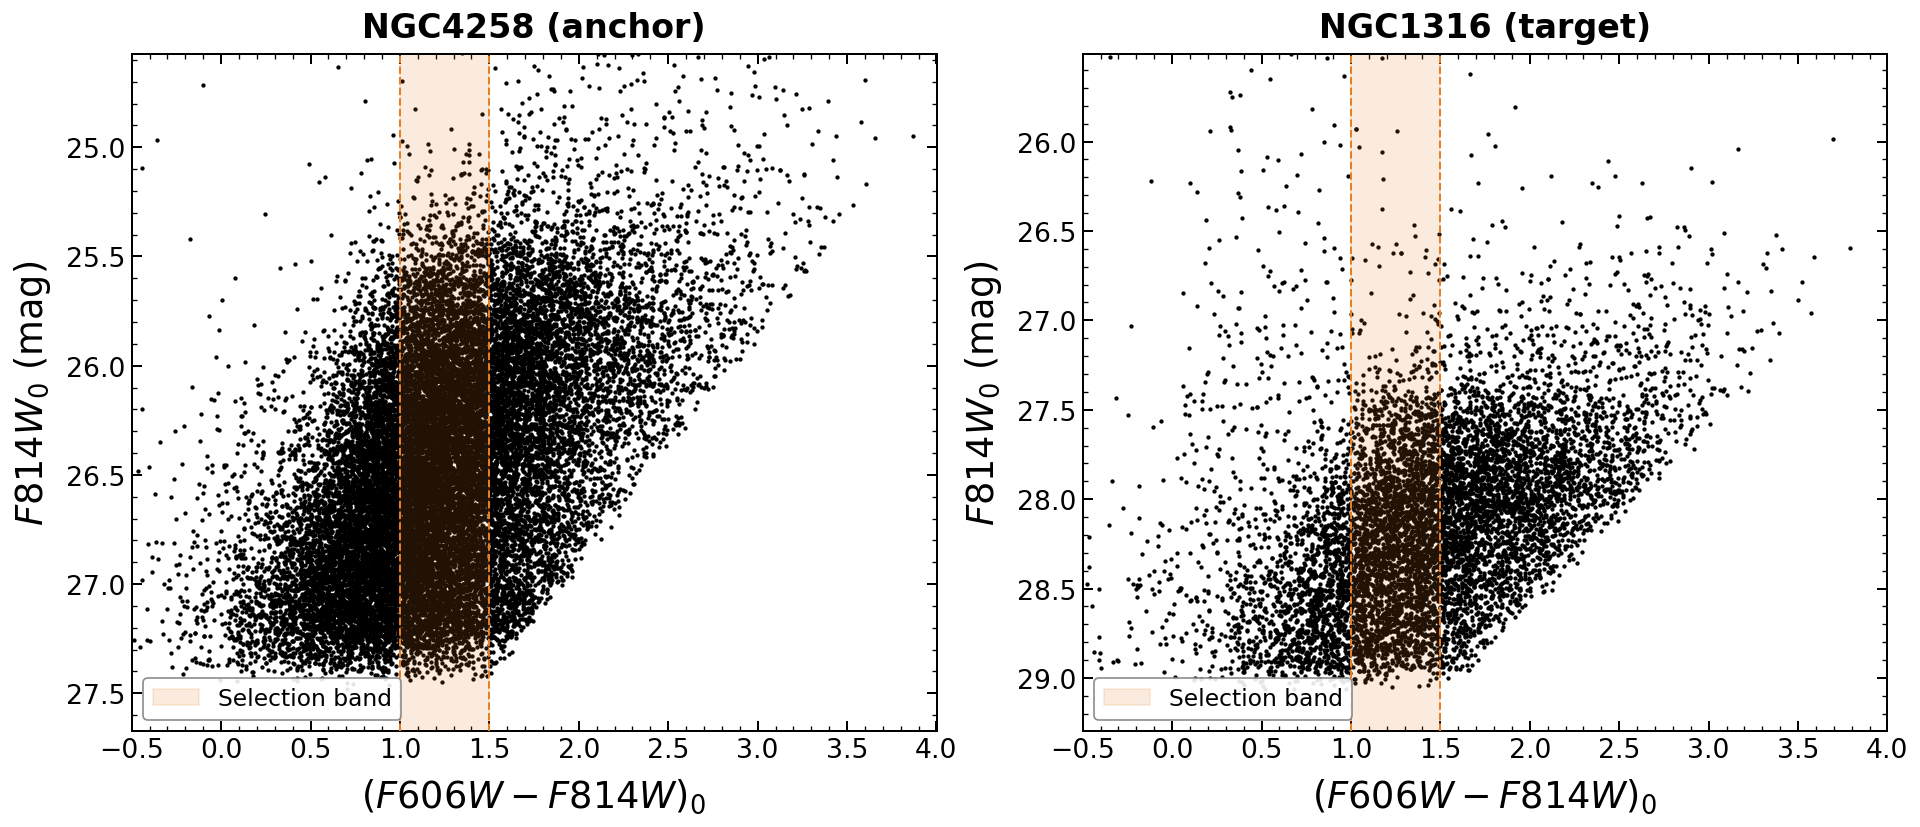


→ If the band does not cover the RGB, adjust SELECTION in Section 4 and re-run.
→ If satisfactory, proceed to Section 6.


In [47]:
# ── Consistent CMD style: matches the diagnostic plots in Sections 6 & 7 ──

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

for ax, info, label in [
    (axes[0], anchor_info, f'{anchor_info["name"]} (anchor)'),
    (axes[1], target_info, f'{target_info["name"]} (target)')
]:
    # --- Load photometry (respect user overrides) ---
    override = ANCHOR_PHOT_FILE if 'anchor' in label.lower() else TARGET_PHOT_FILE
    try:
        df = load_photometry_df(info['name'], DATA_DIR, PHOT_SOURCE, override)
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'{info["name"]}\nFile not found',
                transform=ax.transAxes, ha='center', va='center', fontsize=14)
        continue


    # Resolve magnitude columns robustly
    col1, col2 = get_mag_cols(df)

    # Convert to numpy immediately (avoid pandas alignment issues)
    m_all = df[col2].to_numpy(dtype=float)
    c_all = (df[col1] - df[col2]).to_numpy(dtype=float)

    # Physical sanity filter (guards against wrong column selection)
    valid = (
        np.isfinite(m_all) &
        np.isfinite(c_all) &
        (m_all > 18) & (m_all < 35)
    )

    if valid.sum() < 10:
        ax.text(0.5, 0.5,
                f'{info["name"]}\nNo valid stars\n(check columns)',
                transform=ax.transAxes,
                ha='center', va='center',
                fontsize=14, color='#e74c3c')
        print(f'WARNING: {label} — insufficient valid stars.')
        print(f'  col1={col1}, col2={col2}, '
              f'm range=[{np.nanmin(m_all):.1f}, {np.nanmax(m_all):.1f}]')
        continue

    c, m = c_all[valid], m_all[valid]

    # Robust plotting limits (avoid extreme outliers)
    m_lo = float(np.percentile(m, 0.5))
    m_hi = float(np.percentile(m, 99.5))

    # Use SELECTION for both galaxies here; the target-specific band
    # can be inspected after running Section 5b (quick-tune).
    sel = SELECTION

    # Plot CMD (style matches diagnostic plot: dark scatter, low alpha)
    ax.scatter(c, m, s=2.5, c='black',   alpha=1.0,  rasterized=True, zorder=1)

    # Draw vertical color cuts
    ax.axvspan(sel['color_lo'], sel['color_hi'],
               color='#e67e22', alpha=0.15, label='Selection band', zorder=2)
    ax.axvline(sel['color_lo'], color='#e67e22', lw=1.2, ls='--', zorder=3)
    ax.axvline(sel['color_hi'], color='#e67e22', lw=1.2, ls='--', zorder=3)

    _bf42 = (_detect_blue_filter(col1) or 'f606w').upper()
    ax.set_xlabel(rf'($\mathit{{{_bf42}}} - \mathit{{F814W}})_0$', fontsize=22, labelpad=8)
    ax.set_ylabel(r'$\mathit{F814W}_0$ (mag)', fontsize=22, labelpad=8)
    ax.set_ylim(m_hi + 0.3, m_lo - 0.3)
    ax.set_xlim(-0.5, 4.0)

    ax.tick_params(axis='both', labelsize=16, width=1.2, length=6)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='minor', length=3, width=0.8)

    ax.legend(fontsize=14, loc='lower left', frameon=True,
              framealpha=0.9, edgecolor='gray')
    ax.set_title(label, fontsize=20, fontweight='bold', pad=10)

    print(f'{label}: {len(df):,} total, {valid.sum():,} valid stars')
    print(f'  F814W [{m.min():.2f}, {m.max():.2f}], '
          f'color [{c.min():.2f}, {c.max():.2f}]')

plt.tight_layout()
plt.show()

print('\n→ If the band does not cover the RGB, adjust SELECTION in Section 4 and re-run.')
print('→ If satisfactory, proceed to Section 6.')

## 6. Measure TRGB in NGC 4258 (Anchor)

#### What

Run the full detection pipeline on the anchor galaxy NGC 4258 to measure the apparent TRGB magnitude.

#### Why

NGC 4258 is the calibrator. Its geometric distance is known from water maser observations (Reid et al. 2019), giving:

$$\mu_{\text{N4258}} = 29.397 \pm 0.032 \;\text{mag}$$

The absolute calibration follows directly:
$$M_{\text{TRGB}} = m_{\text{TRGB}}^{\text{corr}} - \mu_{\text{N4258}}$$
where $m_{\text{TRGB}}^{\text{corr}} = m_{\text{TRGB}} - A_{\text{F814W}}$ is the extinction-corrected apparent TRGB magnitude (see Section 8 for the full calibration chain).

---

### ⚠️ Failure modes and fixes

| Failure mode | What you see | Fix |
|---|---|---|
| Noise-driven detection | Jagged Sobel peak; unstable bootstrap; tip contrast < 2 | Increase `tau`; ask: is the data quality sufficient? |
| AGB contamination | TRGB too bright; LF shows counts above edge | Set `MAG_BRIGHT` just above the visible tip; tighten `color_hi` |
| Selection miss / over-clipping | Too few RGB stars; unstable bootstrap | Adjust band; reduce `scale_factor` slightly |

---

### Pipeline steps

This cell performs:

1. Load photometry  
2. Apply spatial clipping
3. Apply RGB color selection
4. Run GLOESS smoothing
5. Apply Sobel edge detection
6. Run bootstrap
7. Generate diagnostic plot
8. Store results

---

### What to check

- **CMD:** Band covers RGB; TRGB line matches visible tip  
- **LF:** Clear Sobel peak; tip contrast > 3  
- **Bootstrap:** Narrow, stable distribution  

> 💡 If unstable: adjust **τ first**, then selection, then spatial scale.

---

## 6a. Quick-Tune Parameters (Anchor)

Anchor galaxy parameters are editable here for rapid iteration so you don't need to scroll up by a lot each time. Update values, re-run this cell, then re-run the anchor TRGB measurement in the next cell to propagate changes.

This cell mirrors the anchor definitions in Section 4 but is optimized for fast visual tuning against the CMD and diagnostic plots.

> **Target galaxy parameters** are set at the top of Section 7 immediately before the measurement runs.

> Use this to refine alignment of the RGB selection, smoothing strength, and spatial clipping without scrolling back to Section 4.

### NGC 4258 color selection — mixed-filter cases (CATS and EDD)

When NGC 4258 data spans two blue filters (CATS fields 1–7, or EDD programs NGC4258_9477 + NGC4258_16198), the color band is set **independently** for each filter group with different flat-TRGB color limits (Jang & Lee 2017):

| Parameter | Blue filter | Flat-TRGB limit | Default range |
|-----------|-------------|-----------------|---------------|
| `SELECTION_ANCHOR_F606W` | F606W | (F606W−F814W)₀ ≤ 1.5 | [1.0, 1.5] |
| `SELECTION_ANCHOR_F555W` | F555W | (F555W−F814W)₀ ≤ 2.1 | [1.6, 2.1] |

Adjust `color_lo` and `color_hi` in each dict after inspecting the two CMDs. The hard upper limits are enforced by sanity checks. `tau` and `scale_factor` apply to both groups.

For EDD galaxies where all programs use the same filter, a single `SELECTION['color_lo']` / `SELECTION['color_hi']` applies.

---

In [53]:
# ============================================================
# QUICK-TUNE (ANCHOR): edit here, then re-run Section 6.
# Target parameters are set at the top of Section 7.
# ============================================================

# ── Shared anchor parameters ───────────────────────────────
SMOOTHING['tau']        = 0.1     # increasing smooths the LF more (more stable, may bias tip slightly faint); decreasing is noisier
SPATIAL['scale_factor'] = 1.0     # increasing enlarges the exclusion ellipse (only far-halo stars kept); decreasing includes stars closer to the disk
# MAG_FAINT = 26 # you can implement a faint cut for NGC 4258 as the data from GO-9477 as it's depth introduces a strong, spurious peak > 1 mag from the TRGB

if PHOT_SOURCE == 'CATS':
    # NGC 4258 CATS fields span two blue filters, each with its own
    # flat-TRGB color limit (Jang & Lee 2017):
    #   F606W-F814W  flat for (F606W-F814W)_0 <= 1.5 mag
    #   F555W-F814W  flat for (F555W-F814W)_0 <= 2.1 mag
    # Set color_lo and color_hi independently for each filter group.

    # F606W fields (5-7): flat-TRGB limit 1.5 mag
    SELECTION_ANCHOR_F606W = dict(SELECTION)
    SELECTION_ANCHOR_F606W['color_lo'] = 1.0   # blue edge
    SELECTION_ANCHOR_F606W['color_hi'] = 1.5   # max 1.5 (Jang & Lee 2017, F606W-F814W)

    # F555W fields (1-4): flat-TRGB limit 2.1 mag
    SELECTION_ANCHOR_F555W = dict(SELECTION)
    SELECTION_ANCHOR_F555W['color_lo'] = 1.6   # blue edge
    SELECTION_ANCHOR_F555W['color_hi'] = 2.1   # max 2.1 (Jang & Lee 2017, F555W-F814W)

    # ── Sanity checks ───────────────────────────────────────
    if SPATIAL['scale_factor'] <= 0:
        raise ValueError('Spatial scale_factor must be > 0 (clipping required).')
    if SELECTION_ANCHOR_F606W['color_hi'] > 1.5:
        raise ValueError(
            f"SELECTION_ANCHOR_F606W['color_hi'] = {SELECTION_ANCHOR_F606W['color_hi']:.2f} "
            'exceeds the F606W-F814W flat-TRGB limit of 1.5 mag (Jang & Lee 2017).'
        )
    if SELECTION_ANCHOR_F555W['color_hi'] > 2.1:
        raise ValueError(
            f"SELECTION_ANCHOR_F555W['color_hi'] = {SELECTION_ANCHOR_F555W['color_hi']:.2f} "
            'exceeds the F555W-F814W flat-TRGB limit of 2.1 mag (Jang & Lee 2017).'
        )

    # ── Summary ─────────────────────────────────────────────
    print(f"Anchor ({anchor_info['name']}) — CATS, two filter groups")
    print(f"  F606W (fields 5-7): color=[{SELECTION_ANCHOR_F606W['color_lo']}, {SELECTION_ANCHOR_F606W['color_hi']}]")
    print(f"  F555W (fields 1-4): color=[{SELECTION_ANCHOR_F555W['color_lo']}, {SELECTION_ANCHOR_F555W['color_hi']}]")
    print(f"  tau={SMOOTHING['tau']}, scale={SPATIAL['scale_factor']}")

elif PHOT_SOURCE == 'EDD':
    # Check if the anchor has mixed-filter EDD files (e.g. NGC4258_9477 F555W + NGC4258_16198 F606W)
    _qt_edd_files = find_photometry_file(anchor_info['name'], DATA_DIR)
    _qt_f555 = [f for f in _qt_edd_files if _edd_blue_filter(f) == 'f555w']
    _qt_f606 = [f for f in _qt_edd_files if _edd_blue_filter(f) == 'f606w']
    _qt_mixed = bool(_qt_f555) and bool(_qt_f606)

    if _qt_mixed:
        # Two filter groups — set independently
        SELECTION_ANCHOR_F606W = dict(SELECTION)
        SELECTION_ANCHOR_F606W['color_lo'] = 1.0   # blue edge
        SELECTION_ANCHOR_F606W['color_hi'] = 1.5   # max 1.5 (Jang & Lee 2017, F606W-F814W)

        SELECTION_ANCHOR_F555W = dict(SELECTION)
        SELECTION_ANCHOR_F555W['color_lo'] = 1.6   # blue edge
        SELECTION_ANCHOR_F555W['color_hi'] = 2.1   # max 2.1 (Jang & Lee 2017, F555W-F814W)

        if SPATIAL['scale_factor'] <= 0:
            raise ValueError('Spatial scale_factor must be > 0 (clipping required).')
        if SELECTION_ANCHOR_F606W['color_hi'] > 1.5:
            raise ValueError(
                f"SELECTION_ANCHOR_F606W['color_hi'] = {SELECTION_ANCHOR_F606W['color_hi']:.2f} "
                'exceeds the F606W-F814W flat-TRGB limit of 1.5 mag (Jang & Lee 2017).'
            )
        if SELECTION_ANCHOR_F555W['color_hi'] > 2.1:
            raise ValueError(
                f"SELECTION_ANCHOR_F555W['color_hi'] = {SELECTION_ANCHOR_F555W['color_hi']:.2f} "
                'exceeds the F555W-F814W flat-TRGB limit of 2.1 mag (Jang & Lee 2017).'
            )

        print(f"Anchor ({anchor_info['name']}) — EDD, two filter groups")
        print(f"  F606W: color=[{SELECTION_ANCHOR_F606W['color_lo']}, {SELECTION_ANCHOR_F606W['color_hi']}]")
        print(f"  F555W: color=[{SELECTION_ANCHOR_F555W['color_lo']}, {SELECTION_ANCHOR_F555W['color_hi']}]")
        print(f"  tau={SMOOTHING['tau']}, scale={SPATIAL['scale_factor']}")
    else:
        # Single filter — set one selection
        SELECTION['color_lo'] = 1.0
        SELECTION['color_hi'] = 1.5

        if SPATIAL['scale_factor'] <= 0:
            raise ValueError('Spatial scale_factor must be > 0 (clipping required).')
        if SELECTION['color_hi'] > COLOR_HI_MAX:
            raise ValueError(
                f"color_hi = {SELECTION['color_hi']:.2f} exceeds {COLOR_HI_MAX} mag. "
                'Jang & Lee (2017) show the F814W TRGB is only flat for '
                '(F606W-F814W)_0 <= 1.5. Reduce color_hi or apply a color correction.'
            )

        print(f"Anchor ({anchor_info['name']}) — EDD, single filter: "
              f"color=[{SELECTION['color_lo']}, {SELECTION['color_hi']}], "
              f"tau={SMOOTHING['tau']}, scale={SPATIAL['scale_factor']}")

else:
    # Any other single-filter source
    SELECTION['color_lo'] = 1.0   # increasing moves the left (blue) edge of the color window right
    SELECTION['color_hi'] = 1.5   # decreasing moves the right (red) edge left; max depends on filter

    # ── Sanity checks ───────────────────────────────────────
    if SPATIAL['scale_factor'] <= 0:
        raise ValueError('Spatial scale_factor must be > 0 (clipping required).')
    if SELECTION['color_hi'] > COLOR_HI_MAX:
        raise ValueError(
            f"color_hi = {SELECTION['color_hi']:.2f} exceeds {COLOR_HI_MAX} mag. "
            'Jang & Lee (2017) show the F814W TRGB is only flat for '
            '(F606W-F814W)_0 <= 1.5. Reduce color_hi or apply a color correction.'
        )

    # ── Summary ─────────────────────────────────────────────
    print(f"Anchor ({anchor_info['name']}) — "
          f"color=[{SELECTION['color_lo']}, {SELECTION['color_hi']}], "
          f"tau={SMOOTHING['tau']}, scale={SPATIAL['scale_factor']}")

print('\nAnchor parameters updated. Re-run anchor TRGB measurement.')

  ../photometry/EDD/NGC4258_16198.csv
  ../photometry/EDD/NGC4258_9477.csv
Anchor (NGC4258) — EDD, two filter groups
  F606W: color=[1.0, 1.5]
  F555W: color=[1.6, 2.1]
  tau=0.1, scale=1.0

Anchor parameters updated. Re-run anchor TRGB measurement.


> ⚠️ **About `RuntimeError: tip contrast below threshold`**
>
> This error (raised in Sections 6–8) is **intentional and expected** until you have inspected the CMD and tuned the parameters in Section 4. It means the algorithm cannot reliably identify the TRGB edge and is stopping you before producing a noisy result. To proceed:
> 1. Inspect the CMD in Section 5 and adjust `color_lo`, `color_hi`, `tau`, and `scale_factor` in Section 4.
> 2. Re-run from Section 4 onward.
> 3. Once the detection looks clean (tip contrast > 3, unimodal bootstrap), set `USE_ANCHOR_RESULT = True` (Section 6) or `USE_TARGET_RESULT = True` (Section 7) as directed to continue to distance computation.

  ../photometry/EDD/NGC4258_16198.csv
  ../photometry/EDD/NGC4258_9477.csv

--------------------------------------------------
Anchor NGC4258 [F555W]
--------------------------------------------------
  ../photometry/EDD/NGC4258_16198.csv
  ../photometry/EDD/NGC4258_9477.csv
  EDD [F555W]: 1 file(s):
    NGC4258_9477.csv
  Blue filter: F555W − F814W  (color limit: 2.1 mag)
  48,277 sources loaded.
  Spatial clip [sky (RA/DEC)]: scale=1.0× D25, R25=558"
  Kept 12652 halo stars, clipped 35625 inner stars (26% kept)
  Diagnostic: ensure the disk/bulge are removed while the halo remains well sampled.


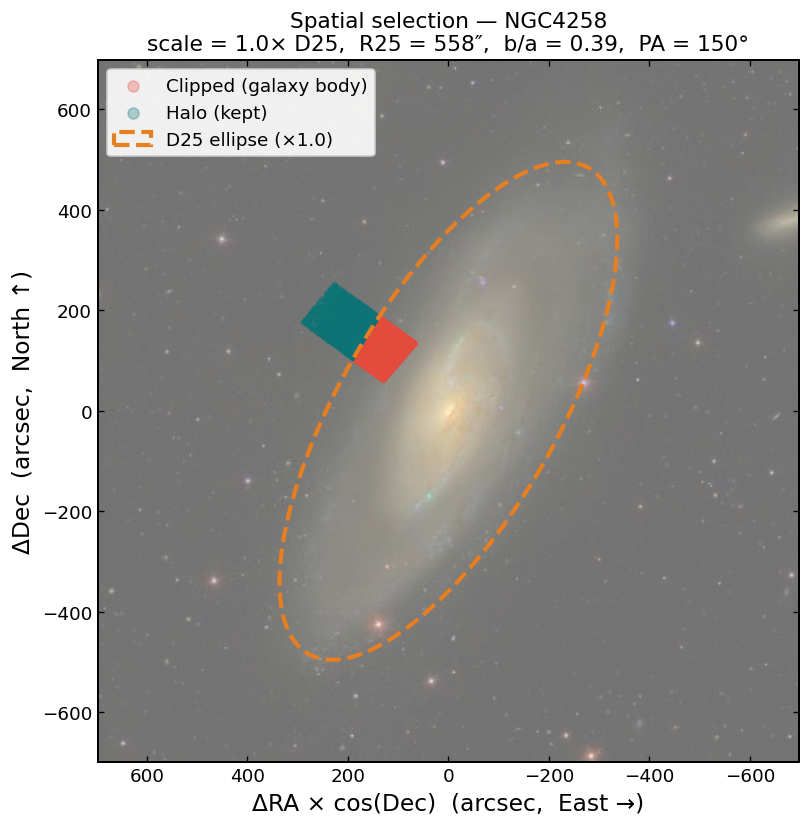

  Filter detected: F555W − F814W  →  flat-TRGB color limit = 2.1 mag (Jang & Lee 2017)
  Extinction correction applied: A_F814W=0.0214, A_color=0.0220 (F555W−F814W)
  LF magnitude range: [24.69, 27.81]
  Selected 2,369 RGB stars out of 12,652 halo stars.
  TRGB (single pass) = 25.330 mag, tip contrast = 7.1
  Running bootstrap (500 iterations)...
  Bootstrap complete in 0.3s.
  TRGB (robust) = 25.340 ± 0.044 mag


/var/folders/p3/vg1hj8kx3nj41vxd13mz8y_m0000gn/T/ipykernel_2839/1317675292.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


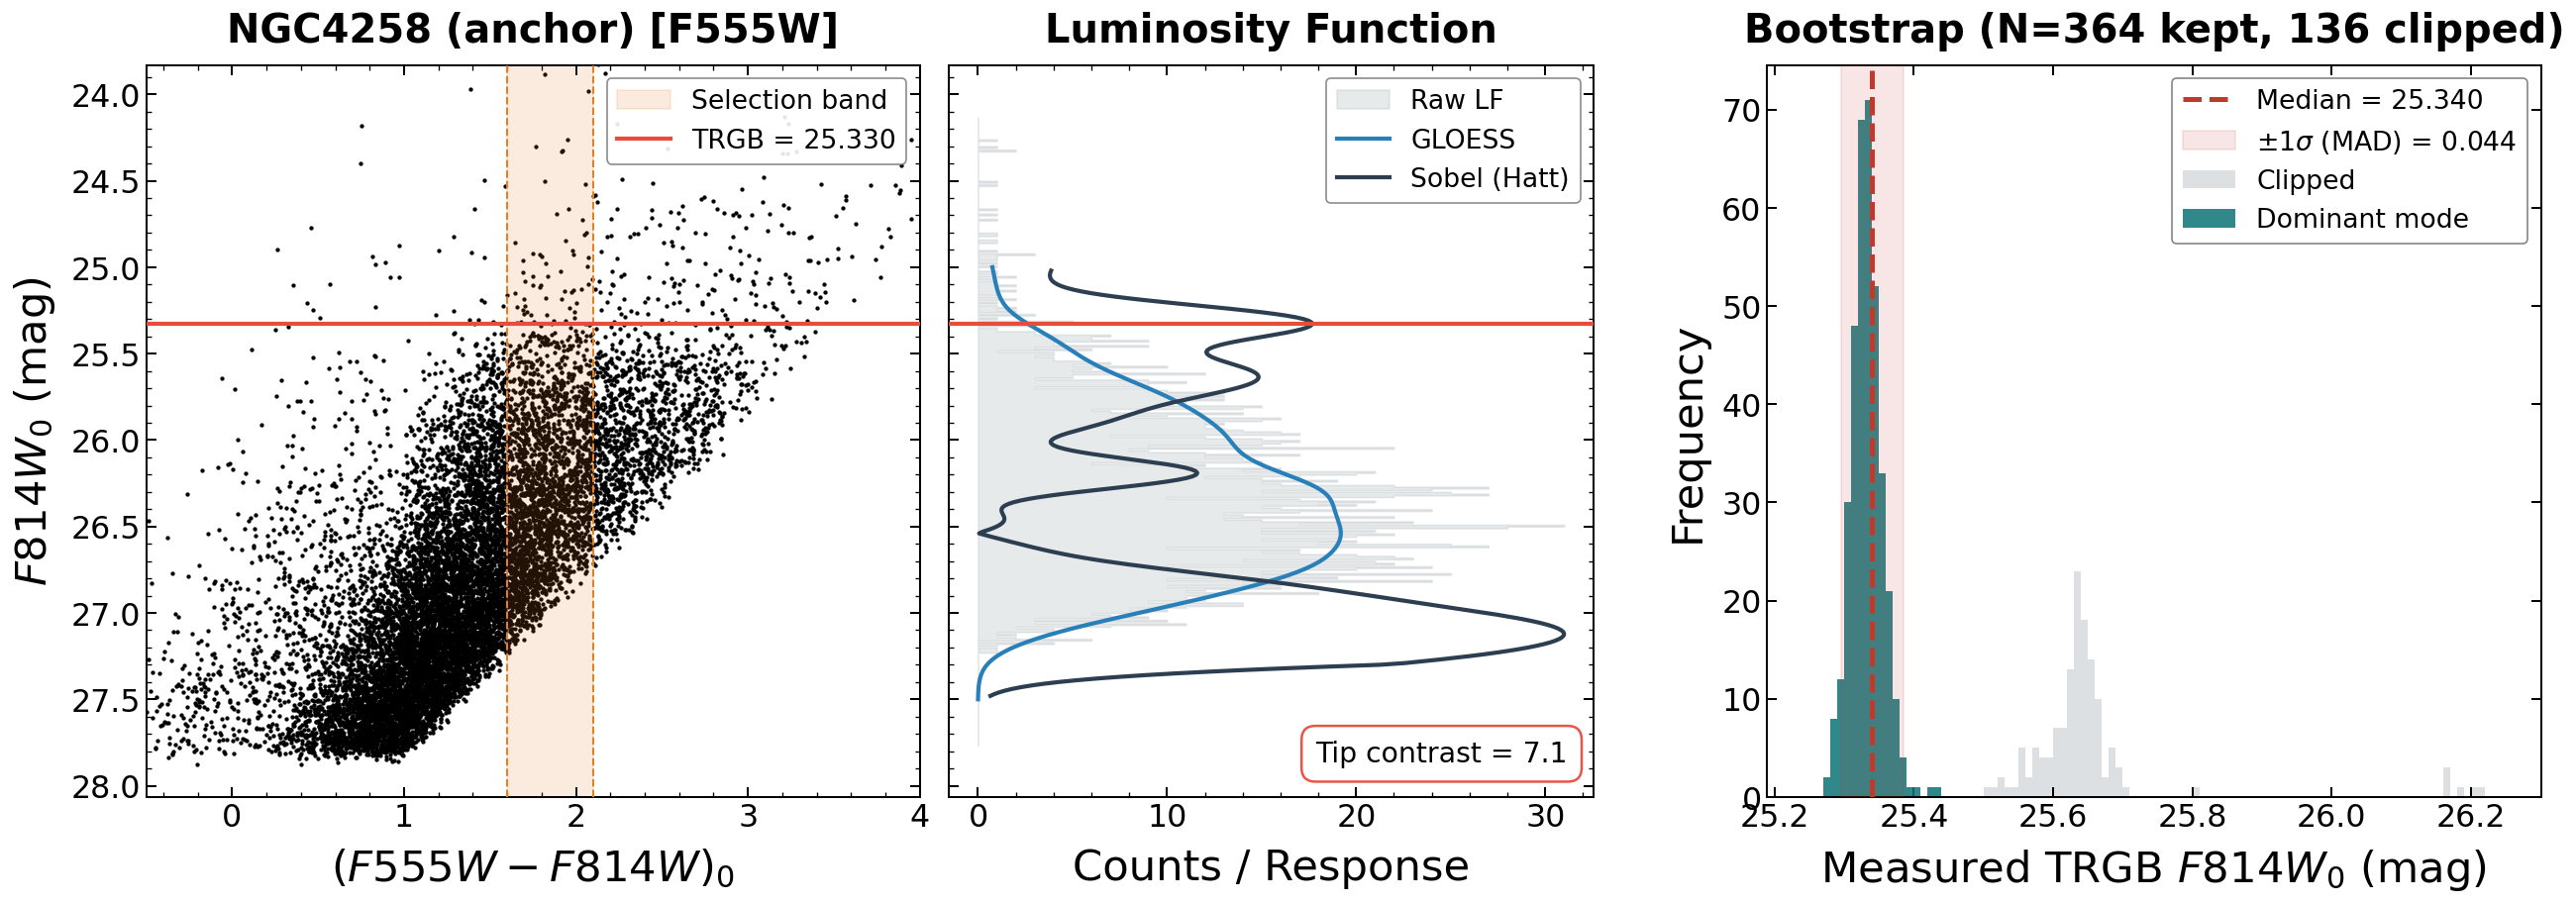


--------------------------------------------------
Anchor NGC4258 [F606W]
--------------------------------------------------
  ../photometry/EDD/NGC4258_16198.csv
  ../photometry/EDD/NGC4258_9477.csv
  EDD [F606W]: 1 file(s):
    NGC4258_16198.csv
  Blue filter: F606W − F814W  (color limit: 1.5 mag)
  23,410 sources loaded.
  Spatial clip [sky (RA/DEC)]: scale=1.0× D25, R25=558"
  Kept 20773 halo stars, clipped 2637 inner stars (89% kept)
  Diagnostic: ensure the disk/bulge are removed while the halo remains well sampled.


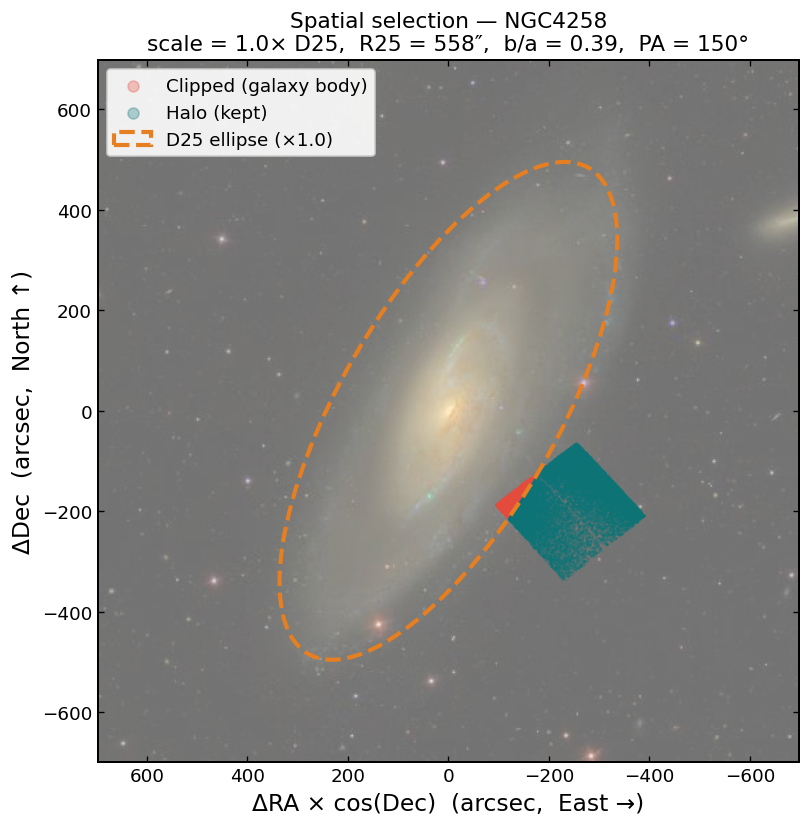

  Filter detected: F606W − F814W  →  flat-TRGB color limit = 1.5 mag (Jang & Lee 2017)
  Extinction correction applied: A_F814W=0.0214, A_color=0.0132 (F606W−F814W)
  LF magnitude range: [24.89, 27.36]
  Selected 8,003 RGB stars out of 20,773 halo stars.
  TRGB (single pass) = 25.401 mag, tip contrast = 10.6
  Running bootstrap (500 iterations)...
  Bootstrap complete in 0.4s.
  TRGB (robust) = 25.441 ± 0.089 mag


/var/folders/p3/vg1hj8kx3nj41vxd13mz8y_m0000gn/T/ipykernel_2839/1317675292.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


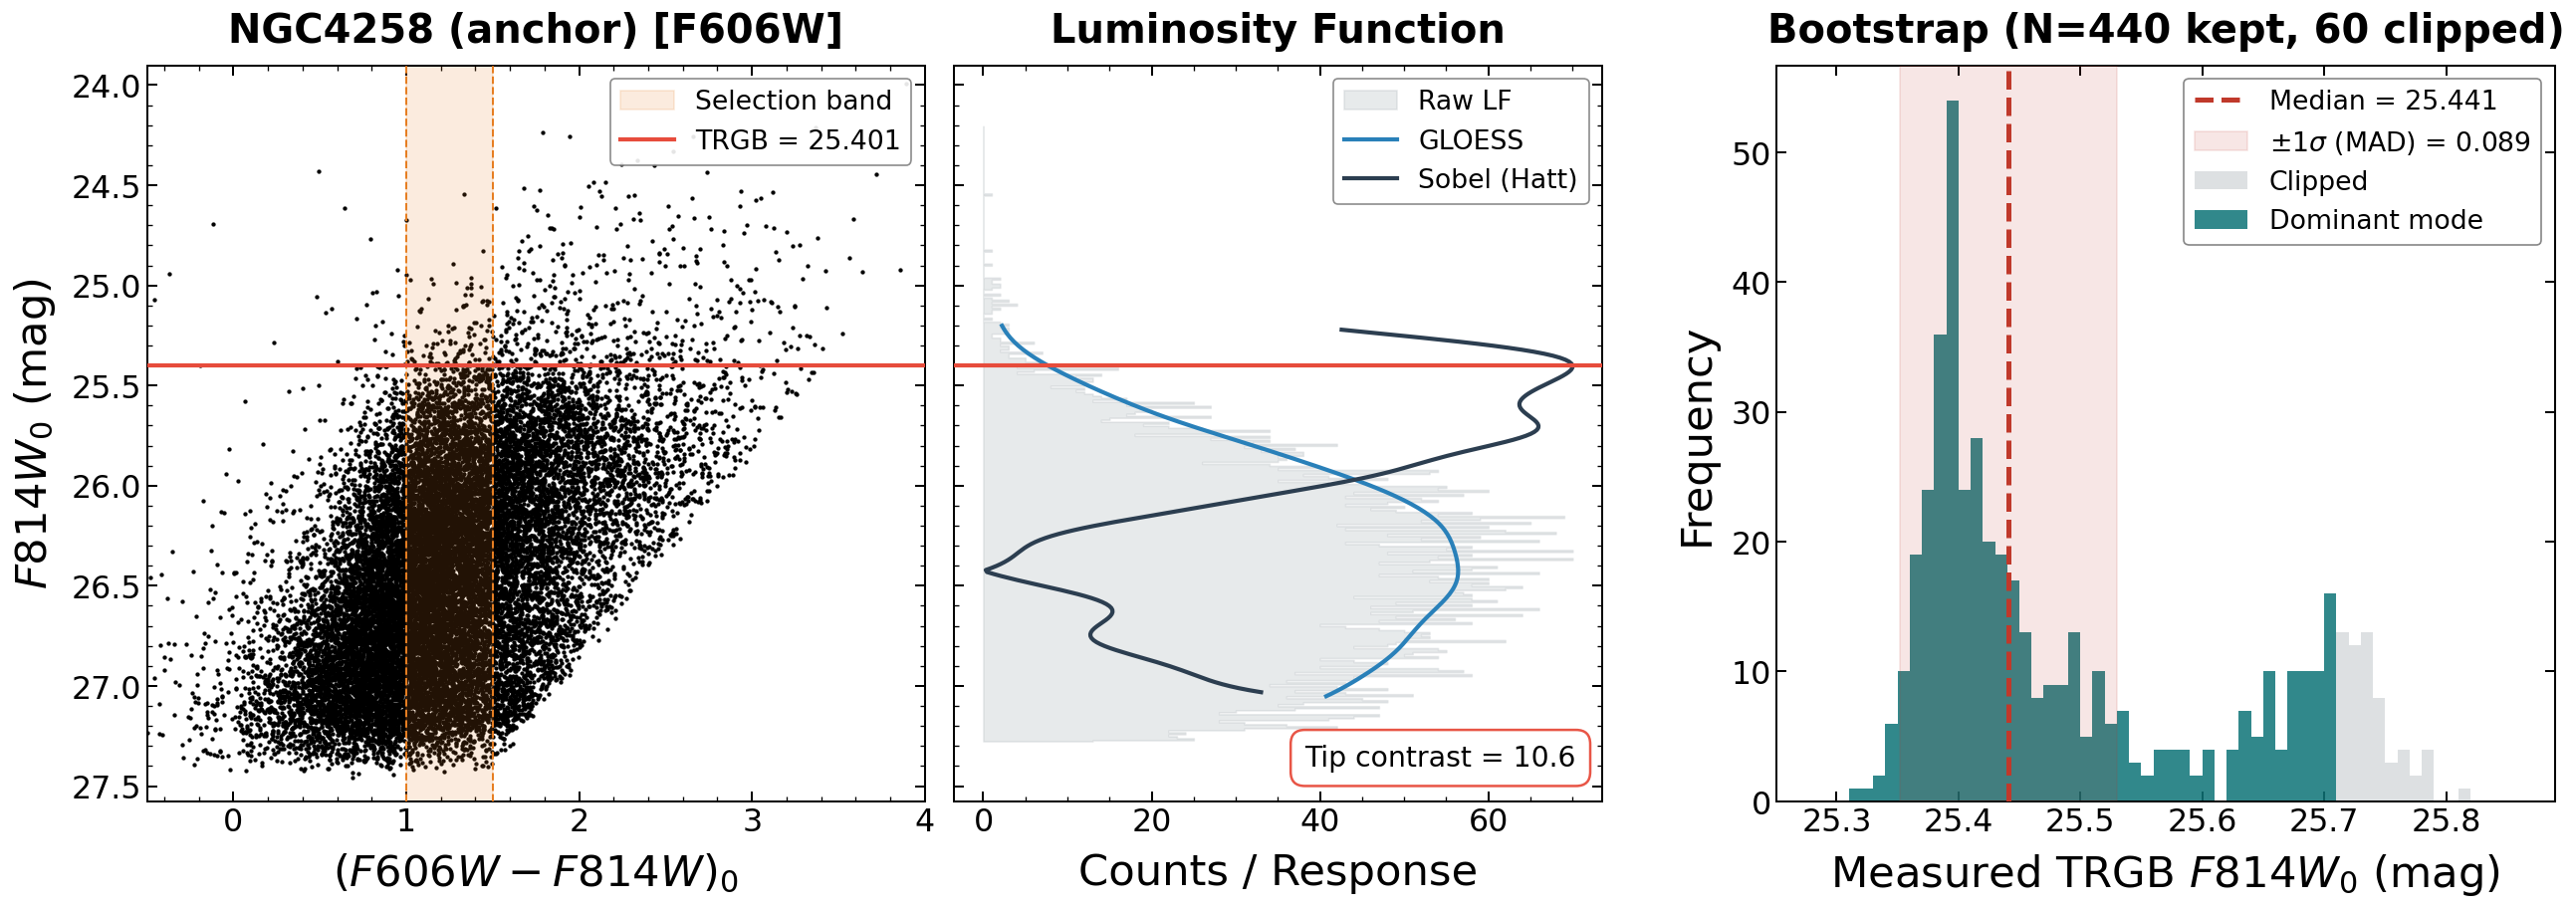


Anchor TRGB — inverse-variance weighted combination (EDD)
  F555W (fields 1-4): 25.340 ± 0.044
  F606W (fields 5-7): 25.441 ± 0.089
  Combined:           25.360 ± 0.040

  Result stored in result_anchor.

  ✓  Tip contrast = 7.1 (> 3). Anchor detection accepted.


In [54]:
# --- Anchor galaxy: geometric distance from water maser orbits ---
# These are fixed external inputs from Reid et al. (2019).
MU_N4258     = 29.397    # distance modulus (mag)
MU_N4258_ERR = 0.032     # uncertainty (mag)

# --- Determine filter groups ---
# NGC 4258 photometry may span two blue filter sets (F555W and F606W).
# Running mixed filters on a single CMD produces an inconsistent color axis
# and misapplies the Jang & Lee (2017) flat-TRGB color limit. When both
# filter groups are present, the pipeline runs once per group and combines
# the two TRGB measurements via inverse-variance weighting.
#   CATS: F555W = fields 1-4, F606W = fields 5-7
#   EDD:  F555W = NGC4258_9477, F606W = NGC4258_16198
if PHOT_SOURCE == 'CATS':
    _all_anc = find_photometry_file(anchor_info['name'], DATA_DIR)
    _f555 = [f for f in _all_anc
             if any(k in os.path.basename(f) for k in CATS_NGC4258_F555W_FIELDS)]
    _f606 = [f for f in _all_anc if f not in _f555]
    _filt_groups = [(filt, files)
                    for filt, files in [('F555W', _f555), ('F606W', _f606)] if files]
else:  # EDD
    _all_anc = find_photometry_file(anchor_info['name'], DATA_DIR)
    _f555 = [f for f in _all_anc if _edd_blue_filter(f) == 'f555w']
    _f606 = [f for f in _all_anc if _edd_blue_filter(f) == 'f606w']
    if _f555 and _f606:
        _filt_groups = [(filt, files)
                        for filt, files in [('F555W', _f555), ('F606W', _f606)] if files]
    else:
        _filt_groups = [(None, None)]   # single-filter EDD path

_per_filt_anchor = {}

for _filt, _ in _filt_groups:
    _label = f' [{_filt}]' if _filt else ''
    if _filt == 'F555W':
        _sel_a = SELECTION_ANCHOR_F555W
    elif _filt == 'F606W':
        _sel_a = SELECTION_ANCHOR_F606W
    else:
        _sel_a = SELECTION   # single-filter path
    print()
    print('-' * 50)
    print(f'Anchor {anchor_info["name"]}{_label}')
    print('-' * 50)

    # --- Load photometry ---
    df_anchor = load_photometry_df(
        anchor_info['name'], DATA_DIR, PHOT_SOURCE, ANCHOR_PHOT_FILE,
        cats_filter=_filt if PHOT_SOURCE == 'CATS' else None,
        edd_filter=_filt if PHOT_SOURCE == 'EDD' else None)

    # --- Spatial clipping: keep only halo stars ---
    fits_files = find_fits_file(anchor_info['name'], SPATIAL['fits_dir'])
    fits_file = fits_files[0] if fits_files else None
    mask_halo = apply_spatial_clip(
        df_anchor, anchor_info, PHOT_SOURCE,
        scale_factor=SPATIAL['scale_factor'],
        fits_file=fits_file, show_plot=True,
        img_size_factor=2.5)

    df_anchor_halo = df_anchor[mask_halo].copy()

    # --- Build color and magnitude arrays ---
    col1_a, col2_a = get_mag_cols(df_anchor_halo)
    color_a = df_anchor_halo[col1_a].values - df_anchor_halo[col2_a].values
    mag_a   = df_anchor_halo[col2_a].values

    # --- Apply extinction correction (Jang & Lee 2017 limits are for dereddened colors) ---
    _blue_filt_a = _detect_blue_filter(col1_a) or 'f606w'
    _A_blue_a    = anchor_info['A_F555W'] if 'f555w' in _blue_filt_a else anchor_info['A_F606W']
    _A_color_a   = _A_blue_a - anchor_info['A_F814W']
    color_a = color_a - _A_color_a
    mag_a   = mag_a   - anchor_info['A_F814W']
    print(f'  Extinction correction applied: '
          f'A_F814W={anchor_info["A_F814W"]:.4f}, '
          f'A_color={_A_color_a:.4f} ({_blue_filt_a.upper()}−F814W)')

    # --- Determine magnitude range for the LF ---
    mag_range_a = (
        MAG_BRIGHT if MAG_BRIGHT is not None else np.percentile(mag_a, 0.5),
        MAG_FAINT  if MAG_FAINT  is not None else np.percentile(mag_a, 99.5)
    )
    print(f'  LF magnitude range: [{mag_range_a[0]:.2f}, {mag_range_a[1]:.2f}]')

    # --- Color selection: isolate RGB stars ---
    selected_mag_a, mask_sel_a = select_rgb(color_a, mag_a, _sel_a)
    print(f'  Selected {np.sum(mask_sel_a):,} RGB stars '
          f'out of {len(mag_a):,} halo stars.')

    if np.sum(mask_sel_a) < 30:
        raise RuntimeError(
            f'Too few RGB stars in anchor NGC 4258{_label} ({np.sum(mask_sel_a)} < 30). '
            'Adjust SELECTION or scale_factor before proceeding.'
        )
    elif np.sum(mask_sel_a) < 100:
        print(f'  ⚠️  Low star count ({np.sum(mask_sel_a)}). '
              'Bootstrap uncertainty will be larger than typical.')

    # --- Measure TRGB: GLOESS smoothing + Sobel edge detection ---
    trgb_a, smooth_lf_a, mc_a, resp_a, xs_a = measure_trgb(
        selected_mag_a, SMOOTHING, EDGE, mag_range=mag_range_a)
    tc_a = tip_contrast(selected_mag_a, trgb_a, CONTRAST_HALF_MAG)
    print(f'  TRGB (single pass) = {trgb_a:.3f} mag, '
          f'tip contrast = {tc_a:.1f}')

    # --- Bootstrap: statistical uncertainty ---
    print(f'  Running bootstrap ({BOOTSTRAP["n_boot"]} iterations)...')
    t0 = time.time()
    boot_a = run_bootstrap(
        color_a, mag_a, _sel_a, SMOOTHING, EDGE,
        mag_range=mag_range_a,
        n_boot=BOOTSTRAP['n_boot'],
        n_jobs=BOOTSTRAP['n_jobs'])
    dt = time.time() - t0
    print(f'  Bootstrap complete in {dt:.1f}s.')

    # --- Robust statistics (handles multimodal bootstrap) ---
    trgb_a_robust, sigma_a, mask_keep_a = robust_bootstrap_stats(boot_a)
    print(f'  TRGB (robust) = {trgb_a_robust:.3f} ± {sigma_a:.3f} mag')

    # --- Diagnostic plot ---
    plot_trgb_diagnostic(
        color_a, mag_a, selected_mag_a, _sel_a, trgb_a,
        smooth_lf_a, mc_a, resp_a, xs_a,
        tc_a, boot_a, trgb_a_robust, sigma_a, mask_keep_a,
        galaxy_name=f'{anchor_info["name"]} (anchor){_label}',
        blue_filter=(_detect_blue_filter(col1_a) or 'f606w').upper())

    _per_filt_anchor[_filt or 'default'] = {
        'trgb_single': trgb_a,
        'trgb_mean':   trgb_a_robust,
        'trgb_err':    sigma_a,
        'tip_contrast': tc_a,
        'boot_values': boot_a,
        'n_selected':  len(selected_mag_a),
    }

# --- Combine filter groups (CATS, when both F555W and F606W are present) ---
if len(_filt_groups) == 2:
    _r555 = _per_filt_anchor['F555W']
    _r606 = _per_filt_anchor['F606W']
    _w555 = 1 / _r555['trgb_err']**2
    _w606 = 1 / _r606['trgb_err']**2
    _trgb_comb  = (_r555['trgb_mean'] * _w555 + _r606['trgb_mean'] * _w606) / (_w555 + _w606)
    _sigma_comb = 1 / np.sqrt(_w555 + _w606)
    print()
    print('=' * 65)
    _src_tag = 'CATS' if PHOT_SOURCE == 'CATS' else 'EDD'
    print(f'Anchor TRGB — inverse-variance weighted combination ({_src_tag})')
    print(f'  F555W (fields 1-4): {_r555["trgb_mean"]:.3f} ± {_r555["trgb_err"]:.3f}')
    print(f'  F606W (fields 5-7): {_r606["trgb_mean"]:.3f} ± {_r606["trgb_err"]:.3f}')
    print(f'  Combined:           {_trgb_comb:.3f} ± {_sigma_comb:.3f}')
    print('=' * 65)
    result_anchor = {
        'trgb_single': _trgb_comb,
        'trgb_mean':   _trgb_comb,
        'trgb_err':    _sigma_comb,
        'tip_contrast': min(_r555['tip_contrast'], _r606['tip_contrast']),
        'boot_values': np.concatenate([_r555['boot_values'], _r606['boot_values']]),
        'n_selected':  _r555['n_selected'] + _r606['n_selected'],
    }
else:
    result_anchor = _per_filt_anchor['default']

print(f'\n  Result stored in result_anchor.')

# --- Tip contrast diagnostic (mirrors Section 7 two-tier logic) ----------
_tc_final = result_anchor['tip_contrast']
print()
print('=' * 65)

if _tc_final <= 2.0:
    print(f'  ✖ VERY LOW TIP CONTRAST ({_tc_final:.2f}) — anchor detection unreliable')
    print('  Action: Increase tau and/or tighten RGB selection.')
    USE_ANCHOR_RESULT = False

elif _tc_final <= 3.0:
    print(f'  ⚠ LOW TIP CONTRAST ({_tc_final:.2f}) — inspect diagnostic plot carefully')
    print('  Action: Verify Sobel peak and bootstrap stability before trusting.')
    USE_ANCHOR_RESULT = None

else:
    print(f'  ✓  Tip contrast = {_tc_final:.1f} (> 3). Anchor detection accepted.')
    USE_ANCHOR_RESULT = True

print('=' * 65)

> ✅ **Next:** If the detection looks clean (tip contrast > 3, unimodal bootstrap), proceed to Section 7. Otherwise, adjust parameters in Section 4 and re-run this cell.


## 7. Measure TRGB in Target Galaxy

#### What

Run the same pipeline on the target galaxy to measure its apparent TRGB magnitude.

#### Why

Combined with the calibrated absolute TRGB magnitude from Section 6, the apparent TRGB magnitude gives the target distance.

---

### ⚠️ Failure modes and fixes

| Failure mode | What you see | Fix |
|---|---|---|
| Noise-driven detection | Jagged Sobel peak; unstable or multimodal bootstrap; tip contrast < 2 | Increase `tau` |
| AGB contamination | TRGB too bright; LF shows counts above edge | Set `MAG_BRIGHT` just above the visible tip; tighten `color_hi` |
| Selection miss / over-clipping | Too few RGB stars; unstable bootstrap | Widen `color_hi` or lower `color_lo`; reduce `scale_factor` |

---

### Do you need different selection parameters?

Sometimes yes.

- The target is at a different distance → RGB shifts in magnitude  
- Stellar population differences → RGB shifts in color  

Check the CMD (Section 5). Generally, consistent parameter selection between anchor and target galaxies helps mitigate bias propagation due to the relative nature of the distance ladder. It is recommended to use the same parameters unless there is an explicit reason not to. 

### ⚠️ Remember that we are selecting the blue regime where the TRGB is least sensitive to metallicity/color. If there are many stars redward of your color band, that is okay!

---

### Parameter override

This cell uses independent copies of the anchor parameters:

- `SELECTION_TARGET` (color band)
- `SPATIAL_TARGET` (halo clipping)

Modify only what is needed; leave the rest inherited.

---

### What to check

- **N_faint (Madore et al. 2009):** At least 400 RGB stars should lie within 1 mag below
  the detected TRGB. Fewer stars indicate insufficient statistics for a reliable detection.
  A warning flag `N_FAINT_OK` is printed below and stored in `result_target`.

- **CMD:** Band covers the RGB; TRGB line matches the visible tip  
- **LF:** Clear Sobel peak; tip contrast > 3  
- **Bootstrap:** Stable, compact distribution  

> 💡 If unstable: adjust **τ first**, then selection, then spatial scale.

  Loading: NGC5584_11570.csv
  Blue filter: F555W − F814W  (color limit: 2.1 mag)
  13,097 sources loaded.
  Spatial clip [sky (RA/DEC)]: scale=1.0× D25, R25=102"
  Kept 539 halo stars, clipped 12558 inner stars (4% kept)
  Diagnostic: ensure the disk/bulge are removed while the halo remains well sampled.


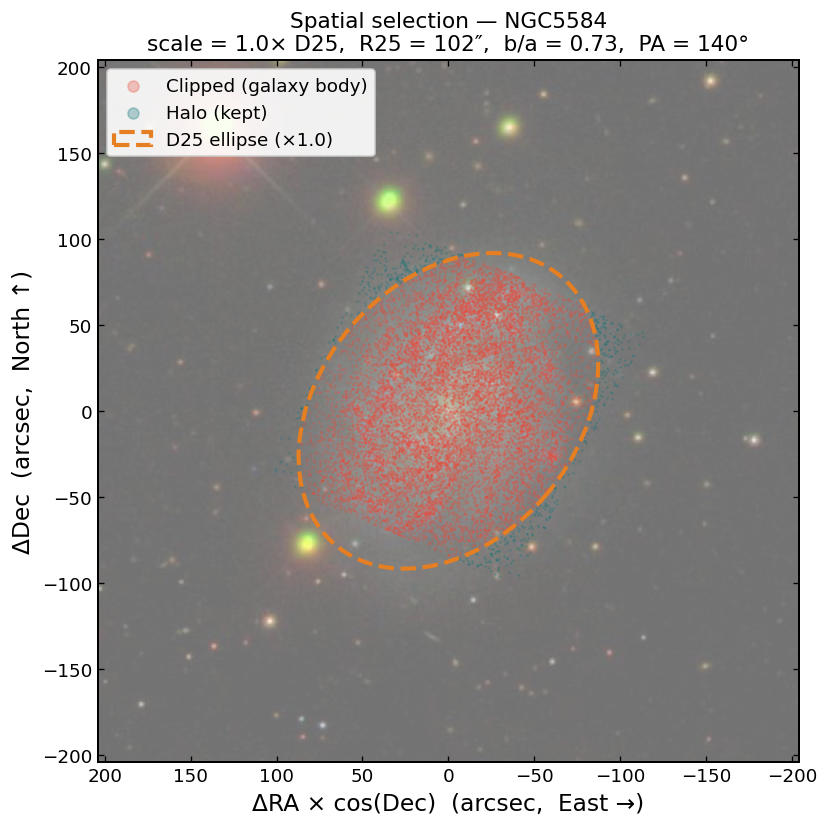

  Filter detected: F555W − F814W  →  flat-TRGB color limit = 2.1 mag (Jang & Lee 2017)
  Extinction correction applied: A_F814W=0.0534, A_color=0.0551 (F555W−F814W)
  Selected 56 RGB stars out of 539 halo stars.
  ⚠️  Low star count (56). TRGB detection may be noisy. Bootstrap uncertainty will be larger than typical.
  TRGB (single pass) = 27.581 mag
  Tip contrast       = 3.75
  Running bootstrap (500 iterations)...
  Bootstrap: 421/500 iterations succeeded (79 failed due to insufficient stars).
  Bootstrap complete in 0.3s.
  TRGB (robust) = 27.591 ± 0.044 mag


/var/folders/p3/vg1hj8kx3nj41vxd13mz8y_m0000gn/T/ipykernel_2839/1317675292.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


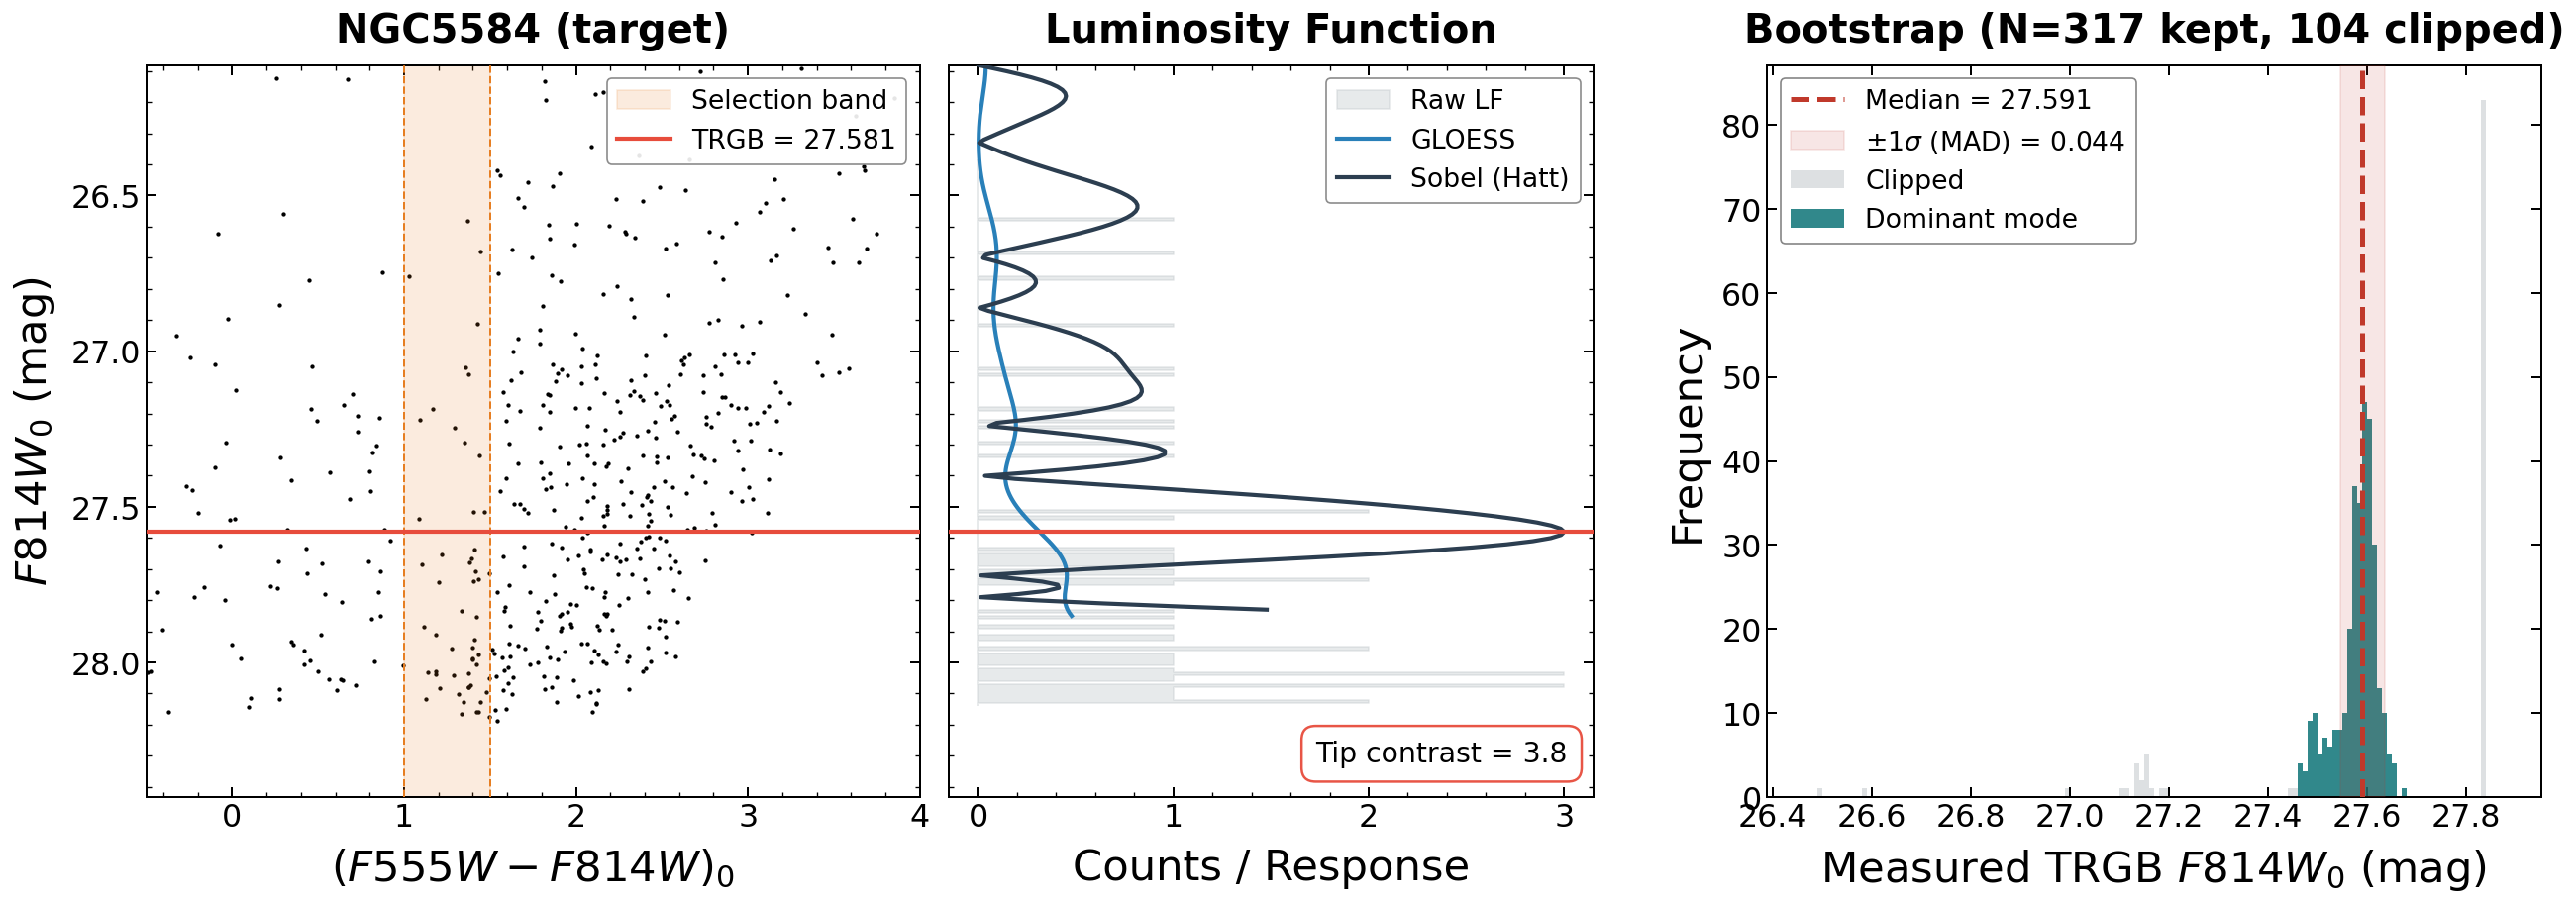


  Result stored in result_target.

  ✓ Tip contrast = 3.75 — detection is robust

  ⚠ MADORE+2009: N_faint = 40 < 400
  Stars in (TRGB, TRGB+1 mag]: 40
  Too few stars below the tip for a reliable edge detection.
  Actions: reduce scale_factor to include more halo area,
           widen color_lo, or verify the photometric depth.


In [31]:
# ============================================================
# TARGET-SPECIFIC PARAMETER OVERRIDES
# ============================================================

SELECTION_TARGET = dict(SELECTION)
SELECTION_TARGET['color_lo']   = 1.0     # increasing moves the left (blue) edge of the color window right — fewer blue stars at the tip
SELECTION_TARGET['color_hi']   = 1.5     # decreasing moves the right (red) edge left — fewer red stars at the tip; max 1.5 (Jang & Lee 2017)

SPATIAL_TARGET = dict(SPATIAL)
SPATIAL_TARGET['scale_factor'] = 1.0    # increasing enlarges the exclusion ellipse (only far-halo stars kept); decreasing includes stars closer to the disk

# --- Detect filter groups (EDD mixed-filter targets, e.g. M66, M101) ---
# When the target has both F555W and F606W EDD files, run once per filter
# group and combine via inverse-variance weighting (same as the anchor).
if PHOT_SOURCE == 'EDD':
    _tgt_all_files = find_photometry_file(target_info['name'], DATA_DIR)
    _tgt_f555 = [f for f in _tgt_all_files if _edd_blue_filter(f) == 'f555w']
    _tgt_f606 = [f for f in _tgt_all_files if _edd_blue_filter(f) == 'f606w']
    if _tgt_f555 and _tgt_f606:
        _tgt_filt_groups = [(filt, files)
                            for filt, files in [('F555W', _tgt_f555), ('F606W', _tgt_f606)] if files]
        # Per-filter color selections — adjust independently after inspecting CMDs
        SELECTION_TARGET_F606W = dict(SELECTION_TARGET)
        SELECTION_TARGET_F606W['color_hi'] = 1.5   # max (Jang & Lee 2017, F606W-F814W)
        SELECTION_TARGET_F555W = dict(SELECTION_TARGET)
        SELECTION_TARGET_F555W['color_lo'] = 1.6
        SELECTION_TARGET_F555W['color_hi'] = 2.1   # max (Jang & Lee 2017, F555W-F814W)
        print(f"Target {target_info['name']} — EDD, two filter groups")
        print(f"  F606W: {len(_tgt_f606)} file(s), color=[{SELECTION_TARGET_F606W['color_lo']}, {SELECTION_TARGET_F606W['color_hi']}]")
        print(f"  F555W: {len(_tgt_f555)} file(s), color=[{SELECTION_TARGET_F555W['color_lo']}, {SELECTION_TARGET_F555W['color_hi']}]")
    else:
        _tgt_filt_groups = [(None, None)]
        SELECTION_TARGET_F606W = SELECTION_TARGET_F555W = None
else:
    _tgt_filt_groups = [(None, None)]
    SELECTION_TARGET_F606W = SELECTION_TARGET_F555W = None

# --- Load photometry ---
# For single-filter targets (or CATS), load as before.
# Multi-filter EDD targets are loaded per-group inside the loop below.
if len(_tgt_filt_groups) == 1:
    df_target = load_photometry_df(
        target_info['name'], DATA_DIR, PHOT_SOURCE, TARGET_PHOT_FILE)

# ─────────────────────────────────────────────────────────────
# Per-filter-group pipeline (single pass for most targets;
# two passes for mixed-filter EDD targets, then weighted average)
# ─────────────────────────────────────────────────────────────
_per_filt_target = {}
fits_files_t = find_fits_file(target_info['name'], SPATIAL_TARGET['fits_dir'])
fits_file_t = fits_files_t[0] if fits_files_t else None

for _tgt_filt, _ in _tgt_filt_groups:
    _tgt_label = f' [{_tgt_filt}]' if _tgt_filt else ''
    if _tgt_filt == 'F555W':
        _sel_t = SELECTION_TARGET_F555W
    elif _tgt_filt == 'F606W':
        _sel_t = SELECTION_TARGET_F606W
    else:
        _sel_t = SELECTION_TARGET

    if len(_tgt_filt_groups) > 1:
        print()
        print('-' * 50)
        print(f'Target {target_info["name"]}{_tgt_label}')
        print('-' * 50)
        df_target = load_photometry_df(
            target_info['name'], DATA_DIR, PHOT_SOURCE, TARGET_PHOT_FILE,
            edd_filter=_tgt_filt)

    # --- Spatial clipping (MANDATORY) ---
    mask_halo_t = apply_spatial_clip(
        df_target,
        target_info,
        PHOT_SOURCE,
        scale_factor=SPATIAL_TARGET['scale_factor'],
        fits_file=fits_file_t,
        show_plot=(len(_tgt_filt_groups) == 1),   # only one spatial plot for single-filter
        img_size_factor=4.0
    )

    df_target_halo = df_target[mask_halo_t].copy()

    if len(df_target_halo) == 0:
        raise RuntimeError(
            f'Spatial clipping removed all stars for target{_tgt_label}. '
            'Adjust scale_factor.'
        )

    # --- Build CMD arrays ---
    col1_t, col2_t = get_mag_cols(df_target_halo)

    color_t = df_target_halo[col1_t].to_numpy(dtype=float) - \
              df_target_halo[col2_t].to_numpy(dtype=float)
    mag_t   = df_target_halo[col2_t].to_numpy(dtype=float)

    valid = np.isfinite(color_t) & np.isfinite(mag_t)
    color_t, mag_t = color_t[valid], mag_t[valid]

    # --- Apply extinction correction ---
    _blue_filt_t = _detect_blue_filter(col1_t) or 'f606w'
    _A_blue_t    = target_info['A_F555W'] if 'f555w' in _blue_filt_t else target_info['A_F606W']
    _A_color_t   = _A_blue_t - target_info['A_F814W']
    color_t = color_t - _A_color_t
    mag_t   = mag_t   - target_info['A_F814W']
    print(f'  Extinction correction applied: '
          f'A_F814W={target_info["A_F814W"]:.4f}, '
          f'A_color={_A_color_t:.4f} ({_blue_filt_t.upper()}−F814W)')

    # --- Magnitude range ---
    # MAG_BRIGHT_TARGET: bright limit for this galaxy's LF.
    # Set to exclude AGB stars above the TRGB (AGB sit 0–0.5 mag brighter
    # than the tip and bias the Sobel peak bright if included).
    # Set to None to use the data percentile (no bright cutoff).
    MAG_BRIGHT_TARGET = None   # NGC4526: excludes AGB shoulder above ~26.7

    mag_lo_t = MAG_BRIGHT_TARGET if MAG_BRIGHT_TARGET is not None else np.percentile(mag_t, 0.5)
    mag_hi_t = MAG_FAINT         if MAG_FAINT         is not None else np.percentile(mag_t, 99.5)
    mag_range_t = (mag_lo_t, mag_hi_t)

    # --- RGB selection ---
    selected_mag_t, mask_sel_t = select_rgb(color_t, mag_t, _sel_t)
    n_sel_t = len(selected_mag_t)

    print(f'  Selected {n_sel_t:,} RGB stars out of {len(mag_t):,} halo stars.')

    # --- Star-count diagnostic ---
    if n_sel_t < 30:
        print()
        print("=" * 65)
        print(f"  ⚠️  VERY FEW RGB STARS SELECTED{_tgt_label}: {n_sel_t} stars")
        print("=" * 65)
        print("  With color_hi ≤ 1.5 (flat-TRGB regime), fewer stars are")
        print("  expected than with a wider color cut. Consider:")
        print("    • Widening 'color_hi' slightly")
        print("    • Lowering 'color_lo' to include bluer halo stars")
        print("    • Reducing 'scale_factor' to include more halo area")
        print("    • Checking the CMD — the RGB may be at a different color")
        print()
        raise RuntimeError(
            f'Too few RGB stars after selection{_tgt_label} ({n_sel_t} < 30). '
            'Inspect the CMD and adjust the selection. '
            'With color_hi ≤ 1.5, ensure the band covers the RGB ridge.'
        )
    elif n_sel_t < 100:
        print(f'  ⚠️  Low star count ({n_sel_t}). TRGB detection may be noisy. '
              'Bootstrap uncertainty will be larger than typical.')

    # --- TRGB measurement ---
    trgb_t, smooth_lf_t, mc_t, resp_t, xs_t = measure_trgb(
        selected_mag_t,
        SMOOTHING,
        EDGE,
        mag_range=mag_range_t
    )

    tc_t = tip_contrast(selected_mag_t, trgb_t, CONTRAST_HALF_MAG)

    print(f'  TRGB (single pass) = {trgb_t:.3f} mag')
    print(f'  Tip contrast       = {tc_t:.2f}')

    # --- Bootstrap ---
    print(f'  Running bootstrap ({BOOTSTRAP["n_boot"]} iterations)...')
    t0 = time.time()

    boot_t = run_bootstrap(
        color_t,
        mag_t,
        _sel_t,
        SMOOTHING,
        EDGE,
        mag_range=mag_range_t,
        n_boot=BOOTSTRAP['n_boot'],
        n_jobs=BOOTSTRAP['n_jobs']
    )

    dt = time.time() - t0
    print(f'  Bootstrap complete in {dt:.1f}s.')

    if len(boot_t) == 0:
        raise RuntimeError(
            f'All bootstrap iterations failed{_tgt_label}. '
            'Selection or smoothing parameters are too restrictive.'
        )

    # --- Robust statistics ---
    trgb_t_robust, sigma_t, mask_keep_t = robust_bootstrap_stats(boot_t)

    print(f'  TRGB (robust) = {trgb_t_robust:.3f} ± {sigma_t:.3f} mag')

    # --- Diagnostic plot ---
    plot_trgb_diagnostic(
        color_t, mag_t, selected_mag_t, _sel_t, trgb_t,
        smooth_lf_t, mc_t, resp_t, xs_t,
        tc_t, boot_t, trgb_t_robust, sigma_t, mask_keep_t,
        galaxy_name=f'{target_info["name"]} (target){_tgt_label}',
        blue_filter=(_detect_blue_filter(col1_t) or 'f606w').upper()
    )

    _per_filt_target[_tgt_filt or 'default'] = {
        'trgb_single': trgb_t,
        'trgb_mean':   trgb_t_robust,
        'trgb_err':    sigma_t,
        'tip_contrast': tc_t,
        'boot_values': boot_t,
        'n_selected':  n_sel_t,
    }

# --- Combine filter groups (when both F555W and F606W present) ---
# --- Madore et al. (2009) N_faint criterion ---
N_FAINT_MIN = 400
if len(_tgt_filt_groups) == 2:
    _rt555 = _per_filt_target['F555W']
    _rt606 = _per_filt_target['F606W']
    _wt555 = 1 / _rt555['trgb_err']**2
    _wt606 = 1 / _rt606['trgb_err']**2
    _trgb_t_comb  = (_rt555['trgb_mean']*_wt555 + _rt606['trgb_mean']*_wt606) / (_wt555 + _wt606)
    _sigma_t_comb = 1 / np.sqrt(_wt555 + _wt606)
    print()
    print('=' * 65)
    print('Target TRGB — inverse-variance weighted combination (EDD)')
    print(f"  F555W: {_rt555['trgb_mean']:.3f} ± {_rt555['trgb_err']:.3f}")
    print(f"  F606W: {_rt606['trgb_mean']:.3f} ± {_rt606['trgb_err']:.3f}")
    print(f'  Combined:  {_trgb_t_comb:.3f} ± {_sigma_t_comb:.3f}')
    print('=' * 65)
    _trgb_t_final  = _trgb_t_comb
    _sigma_t_final = _sigma_t_comb
    _tc_t_final    = min(_rt555['tip_contrast'], _rt606['tip_contrast'])
    _boot_t_final  = np.concatenate([_rt555['boot_values'], _rt606['boot_values']])
    _n_sel_final   = _rt555['n_selected'] + _rt606['n_selected']
else:
    _r = _per_filt_target['default']
    _trgb_t_final  = _r['trgb_mean']
    _sigma_t_final = _r['trgb_err']
    _tc_t_final    = _r['tip_contrast']
    _boot_t_final  = _r['boot_values']
    _n_sel_final   = _r['n_selected']
    trgb_t         = _r['trgb_single']

n_faint_t = int(np.sum(
    (selected_mag_t > _trgb_t_final) &
    (selected_mag_t <= _trgb_t_final + 1.0)))

result_target = {
    'trgb_single': trgb_t,
    'trgb_mean': _trgb_t_final,
    'trgb_err': _sigma_t_final,
    'tip_contrast': _tc_t_final,
    'boot_values': _boot_t_final,
    'n_selected': _n_sel_final,
    'n_faint': n_faint_t,
}

print('\n  Result stored in result_target.')

# --- Tip contrast diagnostic ---
print()
print("=" * 65)

if _tc_t_final <= 2.0:
    print(f"  ✖ VERY LOW TIP CONTRAST ({_tc_t_final:.2f}) — detection unreliable")
    print("  Action: Increase tau and/or tighten RGB selection.")
    USE_TARGET_RESULT = False

elif _tc_t_final <= 3.0:
    print(f"  ⚠ LOW TIP CONTRAST ({_tc_t_final:.2f}) — inspect diagnostic plot carefully")
    print("  Action: Verify Sobel peak and bootstrap stability before trusting.")
    USE_TARGET_RESULT = None

else:
    print(f"  ✓ Tip contrast = {_tc_t_final:.2f} — detection is robust")
    USE_TARGET_RESULT = True

print("=" * 65)

# --- Madore et al. (2009) sample-size criterion ---
print()
print('=' * 65)
if n_faint_t < N_FAINT_MIN:
    print(f'  ⚠ MADORE+2009: N_faint = {n_faint_t} < {N_FAINT_MIN}')
    print(f'  Stars in (TRGB, TRGB+1 mag]: {n_faint_t}')
    print( '  Too few stars below the tip for a reliable edge detection.')
    print( '  Actions: reduce scale_factor to include more halo area,')
    print( '           widen color_lo, or verify the photometric depth.')
    N_FAINT_OK = False
else:
    print(f'  ✓ Madore+2009: N_faint = {n_faint_t} ≥ {N_FAINT_MIN} — sufficient statistics')
    N_FAINT_OK = True
print('=' * 65)

### ✅ Check your results before proceeding

| Diagnostic | Healthy value | Action if unhealthy |
|------------|--------------|---------------------|
| Tip contrast | > 3 | Tighten color limits; increase `tau`; try different `scale_factor`; Ask: is the data quality sufficient? |
| Bootstrap shape | Unimodal, roughly Gaussian | Bimodal → increase `tau` or refine selection band |
| Bootstrap σ | < 0.10 mag | Large σ → check star count; try wider selection or different spatial clip |
| N_faint (Madore+2009) | ≥ 400 stars within 1 mag below TRGB | Reduce `scale_factor`; widen `color_lo`; verify photometric depth |

> ✅ If both galaxies give clean detections, proceed to Section 8.


---

## 8. Distance Calculation

**What:** Combine the anchor and target TRGB measurements with the known maser distance to compute the distance to the target galaxy.

**Why:** This is the payoff — the entire notebook has been building toward this number. The calibration chain (derived in the overview) is:

$$M_{\text{TRGB}} = m_{\text{TRGB, anchor}}^{\text{corr}} - \mu_{\text{N4258}}$$

$$\mu_{\text{target}} = m_{\text{TRGB, target}}^{\text{corr}} - M_{\text{TRGB}}$$

where $m^{\text{corr}} = m - A_{\text{F814W}}$ is the extinction-corrected apparent TRGB magnitude. Combining:

$$\boxed{\mu_{\text{target}} = \left(m_{\text{TRGB, target}} - A_{\text{target}}\right) - \left(m_{\text{TRGB, anchor}} - A_{\text{anchor}}\right) + \mu_{\text{N4258}}}$$

The distance in Mpc follows from the distance modulus definition:

$$d = 10^{(\mu - 25)/5} \;\text{Mpc}$$

(where the factor of 25 converts from the standard 10 pc reference to Mpc: $5\log_{10}(10^6/10) = 25$). The uncertainty on $d$ is obtained by first-order error propagation:

$$\sigma_d \approx d \cdot \frac{\ln 10}{5} \cdot \sigma_\mu$$

> 📌 **Approximation note:** This is a symmetric, first-order approximation valid when $\sigma_\mu \ll \mu$. Because $d \propto 10^{\mu/5}$, the true $+\sigma_d$ and $-\sigma_d$ are slightly asymmetric: a fixed $+\sigma_\mu$ maps to a *larger* $+\sigma_d$ than the corresponding $-\sigma_d$. For typical bootstrap uncertainties ($\sigma_\mu \sim 0.05$–$0.15$ mag), the asymmetry is $\lesssim 1$–3\% of $d$, well below other systematics. For publication-quality reporting, also give the exact asymmetric bounds:
>
> $$d_{+} = 10^{(\mu+\sigma_\mu-25)/5}, \quad d_{-} = 10^{(\mu-\sigma_\mu-25)/5}.$$

### Error budget

Each quantity in the calibration chain has an independent uncertainty. Since the operations are all additions/subtractions, the total uncertainty is a quadrature sum:

$$
\sigma_\mu =
\sqrt{
\sigma_{\text{boot,anchor}}^2 +
\sigma_{\text{ext,anchor}}^2 +
\sigma_{\text{maser}}^2 +
\sigma_{\text{boot,target}}^2 +
\sigma_{\text{ext,target}}^2
}
$$

The extinction uncertainties are estimated as 20% of $A_{\text{F814W}}$ (reflecting the ≈20% systematic uncertainty in the Schlafly & Finkbeiner 2011 dust maps) plus a 0.005 mag floor (to prevent the uncertainty from being unrealistically small for low-extinction sightlines).

If you have independent extinction estimates (e.g., from stellar colors or a different dust map), you can override the values below.

The printout below itemizes every contribution so you can see what dominates your error budget.

**In practice:**

| Term | Typical role |
|------|--------------|
| Bootstrap | Dominates the **random** (statistical) error |
| Extinction | A source of **systematic** uncertainty |
| Maser distance | Fixed contribution of 0.032 mag to all measurements |

In [32]:
# ── Guard: ensure Section 6 and 7 have been run ─────────────────────────
_anchor_ok  = globals().get('USE_ANCHOR_RESULT', True)
_target_ok  = globals().get('USE_TARGET_RESULT', True)
_nfaint_ok  = globals().get('N_FAINT_OK', True)

if ('result_anchor' not in globals()) or ('result_target' not in globals()):
    raise RuntimeError(
        'Missing result_anchor or result_target. Run Sections 6 and 7 first.'
    )

# ── Tip-contrast checks ──────────────────────────────────────────────────
if _anchor_ok is None:
    raise RuntimeError(
        'Anchor (NGC4258) tip contrast was ≤ 3.\n'
        'Inspect the Section 6 diagnostic plot and re-run.'
    )

if _anchor_ok is False:
    raise RuntimeError(
        'Anchor tip contrast ≤ 2 — detection unreliable. Re-run Section 6.'
    )

if _target_ok is None:
    raise RuntimeError(
        f"Target ({target_info['name']}) tip contrast was ≤ 3.\n"
        'Inspect the Section 7 diagnostic plot and re-run.'
    )

if _target_ok is False:
    raise RuntimeError(
        f"Target ({target_info['name']}) tip contrast ≤ 2 — detection unreliable.\n"
        'Re-run Section 7 with increased tau or tighter RGB selection.'
    )

# ── Madore et al. (2009) sample-size check ───────────────────────────────
if _nfaint_ok is False:
    _nf = result_target.get('n_faint', '?')
    raise RuntimeError(
        f"Target ({target_info['name']}) failed the Madore et al. (2009) "
        f"sample-size criterion: N_faint = {_nf} < 400.\n"
        'Stars within 1 mag below the TRGB are insufficient for a reliable '
        'edge detection.\n'
        'Actions: reduce scale_factor, widen color_lo, or verify '
        'photometric depth (Section 7).'
    )

# ============================================================
# DISTANCE CALCULATION WITH FULL ERROR BUDGET
# ============================================================

# --- Extinction corrections ---
A_anchor = anchor_info['A_F814W']
A_anchor_err = 0.2 * A_anchor + 0.005

A_target = target_info['A_F814W']
A_target_err = 0.2 * A_target + 0.005

print(f'Extinction (F814W):')
print(f'  {anchor_info["name"]}: {A_anchor:.4f} ± {A_anchor_err:.4f}')
print(f'  {target_info["name"]}: {A_target:.4f} ± {A_target_err:.4f}\n')

# --- Step 1: TRGB magnitudes (already extinction-corrected in Sections 6 & 7) ---
m_corr_anchor     = result_anchor['trgb_mean']
m_corr_anchor_err = result_anchor['trgb_err']
m_corr_target     = result_target['trgb_mean']
m_corr_target_err = result_target['trgb_err']

# --- Step 2: absolute TRGB calibration ---
M_TRGB = m_corr_anchor - MU_N4258
M_TRGB_err = np.sqrt(m_corr_anchor_err**2 + MU_N4258_ERR**2)

# --- Step 3: distance modulus ---
mu_target = m_corr_target - M_TRGB
mu_target_err = np.sqrt(m_corr_target_err**2 + M_TRGB_err**2)

# --- Step 4: distance ---
d_Mpc = 10**((mu_target - 25) / 5)
d_Mpc_err = d_Mpc * (np.log(10) / 5) * mu_target_err

# --- Output ---
print("=" * 60)
print(f"Distance to {target_info['name']}")
print("=" * 60)

print("\nTRGB measurements:")
print(f"  {anchor_info['name']}: {result_anchor['trgb_mean']:.3f} ± {result_anchor['trgb_err']:.3f}")
print(f"  {target_info['name']}: {result_target['trgb_mean']:.3f} ± {result_target['trgb_err']:.3f}")

print("\nExtinction:")
print(f"  Anchor: {A_anchor:.4f} ± {A_anchor_err:.4f}")
print(f"  Target: {A_target:.4f} ± {A_target_err:.4f}")

print("\nCalibration:")
print(f"  μ(N4258) = {MU_N4258:.3f} ± {MU_N4258_ERR:.3f}")
print(f"  M_TRGB   = {M_TRGB:.3f} ± {M_TRGB_err:.3f}")

print("\nResult:")
print(f"  μ(target) = {mu_target:.3f} ± {mu_target_err:.3f}")
print(f"  d = {d_Mpc:.2f} ± {d_Mpc_err:.2f} Mpc")

# --- Error budget (itemized) ---
errors = {
    'bootstrap_anchor': result_anchor['trgb_err'],
    'extinction_anchor': A_anchor_err,
    'maser': MU_N4258_ERR,
    'bootstrap_target': result_target['trgb_err'],
    'extinction_target': A_target_err,
}

print("\nError budget (contributions to σ_μ):")
print(f"  {'Source':<24s}  {'σ (mag)':>8s}  {'% of total':>10s}")
print("  " + "-" * 48)
for src, val in errors.items():
    frac = 100 * val**2 / mu_target_err**2
    print(f"  {src:<24s}  {val:8.4f}  {frac:10.1f}%")
print("  " + "-" * 48)
print(f"  {'total (quadrature)':<24s}  {mu_target_err:8.4f}")

dominant = max(errors, key=errors.get)
print(f"\nDominant error source: {dominant}")

RuntimeError: Target (NGC5584) failed the Madore et al. (2009) sample-size criterion: N_faint = 40 < 400.
Stars within 1 mag below the TRGB are insufficient for a reliable edge detection.
Actions: reduce scale_factor, widen color_lo, or verify photometric depth (Section 7).

---

## 9. Export Your Final Result

Run the cell below **only when you are satisfied with your measurement**.
It saves your distance modulus to a shared CSV file that the $H_0$ notebook reads.
Re-running will update your entry — it will not create a duplicate.

In [33]:
# ============================================================
# Run this cell only when you are happy with your measurement.
# It saves (or updates) your result in the shared results file.
# ============================================================
import os
import pandas as pd

RESULTS_CSV = os.path.join('..', 'trgb_results.csv')

# Convert galaxy name to the key format used by mu_to_H0
# e.g. 'NGC1365' -> 'n1365',  'M101' -> 'm101'
host_key = TARGET_GALAXY.lower().replace('ngc', 'n').replace('ugc', 'u')

# Load existing results or create a new table
if os.path.exists(RESULTS_CSV):
    df = pd.read_csv(RESULTS_CSV)
else:
    df = pd.DataFrame(columns=['host', 'mu', 'sigma_mu', 'galaxy_name',
                                'trgb_app', 'tip_contrast', 'n_stars', 'n_faint',
                                'phot_source'])

# Build the new row — include quality diagnostics so the H0 notebook
# can apply its tip_contrast quality filter regardless of whether results
# were exported here or via batch mode.
new_row = {
    'host':         host_key,
    'mu':           round(mu_target, 4),
    'sigma_mu':     round(mu_target_err, 4),
    'galaxy_name':  TARGET_GALAXY,
    'trgb_app':     round(result_target['trgb_mean'], 3),
    'tip_contrast': round(result_target['tip_contrast'], 2),
    'n_stars':      result_target['n_selected'],
    'n_faint':      result_target.get('n_faint', -1),
    'phot_source':  PHOT_SOURCE,
}

# Upsert: update all columns if row already present, otherwise append
_cols = list(new_row.keys())
if host_key in df['host'].values:
    for col in _cols:
        if col not in df.columns:
            df[col] = None
        df.loc[df['host'] == host_key, col] = new_row[col]
    print(f'Updated existing entry for {TARGET_GALAXY}.')
else:
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    print(f'Added new entry for {TARGET_GALAXY}.')

df.to_csv(RESULTS_CSV, index=False)
print(f'\nSaved to: {os.path.abspath(RESULTS_CSV)}')
print(f'\nAll measurements so far:')
print(df.to_string(index=False))


NameError: name 'mu_target' is not defined

---

## 10. Optional batch Mode — Measure All Galaxies at Once

This section loops through every host galaxy in the database, measures its TRGB
distance with the parameters set in **Section 4**, and writes all results to
`trgb_results.csv` in one pass. This is provided if you want to measure all the TRGBs in each galaxy with the same measurement parameters. 

### ⚠️ Run this only after visually inspecting each CMD and solution to check and ensure that the measurement is reasonable and accurate. In some cases, the TRGB measurement algorithm will run, but the CMD may be too sparse or unreliable (e.g. NGC 5584). Be sure to check!

**Prerequisites:** Run Sections 0–4 (setup, galaxy database, algorithm functions,
and measurement parameters) before running the cells below.

**Key parameters (set in the configuration cell below):**

| Parameter | Description |
|-----------|-------------|
| `BATCH_PHOT_SOURCE` | `'EDD'` or `'CATS'` — photometry source applied to every galaxy |
| `BATCH_GALAXIES` | `None` (all host galaxies) or a list e.g. `['NGC1365', 'M101']` |
| `BATCH_PHOT_OVERRIDES` | Per-galaxy file overrides (EDD only) |
| `BATCH_SUPPRESS_PLOTS` | `True` to skip diagnostic plots (faster); `False` to show them |

Smoothing (`SMOOTHING`), spatial clipping (`SPATIAL`), colour selection
(`SELECTION`), edge detection (`EDGE`), and bootstrap (`BOOTSTRAP`) parameters
are inherited from Section 4.  The anchor uses `tau = 0.10` (matching Section 6a);
targets use the `tau` value in `SMOOTHING`.

In [34]:
# ============================================================
# BATCH HELPER — full pipeline for one galaxy
# No need to edit this cell; just run it.
# ============================================================

def _run_trgb_pipeline(galaxy_info, data_dir, phot_source, override_file,
                       selection, spatial_params, smoothing, edge,
                       bootstrap_params, mag_bright=None, mag_faint=None,
                       show_plots=False, cats_filter=None, edd_filter=None):
    """Run the full TRGB pipeline for a single galaxy.

    Returns a result dict in the same format as result_anchor / result_target
    (keys: trgb_single, trgb_mean, trgb_err, tip_contrast, boot_values, n_selected).
    """
    df = load_photometry_df(
        galaxy_info['name'], data_dir, phot_source, override_file,
        cats_filter=cats_filter, edd_filter=edd_filter)

    fits_files = find_fits_file(galaxy_info['name'], spatial_params['fits_dir'])
    fits_file  = fits_files[0] if fits_files else None

    mask_halo = apply_spatial_clip(
        df, galaxy_info, phot_source,
        scale_factor=spatial_params['scale_factor'],
        fits_file=fits_file,
        show_plot=show_plots)

    df_halo = df[mask_halo].copy()
    if len(df_halo) == 0:
        raise RuntimeError('Spatial clipping removed all stars.')

    col1, col2 = get_mag_cols(df_halo)
    color = df_halo[col1].to_numpy(dtype=float) - df_halo[col2].to_numpy(dtype=float)
    mag   = df_halo[col2].to_numpy(dtype=float)
    valid = np.isfinite(color) & np.isfinite(mag)
    color, mag = color[valid], mag[valid]

    blue_filt = _detect_blue_filter(col1) or 'f606w'
    A_blue    = galaxy_info['A_F555W'] if 'f555w' in blue_filt else galaxy_info['A_F606W']
    A_color   = A_blue - galaxy_info['A_F814W']
    color = color - A_color
    mag   = mag   - galaxy_info['A_F814W']

    mag_lo    = mag_bright if mag_bright is not None else np.percentile(mag, 0.5)
    mag_hi    = mag_faint  if mag_faint  is not None else np.percentile(mag, 99.5)
    mag_range = (mag_lo, mag_hi)

    selected_mag, _ = select_rgb(color, mag, selection)
    if len(selected_mag) < 30:
        raise RuntimeError(f'Too few RGB stars ({len(selected_mag)} < 30).')

    trgb, smooth_lf, mc, resp, xs = measure_trgb(
        selected_mag, smoothing, edge, mag_range=mag_range)
    tc = tip_contrast(selected_mag, trgb)

    boot = run_bootstrap(
        color, mag, selection, smoothing, edge,
        mag_range=mag_range,
        n_boot=bootstrap_params['n_boot'],
        n_jobs=bootstrap_params['n_jobs'])

    if len(boot) == 0:
        raise RuntimeError('All bootstrap iterations failed.')

    trgb_robust, sigma, mask_keep = robust_bootstrap_stats(boot)

    if show_plots:
        plot_trgb_diagnostic(
            color, mag, selected_mag, selection, trgb,
            smooth_lf, mc, resp, xs,
            tc, boot, trgb_robust, sigma, mask_keep,
            galaxy_name=galaxy_info['name'],
            blue_filter=blue_filt.upper())
    else:
        plt.close('all')

    n_faint = int(np.sum(
        (selected_mag > trgb_robust) &
        (selected_mag <= trgb_robust + 1.0)))

    return {
        'trgb_single':  trgb,
        'trgb_mean':    trgb_robust,
        'trgb_err':     sigma,
        'tip_contrast': tc,
        'boot_values':  boot,
        'n_selected':   len(selected_mag),
        'n_faint':      n_faint,
    }

print('_run_trgb_pipeline() defined.')

_run_trgb_pipeline() defined.


In [35]:
# ============================================================
# BATCH CONFIGURATION — edit this cell, then run it and the
# execution cell below.
# ============================================================

# --- Photometry source ---
# Must be the same for anchor and all targets.
BATCH_PHOT_SOURCE = 'EDD'   # 'EDD' or 'CATS'

# --- Galaxy subset ---
# None  → process every host galaxy in GALAXY_DB
# list  → process only the named galaxies
BATCH_GALAXIES = None   # e.g. ['NGC1365', 'M101', 'NGC1448']

# --- Per-galaxy photometry file overrides (EDD only) ---
# Use when multiple EDD files exist for a galaxy and you want a specific one.
# Format: {'GalaxyName': 'exact_filename.csv'}
BATCH_PHOT_OVERRIDES = {}   # e.g. {'NGC1448': 'NGC1448_hst_acs_v2.csv'}

# --- Suppress diagnostic plots (recommended for batch runs) ---
BATCH_SUPPRESS_PLOTS = True   # False → show CMD + LF plots for every galaxy

# --- Anchor smoothing ---
# Uses tau = 0.10 to match the Section 6a default.
# Targets use the tau currently set in SMOOTHING (Section 4, default 0.05).
BATCH_ANCHOR_SMOOTHING = dict(SMOOTHING)
BATCH_ANCHOR_SMOOTHING['tau'] = 0.10

# --- Anchor color selection (per filter group, CATS and mixed-filter EDD) ---
# NGC 4258 spans F555W and F606W fields in both CATS and EDD.
# Each group needs its own color range (Jang & Lee 2017 flat-TRGB limits).
BATCH_ANCHOR_SELECTION_F606W = {'color_lo': 1.0, 'color_hi': 1.5}  # F606W-F814W limit: 1.5
BATCH_ANCHOR_SELECTION_F555W = {'color_lo': 1.6, 'color_hi': 2.1}  # F555W-F814W limit: 2.1

# --- Target color selection for mixed-filter EDD targets (e.g. M66, M101) ---
# Used only when the target galaxy has both F555W and F606W EDD files.
BATCH_TARGET_SELECTION_F606W = {'color_lo': 1.0, 'color_hi': 1.5}  # F606W-F814W limit: 1.5
BATCH_TARGET_SELECTION_F555W = {'color_lo': 1.6, 'color_hi': 2.1}  # F555W-F814W limit: 2.1

# ── Summary ─────────────────────────────────────────────────
_host_count = sum(1 for v in GALAXY_DB.values() if v['role'] == 'host')
_run_count  = len(BATCH_GALAXIES) if BATCH_GALAXIES else _host_count
print('Batch configuration')
print(f'  Photometry source  : {BATCH_PHOT_SOURCE}')
print(f'  Galaxies to run    : {_run_count} '
      f'({"custom list" if BATCH_GALAXIES else "all host galaxies"})')
print(f'  Anchor tau         : {BATCH_ANCHOR_SMOOTHING["tau"]}')
print(f'  Target tau         : {SMOOTHING["tau"]}')
print(f'  Bootstrap iters    : {BOOTSTRAP["n_boot"]}')
print(f'  Suppress plots     : {BATCH_SUPPRESS_PLOTS}')
if BATCH_PHOT_OVERRIDES:
    print(f'  File overrides     : {BATCH_PHOT_OVERRIDES}')

Batch configuration
  Photometry source  : EDD
  Galaxies to run    : 17 (all host galaxies)
  Anchor tau         : 0.1
  Target tau         : 0.1
  Bootstrap iters    : 500
  Suppress plots     : True


In [36]:
# ============================================================
# BATCH EXECUTION — run after the configuration cell above
# ============================================================
import os, time
import pandas as pd

if BATCH_PHOT_SOURCE == 'EDD':
    _batch_data_dir = '../photometry/EDD'
elif BATCH_PHOT_SOURCE == 'CATS':
    _batch_data_dir = '../photometry/CATS'
else:
    raise ValueError(f"BATCH_PHOT_SOURCE must be 'EDD' or 'CATS'")

# ── Step 1: measure anchor (NGC 4258) once ──────────────────
print('=' * 65)
print('BATCH — Step 1: anchor NGC 4258')
print('=' * 65)

_batch_anchor_info   = get_galaxy_info('NGC4258')
_anchor_phot_file    = globals().get('ANCHOR_PHOT_FILE', None)

# NGC 4258 may span two filter groups (CATS: F555W fields 1-4 / F606W fields
# 5-7; EDD: NGC4258_9477 F555W + NGC4258_16198 F606W). Run each group
# separately and combine via inverse-variance weighting.
if BATCH_PHOT_SOURCE == 'CATS':
    _all_anc_b = find_photometry_file(_batch_anchor_info['name'], _batch_data_dir)
    _f555_b = [f for f in _all_anc_b
               if any(k in os.path.basename(f) for k in CATS_NGC4258_F555W_FIELDS)]
    _f606_b = [f for f in _all_anc_b if f not in _f555_b]
    _batch_filt_groups = [(filt, sel, files)
                          for filt, sel, files in [
                              ('F555W', BATCH_ANCHOR_SELECTION_F555W, _f555_b),
                              ('F606W', BATCH_ANCHOR_SELECTION_F606W, _f606_b),
                          ] if files]
elif BATCH_PHOT_SOURCE == 'EDD':
    _all_anc_b = find_photometry_file(_batch_anchor_info['name'], _batch_data_dir)
    _f555_b = [f for f in _all_anc_b if _edd_blue_filter(f) == 'f555w']
    _f606_b = [f for f in _all_anc_b if _edd_blue_filter(f) == 'f606w']
    if _f555_b and _f606_b:
        _batch_filt_groups = [(filt, sel, files)
                              for filt, sel, files in [
                                  ('F555W', BATCH_ANCHOR_SELECTION_F555W, _f555_b),
                                  ('F606W', BATCH_ANCHOR_SELECTION_F606W, _f606_b),
                              ] if files]
    else:
        _batch_filt_groups = [(None, SELECTION, [None])]
else:
    _batch_filt_groups = [(None, SELECTION, [None])]

_batch_per_filt = {}
try:
    for _bf, _bsel, _ in _batch_filt_groups:
        _label_b = f' [{_bf}]' if _bf else ''
        _t0 = time.time()
        _res = _run_trgb_pipeline(
            _batch_anchor_info, _batch_data_dir, BATCH_PHOT_SOURCE,
            _anchor_phot_file,
            _bsel, SPATIAL, BATCH_ANCHOR_SMOOTHING, EDGE, BOOTSTRAP,
            show_plots=not BATCH_SUPPRESS_PLOTS,
            cats_filter=_bf if BATCH_PHOT_SOURCE == 'CATS' else None,
            edd_filter=_bf if BATCH_PHOT_SOURCE == 'EDD' else None)
        _dt = time.time() - _t0
        print(f'  NGC4258{_label_b}: TRGB = {_res["trgb_mean"]:.3f} '
              f'± {_res["trgb_err"]:.3f}  '
              f'(contrast = {_res["tip_contrast"]:.1f}, {_dt:.0f}s)')
        _batch_per_filt[_bf or 'default'] = _res

    if len(_batch_filt_groups) == 2:
        _r555b = _batch_per_filt['F555W']
        _r606b = _batch_per_filt['F606W']
        _w555b = 1 / _r555b['trgb_err']**2
        _w606b = 1 / _r606b['trgb_err']**2
        _trgb_cb  = (_r555b['trgb_mean']*_w555b + _r606b['trgb_mean']*_w606b) / (_w555b + _w606b)
        _sigma_cb = 1 / np.sqrt(_w555b + _w606b)
        print(f'  Combined (inv-var): {_trgb_cb:.3f} ± {_sigma_cb:.3f}')
        _batch_anchor_result = {'trgb_mean': _trgb_cb, 'trgb_err': _sigma_cb}
    else:
        _batch_anchor_result = _batch_per_filt['default']

    _batch_M_TRGB     = _batch_anchor_result['trgb_mean'] - MU_N4258
    _batch_M_TRGB_err = np.sqrt(_batch_anchor_result['trgb_err']**2 + MU_N4258_ERR**2)
    print(f'  M_TRGB = {_batch_M_TRGB:.3f} ± {_batch_M_TRGB_err:.3f}')
except Exception as _e:
    raise RuntimeError(f'Anchor measurement failed — cannot continue.\n{_e}') from _e

# ── Step 2: resolve target list ──────────────────────────────
_all_hosts   = [k for k, v in GALAXY_DB.items() if v['role'] == 'host']
_galaxies    = list(BATCH_GALAXIES) if BATCH_GALAXIES else list(_all_hosts)
_galaxies    = [g for g in _galaxies if g in GALAXY_DB and g != 'NGC4258']

print(f'\n{"=" * 65}')
print(f'BATCH — Step 2: {len(_galaxies)} target galaxies')
print(f'{"=" * 65}\n')

# ── Step 3: loop over targets ────────────────────────────────
_batch_records = []

for _gal in _galaxies:
    print(f'  {_gal:<12}', end='  ', flush=True)
    _t0 = time.time()
    try:
        _tgt_info   = get_galaxy_info(_gal)
        _override   = BATCH_PHOT_OVERRIDES.get(_gal)

        # Detect mixed-filter EDD targets (e.g. M66, M101)
        if BATCH_PHOT_SOURCE == 'EDD':
            _gal_files = find_photometry_file(_tgt_info['name'], _batch_data_dir)
            _gf555 = [f for f in _gal_files if _edd_blue_filter(f) == 'f555w']
            _gf606 = [f for f in _gal_files if _edd_blue_filter(f) == 'f606w']
            _tgt_filt_groups = (
                [('F555W', BATCH_TARGET_SELECTION_F555W),
                 ('F606W', BATCH_TARGET_SELECTION_F606W)]
                if (_gf555 and _gf606) else [(None, SELECTION)]
            )
        else:
            _tgt_filt_groups = [(None, SELECTION)]

        if len(_tgt_filt_groups) == 1:
            _tgt_result = _run_trgb_pipeline(
                _tgt_info, _batch_data_dir, BATCH_PHOT_SOURCE, _override,
                _tgt_filt_groups[0][1], SPATIAL, SMOOTHING, EDGE, BOOTSTRAP,
                show_plots=not BATCH_SUPPRESS_PLOTS)
        else:
            _per_gal_filt = {}
            for _gfilt, _gsel in _tgt_filt_groups:
                _r = _run_trgb_pipeline(
                    _tgt_info, _batch_data_dir, BATCH_PHOT_SOURCE, _override,
                    _gsel, SPATIAL, SMOOTHING, EDGE, BOOTSTRAP,
                    show_plots=not BATCH_SUPPRESS_PLOTS,
                    edd_filter=_gfilt)
                _per_gal_filt[_gfilt] = _r
            _rg555 = _per_gal_filt['F555W']
            _rg606 = _per_gal_filt['F606W']
            _wg555 = 1 / _rg555['trgb_err']**2
            _wg606 = 1 / _rg606['trgb_err']**2
            _trgb_g  = (_rg555['trgb_mean']*_wg555 + _rg606['trgb_mean']*_wg606) / (_wg555 + _wg606)
            _sigma_g = 1 / np.sqrt(_wg555 + _wg606)
            _tgt_result = {
                'trgb_single':  _trgb_g,
                'trgb_mean':    _trgb_g,
                'trgb_err':     _sigma_g,
                'tip_contrast': min(_rg555['tip_contrast'], _rg606['tip_contrast']),
                'boot_values':  np.concatenate([_rg555['boot_values'], _rg606['boot_values']]),
                'n_selected':   _rg555['n_selected'] + _rg606['n_selected'],
                'n_faint':      _rg555.get('n_faint', 0) + _rg606.get('n_faint', 0),
            }

        _mu     = _tgt_result['trgb_mean'] - _batch_M_TRGB
        _mu_err = np.sqrt(_tgt_result['trgb_err']**2 + _batch_M_TRGB_err**2)
        _d_mpc  = 10**((_mu - 25) / 5)
        _hkey   = _gal.lower().replace('ngc', 'n').replace('ugc', 'u')

        _batch_records.append({
            'host':         _hkey,
            'galaxy_name':  _gal,
            'mu':           round(_mu, 4),
            'sigma_mu':     round(_mu_err, 4),
            'trgb_app':     round(_tgt_result['trgb_mean'], 3),
            'tip_contrast': round(_tgt_result['tip_contrast'], 2),
            'n_stars':      _tgt_result['n_selected'],
            'n_faint':      _tgt_result.get('n_faint', -1),
            'phot_source':  BATCH_PHOT_SOURCE,
            'status':       'ok',
        })
        print(f'μ = {_mu:.3f} ± {_mu_err:.3f}   '
              f'd = {_d_mpc:.1f} Mpc   '
              f'tc = {_tgt_result["tip_contrast"]:.1f}   '
              f'({time.time() - _t0:.0f}s)')

    except FileNotFoundError:
        print('SKIPPED (no photometry file found)')
        _batch_records.append({
            'host': _gal.lower().replace('ngc', 'n').replace('ugc', 'u'),
            'galaxy_name': _gal, 'phot_source': BATCH_PHOT_SOURCE,
            'status': 'no photometry file'})
    except Exception as _e:
        print(f'FAILED: {_e}')
        _batch_records.append({
            'host': _gal.lower().replace('ngc', 'n').replace('ugc', 'u'),
            'galaxy_name': _gal, 'phot_source': BATCH_PHOT_SOURCE,
            'status': f'FAILED: {_e}'})

# ── Step 4: upsert results into CSV ─────────────────────────
RESULTS_CSV = os.path.join('..', 'trgb_results.csv')
_ok = [r for r in _batch_records if r.get('status') == 'ok']

if _ok:
    _new_df = pd.DataFrame(_ok)
    if os.path.exists(RESULTS_CSV):
        _existing = pd.read_csv(RESULTS_CSV)
        for _, _row in _new_df.iterrows():
            if _row['host'] in _existing['host'].values:
                for _col in _new_df.columns:
                    if _col not in _existing.columns:
                        _existing[_col] = None
                    _existing.loc[_existing['host'] == _row['host'], _col] = _row[_col]
            else:
                _existing = pd.concat([_existing, _row.to_frame().T], ignore_index=True)
        _existing.to_csv(RESULTS_CSV, index=False)
    else:
        _new_df.to_csv(RESULTS_CSV, index=False)
    print(f'\nSaved {len(_ok)} result(s) → {os.path.abspath(RESULTS_CSV)}')

# ── Step 5: summary table ────────────────────────────────────
_n_ok   = len(_ok)
_n_skip = sum(1 for r in _batch_records if 'no photometry' in r.get('status', ''))
_n_fail = len(_batch_records) - _n_ok - _n_skip

print(f'\n{"=" * 72}')
print(f'BATCH SUMMARY  |  source: {BATCH_PHOT_SOURCE}  |  '
      f'ok: {_n_ok}  skipped: {_n_skip}  failed: {_n_fail}')
print(f'{"=" * 72}')
print(f'  {"Galaxy":<12}  {"μ":>7}  {"σ_μ":>6}  {"d (Mpc)":>9}  '
      f'{"contrast":>8}  {"N_RGB":>6}  {"N_faint":>7}  status')
print(f'  {"-" * 76}')
for _r in _batch_records:
    _gname = _r.get('galaxy_name', _r.get('host', '?'))
    if _r.get('status') == 'ok':
        _d = 10**((_r['mu'] - 25) / 5)
        _nf = _r.get('n_faint', -1)
        _nf_flag = '' if _nf >= 400 else ' ⚠'
        print(f'  {_gname:<12}  {_r["mu"]:7.3f}  {_r["sigma_mu"]:6.3f}  '
              f'{_d:9.2f}  {_r["tip_contrast"]:8.2f}  {_r["n_stars"]:6d}  '
              f'{_nf:7d}{_nf_flag}')
    else:
        print(f'  {_gname:<12}  {"—":>7}  {"—":>6}  {"—":>9}  '
              f'{"—":>8}  {"—":>6}  {"—":>7}  {_r["status"]}')
print(f'{"=" * 72}')

BATCH — Step 1: anchor NGC 4258
  ../photometry/EDD/NGC4258_16198.csv
  ../photometry/EDD/NGC4258_9477.csv
  ../photometry/EDD/NGC4258_16198.csv
  ../photometry/EDD/NGC4258_9477.csv
  EDD [F555W]: 1 file(s):
    NGC4258_9477.csv
  Blue filter: F555W − F814W  (color limit: 2.1 mag)
  48,277 sources loaded.
  Spatial clip [sky (RA/DEC)]: scale=1.0× D25, R25=558"
  Kept 12652 halo stars, clipped 35625 inner stars (26% kept)
  Filter detected: F555W − F814W  →  flat-TRGB color limit = 2.1 mag (Jang & Lee 2017)
  NGC4258 [F555W]: TRGB = 25.340 ± 0.044  (contrast = 7.1, 0s)
  ../photometry/EDD/NGC4258_16198.csv
  ../photometry/EDD/NGC4258_9477.csv
  EDD [F606W]: 1 file(s):
    NGC4258_16198.csv
  Blue filter: F606W − F814W  (color limit: 1.5 mag)
  23,410 sources loaded.
  Spatial clip [sky (RA/DEC)]: scale=1.0× D25, R25=558"
  Kept 20773 halo stars, clipped 2637 inner stars (89% kept)
  Filter detected: F606W − F814W  →  flat-TRGB color limit = 1.5 mag (Jang & Lee 2017)
  NGC4258 [F606W]: T

/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


μ = 30.482 ± 0.068   d = 12.5 Mpc   tc = 4.3   (1s)
  M101          Warning: multiple photometry files found for M101:
  ../photometry/EDD/M101_13691.csv
  ../photometry/EDD/M101_9492.csv
  ../photometry/EDD/M101_13691.csv
  ../photometry/EDD/M101_9492.csv
  EDD [F555W]: 1 file(s):
    M101_9492.csv
  Blue filter: F555W − F814W  (color limit: 2.1 mag)
  30,474 sources loaded.
  Spatial clip [sky (RA/DEC)]: scale=1.0× D25, R25=840"
  Kept 0 halo stars, clipped 30474 inner stars (0% kept)
FAILED: Spatial clipping removed all stars.
  M66           Warning: multiple photometry files found for M66:
  ../photometry/EDD/M66_10433.csv
  ../photometry/EDD/M66_13691.csv
  ../photometry/EDD/M66_15654.csv
  ../photometry/EDD/M66_10433.csv
  ../photometry/EDD/M66_13691.csv
  ../photometry/EDD/M66_15654.csv
  EDD [F555W]: 1 file(s):
    M66_10433.csv
  Blue filter: F555W − F814W  (color limit: 2.1 mag)
  2,271 sources loaded.
  Spatial clip [sky (RA/DEC)]: scale=1.0× D25, R25=270"
  Kept 2271 halo 

/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


μ = 30.040 ± 0.053   d = 10.2 Mpc   tc = 3.1   (1s)
  M96             Loading: M96_13691.csv
  Blue filter: F606W − F814W  (color limit: 1.5 mag)
  8,948 sources loaded.
  Spatial clip [sky (RA/DEC)]: scale=1.0× D25, R25=225"
  Kept 8948 halo stars, clipped 0 inner stars (100% kept)
  Filter detected: F606W − F814W  →  flat-TRGB color limit = 1.5 mag (Jang & Lee 2017)
μ = 30.440 ± 0.078   d = 12.2 Mpc   tc = 3.6   (0s)
  NGC1316         Loading: NGC1316_13691.csv
  Blue filter: F606W − F814W  (color limit: 1.5 mag)
  8,812 sources loaded.
  Spatial clip [sky (RA/DEC)]: scale=1.0× D25, R25=362"
  Kept 8812 halo stars, clipped 0 inner stars (100% kept)
  Filter detected: F606W − F814W  →  flat-TRGB color limit = 1.5 mag (Jang & Lee 2017)
μ = 31.433 ± 0.053   d = 19.3 Mpc   tc = 7.0   (0s)
  NGC1404         Loading: NGC1404_15642.csv
  Blue filter: F606W − F814W  (color limit: 1.5 mag)
  5,724 sources loaded.
  Spatial clip [sky (RA/DEC)]: scale=1.0× D25, R25=96"
  Kept 2910 halo stars, c

---

## 11. Systematics Checklist

The error bar from Section 8 captures **statistical** uncertainties (e.g. bootstrap scatter). It does **not** capture several systematic effects that can bias the measurement. This section lists them, explains how to check for them, and suggests mitigations. The systematic budget for TRGB-based $H_0$ is discussed in detail in Freedman et al. (2019); Freedman (2021), Anand et al. (2022), Li et al. (2023a), Scolnic et al. (2023), and Freedman (2024).

| Sub-section | Contents |
|-------------|----------|
| **9a** | Diagnostics you can run directly within this notebook |
| **9b** | Systematic effects requiring external information |
| **9c** | How to combine all uncertainties for a final reported value |


### 11a. Diagnostics you should run

🔍 These checks test whether your measurement is robust to methodological choices. If the TRGB shifts significantly under any of these variations, the shift should be reported as an additional systematic uncertainty.

| Check | Procedure | Healthy result | If it fails |
|------|-----------|----------------|-------------|
| **τ stability** | Re-run Sections 6–7 with `tau = 0.05, 0.10, 0.15, 0.20` | TRGB shifts by < 0.03 mag across the range | The measurement is smoothing-dependent. Report the full TRGB range as a systematic. Check whether the luminosity function is too noisy for a reliable edge (inspect star count and tip contrast). |
| **Selection sensitivity** | Shift `color_lo` and `color_hi` by ±0.2; shift `slope` by ±1; shift `intercept` by ±1 | TRGB shifts by < 0.03 mag | The measurement is selection-driven. Inspect the CMD for over-aggressive color cuts or exclusion of the upper RGB. |
| **Spatial clip sensitivity** | Re-run with `scale_factor = 0.5, 1.0, 1.5, 2.0` | TRGB shifts by < 0.03 mag | Crowding or inner-galaxy contamination may be biasing the result. Use a more conservative (larger) `scale_factor`. |
| **Tip contrast** | Read from the diagnostic plot | > 3 | Values < 2 suggest the detected edge is likely noise rather than the true TRGB. Increase `tau`, tighten color limits, or increase spatial clipping. |
| **Bootstrap shape** | Inspect the histogram in the diagnostic plot | Roughly Gaussian, unimodal | Bimodality suggests instability: increase `tau` (secondary peak is often noise). Heavy clipping (>20%) indicates an unstable selection. |
| **Galaxy inclination** | Check $b/a$ in the galaxy database (Section 1) | $b/a > 0.3$ (not edge-on) | Low $b/a$ (e.g. NGC 1448 at $b/a = 0.17$) implies high inclination. Internal extinction increases even in halo fields. Increase `scale_factor` and explicitly include internal extinction as a systematic in Section 9b. |

### 11b. Systematic effects not captured by the bootstrap

⚠️ These affect the measurement but cannot be diagnosed by re-running the pipeline with different parameter choices. They require external information or independent analysis.


#### Photometric zero-point errors

If the photometry pipeline has a systematic offset in the magnitude scale (e.g., from imperfect charge-transfer efficiency corrections in HST/ACS), the apparent TRGB in both galaxies shifts by the same amount. Because the distance calculation takes a *difference* of apparent TRGB magnitudes (anchor − target), a common zero-point error largely cancels out. However, if the photometry for the anchor and target were reduced with different pipelines or calibration epochs, a *differential* zero-point error propagates directly into the distance. Typical size: 0.01–0.03 mag. See for instance Jang 2023 for detailed comparisons of the DOLPHOT vs. DAOPHOT/ALLFRAME pipelines.


#### Extinction

The Schlafly & Finkbeiner (2011) dust maps provide Milky Way foreground reddening, but they have systematic uncertainties beyond the ≈20% statistical scatter accounted for in Section 8. The dust maps have finite angular resolution (≈6 arcmin), so extinction can vary across a galaxy's halo field. For higher-extinction sightlines ($E(B-V) > 0.1$, such as NGC 2442, NGC 5643, NGC 7250 in this dataset), even a 20% error in $E(B-V)$ translates into a significant $A_{\mathrm{F814W}}$ uncertainty. If available, extinction estimates from stellar colors (e.g., red clump stars in the field) provide a useful cross-check.


#### Internal extinction

Dust within the target galaxy can dim stars beyond the Milky Way foreground correction. This is minimized by using halo fields, but some contamination from the disk is still possible, especially for highly inclined systems (low $b/a$ values in the database — e.g., NGC 1448 with $b/a = 0.17$, which is nearly edge-on). This notebook does not correct for internal extinction. For face-on galaxies observed in the halo, the effect is typically < 0.02 mag; see Wu et al. 2023, Scolnic et al. 2023, for instance, which use internal extinction estimates based on Ménard et al. (2010).


#### Crowding and blending

When stellar images overlap, the photometry pipeline may measure them as a single brighter source (blending) or bias individual measurements (crowding). Both effects bias magnitudes brightward, which biases the TRGB brighter and biases distances to be too small. The spatial clipping in Section 3a reduces this by excluding dense inner regions, but residual crowding in halo fields can still matter, especially for more distant or denser galaxies and if the field is close enough to the disk. Artificial star tests (injecting fake stars into the images and recovering them) are the standard way to quantify this bias, but are beyond the scope of this notebook. 

### 11c. Putting it together

For a publication-quality measurement, you would combine the statistical uncertainty from Section 8 with systematic uncertainties assessed above:

$$
\sigma_{\text{total}} =
\sqrt{
\sigma_{\text{stat}}^2 +
\sigma_{\tau}^2 +
\sigma_{\text{sel}}^2 +
\sigma_{\text{ZP}}^2 +
\sigma_{\text{crowd}}^2 +
\cdots
}
$$

where each $\sigma$ term is estimated from the diagnostic checks above (or from the literature for effects that cannot be directly tested within this pipeline).

For this data challenge, the most important requirement is to **report which systematics were tested and the observed level of variation**, even if not all contributions can be fully quantified. The inter-comparison of TRGB methodologies across groups — CCHP (Freedman et al. 2019, 2021; Hoyt et al. 2024, Freedman 2025), CATS (Scolnic et al. 2023), EDD (Anand et al. 2021, 2022), and other analyses (e.g., Yuan et al. 2019; Soltis et al. 2021; Li et al. 2022, 2023a) — makes explicit which choices drive differences in the final $H_0$ value.

In practice:

1. Take the bootstrap result from Section 8 as the statistical term.
2. Compute each systematic as the *range or scatter* of TRGB shifts under each diagnostic test.
3. Combine only the systematics that show measurable impact; others can be quoted as upper limits.


> 📌 This separation between *statistical precision* and *method-dependent systematics* is essential for interpreting TRGB-based distance measurements at the few-percent level.

### 11d. Methodological variations

A fundamental challenge for TRGB-based distances is that the measurement involves several choices — smoothing bandwidth, color selection limits, spatial clipping radius, edge-detection weighting scheme, magnitude fitting range — and none of these has a universally agreed "correct" value. Different defensible choices produce different measured TRGB magnitudes, and therefore different distances and different inferred values of $H_0$.

**Why this is unavoidable.** Unlike a purely statistical uncertainty (which shrinks with more data), methodological uncertainty reflects genuine ambiguity in how to define and extract the TRGB edge. The luminosity function near the tip is not a perfect step function: it has a finite slope, noise, and contamination from non-RGB stars. Any smoothing or selection operation is an interpretive choice, and different choices weight different aspects of the data.

**Key sources of methodological variation:**

| Choice | Range explored in this notebook | Effect on TRGB |
|--------|----------------------------------|----------------|
| Smoothing bandwidth `tau` | 0.05 – 0.20 mag | Up to ~0.05 mag shift |
| Color limits (`color_lo`, `color_hi`) | ±0.2 mag | Up to ~0.03 mag shift |
| Spatial clipping (`scale_factor`) | 0.5 – 2.0 | Up to ~0.03 mag shift |
| Sobel weighting scheme | Hatt vs. uniform | ~0.01–0.02 mag |

**We cannot identify which parameter set gives the "true" TRGB.** Different major programs use different choices:
- **CCHP** (Freedman et al. 2019, 2021): DAOPHOT photometry, LMC DEB anchor, custom Sobel weighting
- **CATS** (Scolnic et al. 2023): standardized contrast-ratio calibration, NGC 4258 anchor
- **EDD** (Anand et al. 2021, 2022): DOLPHOT photometry, Sobel filter, RGB selection from Rizzi et al. (2007)

These programs report $H_0$ values spanning ~69–73 km s$^{-1}$ Mpc$^{-1}$, with methodological choices being a significant driver of the spread (Li et al. 2023a).

**The right approach is to remain agnostic.** Since no single method is demonstrably correct:

1. Make your choices explicit and document them.
2. Quantify the sensitivity to each choice using the diagnostic tests in Section 11a.
3. Treat the observed range of TRGB shifts as a methodological systematic uncertainty.
4. Report $\sigma_{\text{method}}$ as a separate term in the error budget, not folded into the bootstrap.

> 📌 The inter-comparison of results across groups is scientifically informative precisely because it maps out methodological uncertainty. Disagreements between CCHP, CATS, and EDD are not failures — they are measurements of how much the method matters.


---

## Summary

You have now completed the TRGB distance measurement.

| Quantity | Variable | Description |
|----------|----------|-------------|
| $\mu_{\text{target}}$ | `mu_target ± mu_target_err` | Distance modulus to the target (mag) |
| $d_{\text{target}}$ | `d_Mpc ± d_Mpc_err` | Distance to the target (Mpc) |
| $M_{\text{TRGB}}$ | `M_TRGB ± M_TRGB_err` | Calibrated absolute TRGB magnitude |

---

### Context for your result

Your measured distance modulus can be compared directly to published TRGB distances from EDD (Anand et al. 2022), CATS (Scolnic et al. 2023) and CCHP (Freedman et al. 2019, 2021). Differences reflect methodological choices — particularly the photometric pipeline, RGB selection, smoothing bandwidth, and spatial clipping — and are scientifically informative. For a framework to interpret such comparisons see Li et al. (2023a).

---

### How to reuse this notebook

- To measure a different galaxy: change `TARGET_GALAXY` in Section 2 and re-run from there.
- To test sensitivity to choices: adjust parameters in Section 4 and re-run from Section 5 onward.
- To inspect robustness: use the diagnostics in Section 9a and 9b before interpreting final values.

---

🏁 **End of TRGB pipeline.**

---

## Submission Checklist

Before submitting your results, verify that your notebook includes each of the following:

- [ ] **Target galaxy** — state which galaxy you measured and give a one-sentence justification for your parameter choices (RGB color limits, smoothing bandwidth `tau`).
- [ ] **Distance modulus and uncertainty** — report `mu_target ± mu_target_err` (mag) and `d_Mpc ± d_Mpc_err` (Mpc) as computed in Section 8.
- [ ] **Tip-contrast diagnostics** — report the tip-contrast value for both the anchor (NGC 4258, Section 6) and your target galaxy (Section 7); both should be > 3 for a reliable result.
- [ ] **CMD figure** — include one representative CMD plot with the RGB selection band overlaid (from Section 5), confirming that the selected stars trace the red giant branch.
- [ ] **Systematics paragraph** — write a short paragraph summarising which systematic checks from Section 11 you performed, which dominated the error budget, and any caveats specific to your target galaxy.

## References

The following references are cited in this notebook.

---

### TRGB methods and foundational papers

- **Lee, Freedman & Madore (1993)** — Lee, M. G., Freedman, W. L., & Madore, B. F. 1993, ApJ, 417, 553. *The tip of the red giant branch as a distance indicator for resolved galaxies.* Foundational paper establishing the TRGB standard candle with Sobel edge detection.

- **Makarov et al. (2006)** — Makarov, D., Makarova, L., Rizzi, L., et al. 2006, AJ, 132, 2729. *TRGB distances to nearby galaxies.*

- **Rizzi et al. (2007)** — Rizzi, L., Tully, R. B., Makarov, D., et al. 2007, ApJ, 661, 815. *Calibration of the tip of the red giant branch.* Linear color correction and calibration in Johnson–Cousins $V-I$ system.

- **Madore et al. (2009)** — Madore, B. F., Freedman, W. L., Mager, V. A., & Saraju, P. 2009, ApJ, 694, 1237. *On the Robustness of the Tip of the Red Giant Branch Distance Indicator.* Establishes the minimum-sample criterion that at least **400 RGB stars** must lie within 1 magnitude below the TRGB for a statistically reliable edge detection. Also introduces the $T$ magnitude rectification scheme for flattening TRGB color dependence.

- **Schlafly & Finkbeiner (2011)** — Schlafly, E. F., & Finkbeiner, D. P. 2011, ApJ, 737, 103. *Measuring Reddening with Sloan Digital Sky Survey Stellar Spectra and Recalibrating SFD.* Source of foreground dust reddening maps ($E(B-V)$) used in this notebook.

- **Wu et al. (2014)** — Wu, P.-F., Tully, R. B., Rizzi, L., et al. 2014, AJ, 148, 7. *TRGB distances and stellar population effects.* Edge-detection methods and systematic effects.

- **Hatt et al. (2017)** — Hatt, D., Freedman, W. L., Madore, B. F., et al. 2017, ApJ, 845, 146. *The Carnegie-Chicago Hubble Program. II. The Distance to IC 1613 from the Tip of the Red Giant Branch.* Introduces the Hatt weighting scheme for Sobel-filter edge detection used in this notebook.

- **Jang & Lee (2017)** — Jang, I. S., & Lee, M. G. 2017, ApJ, 835, 28. *The tip of the red giant branch distances to Type Ia supernova host galaxies. IV. The color dependence of the TRGB and a new calibration.* Flat-TRGB color limits (F606W−F814W ≤ 1.5 mag; F555W−F814W ≤ 2.1 mag) and quadratic TRGB magnitude ($QT$) correction formula implemented in this notebook.


- **Beaton et al. (2016)** — Beaton, R. L., Freedman, W. L., Madore, B. F., et al. 2016, ApJ, 832, 210. *The Carnegie-Chicago Hubble Program. I. An Independent Approach to the Extragalactic Distance Scale Using Only Population II Distance Indicators.* Overview of the CCHP methodology and calibration framework.

---

### TRGB $H_0$ measurements

- **Reid et al. (2019)** — Reid, M. J., Pesce, D. W., & Riess, A. G. 2019, ApJL, 886, L27. *Improving the precision of the Hubble constant with the Megamaser Cosmology Project.* NGC 4258 geometric distance modulus $\mu = 29.397 \pm 0.032$ mag (anchor calibration).

- **Freedman et al. (2019)** — Freedman, W. L., Madore, B. F., Hatt, D., et al. 2019, ApJ, 882, 34. *The Carnegie-Chicago Hubble Program. VIII. An Independent Determination of the Hubble Constant Based on the Tip of the Red Giant Branch.* CCHP TRGB results; $H_0 = 69.8 \pm 0.8_{\rm stat} \pm 1.7_{\rm sys}$ km s$^{-1}$ Mpc$^{-1}$.

- **Yuan et al. (2019)** — Yuan, W., Riess, A. G., Macri, L. M., Casertano, S., & Scolnic, D. M. 2019, ApJ, 886, 61. *The Carnegie Chicago Hubble Program. VI.* TRGB-based $H_0$ measurement; $H_0 = 72.4 \pm 2.0$ km s$^{-1}$ Mpc$^{-1}$.

---

### Recent TRGB calibration and systematic studies

- **Anand et al. (2021)** — Anand, G. S., Tully, R. B., Rizzi, L., Riess, A. G., & Yuan, W. 2021, AJ, 162, 80. *The Extragalactic Distance Database: The Color–Magnitude Diagrams/TRGB Distance Catalog.* EDD TRGB distance catalog and methodology.

- **Blakeslee et al. (2021)** — Blakeslee, J. P., Jensen, J. B., Ma, C.-P., Milne, P. A., & Greene, J. E. 2021, ApJ, 911, 65. *The Hubble Constant from Infrared Surface Brightness Fluctuation Distances.* SBF calibration using TRGB, $H_0 = 73.3 \pm 0.7_{\rm stat} \pm 2.4_{\rm sys}$ km s$^{-1}$ Mpc$^{-1}$.

- **Freedman (2021)** — Freedman, W. L. 2021, ApJ, 919, 16. *Measurements of the Hubble Constant: Tensions in Perspective.* TRGB $H_0 = 69.8 \pm 0.6_{\rm stat} \pm 1.6_{\rm sys}$ km s$^{-1}$ Mpc$^{-1}$ using J-band TRGB.

- **Soltis et al. (2021)** — Soltis, J., Casertano, S., & Riess, A. G. 2021, ApJL, 908, L5. *Cepheids, Hubble tension, and dark energy.* TRGB systematics discussion; $H_0 = 72.1 \pm 2.0$ km s$^{-1}$ Mpc$^{-1}$.

- **Dhawan et al. (2022)** — Dhawan, S., Goobar, A., Johansson, J., et al. 2022, ApJ, 934, 185. *A Uniform Type Ia Supernova Distance Ladder with the Zwicky Transient Facility: Absolute Calibration Based on the Tip of the Red Giant Branch (TRGB) Method.* TRGB calibration of SNe Ia using ZTF survey; uniform distance ladder approach.

- **Anand et al. (2022)** — Anand, G. S., Tully, R. B., Rizzi, L., & Karachentsev, I. D. 2022, ApJ, 932, 15. *Comparing Tip of the Red Giant Branch Distance Scales: An Independent Reduction of the Carnegie-Chicago Hubble Program and the Value of the Hubble Constant.* EDD TRGB compilation; $H_0 = 71.5 \pm 1.8$ km s$^{-1}$ Mpc$^{-1}$.

- **Li et al. (2022)** — Li, S., Casertano, S., & Riess, A. G. 2022, ApJ, 939, 96 (arXiv:2202.11110). *A Maximum Likelihood Calibration of the Tip of the Red Giant Branch Luminosity from High Latitude Field Giants using Gaia Early Data Release 3 Parallaxes.*

- **Li et al. (2023a)** — Li, S., Riess, A. G., Scolnic, D., et al. 2023, ApJ, 956, 32. *The Tip of the Red Giant Branch Distances to Type Ia Supernova Host Galaxies. V. The Hosts of the Five Best-observed SNe Ia.* TRGB distance measurements and systematic comparisons.

- **Li et al. (2023)** — Li, S., Casertano, S., & Riess, A. G. 2023, ApJ, 950, 83 (arXiv:2304.06695). *A Gaia Data Release 3 View on the Tip of the Red Giant Branch Luminosity.*

- **Scolnic et al. (2023)** — Scolnic, D., Riess, A. G., Wu, J., et al. 2023, ApJL, 954, L31. *CATS: The Hubble Constant from Standardized TRGB and Type Ia Supernova Measurements.* Comparative Analysis of TRGBs (CATS) algorithm; $H_0 = 73.0 \pm 0.9$ km s$^{-1}$ Mpc$^{-1}$ (TRGB calibration).

- **Wu et al. (2023)** — Wu, J., Scolnic, D., Riess, A. G., Anand, G. S., Beaton, R., Casertano, S., Ke, X., & Li, S. 2023, ApJ, 954, 87. *Comparative Analysis of TRGBs (CATs) from Unsupervised, Multi-halo-field Measurements: Contrast is Key.* DOI: 10.3847/1538-4357/acdd7b

- **Anderson et al. (2024)** — Anderson, R. I., Koblischke, N. W., & Eyer, L. 2024, ApJL, 963, L43. *Small-amplitude Red Giants Elucidate the Nature of the Tip of the Red Giant Branch as a Standard Candle.* Discovery that all TRGB stars are SARGs; period-luminosity sequences reveal age dependence of TRGB magnitude.

- **Hoyt et al. (2024)** — Hoyt, T. J., Jang, I. S., Freedman, W. L., Madore, B. F., Lee, A. J., & Owens, K. A. 2024, ApJ, 975, 111 (arXiv:2407.07309). *Coordinated JWST Imaging of Three Distance Indicators in a Supernova Host Galaxy and an Estimate of the Tip of the Red Giant Branch Color Dependence.*

- **Freedman (2024)** — Freedman, W. L., et al. 2024, arXiv:2408.06153 (published as Freedman et al. 2025, ApJ, 985, 203). *Status Report on the Chicago-Carnegie Hubble Program (CCHP): Measurement of the Hubble Constant Using the Hubble and James Webb Space Telescopes.*

- **Freedman et al. (2025)** — Freedman, W. L., Madore, B. F., Jang, I. S., Hoyt, T. J., Lee, A. J., & Owens, K. A. 2025, ApJ, 985, 203. *Status Report on the Chicago-Carnegie Hubble Program (CCHP): Measurement of the Hubble Constant Using the Hubble and James Webb Space Telescopes.* Latest CCHP TRGB and JAGB results; JWST calibrations of distance scale.

- **Hoyt et al. (2025)** — Hoyt, T. J., Jang, I. S., Freedman, W. L., Madore, B. F., Owens, K. A., & Lee, A. J. 2025, ApJ, in press (arXiv:2503.11769). *The Chicago Carnegie Hubble Program: Improving the Calibration of SNe Ia with JWST Measurements of the Tip of the Red Giant Branch.*

- **Jensen et al. (2025)** — Jensen, J. B., Blakeslee, J. P., Cantiello, M., et al. 2025, ApJ, 987, 87. *The TRGB-SBF Project. III. Refining the HST Surface Brightness Fluctuation Distance Scale Calibration with JWST.* New Cepheid-independent SBF calibration using JWST TRGB distances; $H_0 = 73.8 \pm 0.7_{\rm stat} \pm 2.3_{\rm sys}$ km s$^{-1}$ Mpc$^{-1}$.

- **Newman et al. (2024)** — Newman, M. J. B., McQuinn, K. B. W., Skillman, E. D., Boyer, M. L., Cohen, R. E., Dolphin, A. E., & Telford, O. G. 2024, ApJ, 975, 195. *An Empirical Calibration of the Tip of the Red Giant Branch Distance Method in the Near Infrared. II. JWST NIRCam Wide Filters.* DOI: 10.3847/1538-4357/ad79f8

- **Li et al. (2026)** — Li, S., Riess, A. G., et al. 2025, arXiv:2504.08921. *The Complete Sample of Available SNe Ia Luminosity Calibrations from the TRGB Observed with either HST or JWST.* Demonstrates significant SN Ia selection effects in TRGB-based $H_0$ determinations.

- **Casertano et al. (2026)** — H0DN Collaboration (Casertano, S., et al.) 2025, arXiv:2510.23823. *The Local Distance Network: a community consensus report on the measurement of the Hubble constant at 1% precision.* Covariance-weighted Distance Network across parallaxes, masers, Cepheids, TRGB, SN Ia, and other indicators.

---

### Cosmology and Hubble tension

- **Di Valentino et al. (2025)** — Di Valentino, E., Said, J. L., Riess, A. G., et al. 2025, Physics of the Dark Universe, 49, 101965. *The CosmoVerse White Paper: Addressing observational tensions in cosmology with systematics and fundamental physics.* Comprehensive review of cosmological tensions and TRGB methodology in distance ladder context.

- **Jang (2023)** — Jang, I. S. 2023, arXiv:2208.02824. *Tests of photometry: the case of the NGC 3370 ACS field.* Comparison of DAOPHOT and DOLPHOT on deep ACS observations; individual reductions agree at the 0.02 mag level when systematic errors are corrected via artificial star tests.
---

## Acknowledgements

This notebook was developed with assistance from [Claude Sonnet 4.6](https://www.anthropic.com) (Anthropic), a large language model. Claude assisted with code structure, documentation, and debugging throughout the development of this tutorial.